# Step 3 — Municipality-Level Hotspots
**Objective:** Disaggregate the state-level trade picture to the municipality level — identifying the specific cities and industrial clusters driving each state's export and import profile, quantifying geographic concentration within states, and connecting municipality-level trade flows to the state-level findings from Steps 2, 2b and 2c.

**Prerequisites:** Steps 2, 2b and 2c should be reviewed first. This notebook reuses state-level context established in those steps and extends the analysis to sub-state geography.

**Data source:** `exp_mun` and `imp_mun` tables — municipality-level export and import records joined to `uf_mun` (municipality names) and `uf` (state and region metadata) via `CO_MUN` and `SG_UF_MUN` respectively.

This notebook covers:
1. Municipality Export Rankings — Which Municipalities Drive National Exports? (3.1)
2. Municipality Import Rankings — Which Municipalities Drive National Imports? (3.2)
3. Export/Import Co-Location — Do States Trade Through the Same Municipalities? (3.3)
4. Within-State Export Concentration — How Concentrated Is Each State's Export Activity? (3.4)
5. State-Level Hotspot Profiles — Top Export and Import Municipalities by State (3.5)
6. Municipality Export Growth Dynamics — Which Cities Are Rising and Falling? (3.6)
7. Municipality Product Profiles — What Do the Top Municipalities Export? (3.7)
8. Within-State Import Concentration — How Concentrated Is Each State's Import Activity? (3.8)
9. Trade Balance at Municipality Level — Surplus and Deficit Cities (3.9)
10. Active exporting and importing municipalities — 1997 vs 2025 (3.10)
11. Santa Catarina Deep-Dive — Port Cities and the $21.80bn Import Deficit (3.11)
12. Espírito Santo Deep-Dive: Trade Balance Reversal and the Coastal Industrial Corridor (3.12)
13. Key Findings (3.13)

### Methodological Note — Company Registration Geography

All municipality-level trade data in this notebook (`exp_mun` and `imp_mun`) records the municipality where the exporting or importing company is **registered**, not the physical location of production, processing, or shipment. A company registered in São Paulo city may produce in the interior, process in a second municipality, and ship through a third. 

This distinction is material throughout the analysis:
- High export values in a municipality reflect the registered address of exporting companies, not necessarily local production capacity
- High import values reflect the registered address of importing companies, not necessarily the point of customs entry
- Municipality rankings should be interpreted as **company registration concentration** rather than economic activity concentration in the conventional sense

Where external sources confirm a specific industrial or logistics function for a municipality, this is noted explicitly. All other geographic interpretations are based solely on registration data and should be treated as indicative rather than conclusive. NCM-level and entity-level confirmation is deferred to Step 4.

---

## Setup

This section initialises the database connection, establishes the time horizon, and verifies that the `exp_mun` and `imp_mun` tables are accessible and contain the expected volume of records.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path
from matplotlib.patches import Patch
from sqlalchemy import create_engine
from dotenv import load_dotenv
from IPython.display import display

## Credentials
dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data capped at 2025 — 2026 contains only partial year data
MAX_YEAR = 2025
MIN_YEAR = 1997

## Region name translation — consistent with Steps 2 and 2b
region_name_map = {
    'REGIAO NORDESTE'     : 'Northeast',
    'REGIAO NORTE'        : 'North',
    'REGIAO SUDESTE'      : 'Southeast',
    'REGIAO CENTRO OESTE' : 'Center-West',
    'REGIAO SUL'          : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared',
}

## Non-geographic exclusion list — consistent with Steps 2 and 2b
exclude_non_geo = [
    'Não Declarada', 'Exterior', 'CONSUMO DE BORDO',
    'MERCADORIA NACIONALIZADA', 'REEXPORTACAO', 'Zona Não Declarada'
]

## Verify municipality tables exist and check record counts
query_check = """
    SELECT
        (SELECT COUNT(*) FROM exp_mun WHERE "CO_ANO" = 2025) AS exp_mun_2025,
        (SELECT COUNT(*) FROM imp_mun WHERE "CO_ANO" = 2025) AS imp_mun_2025,
        (SELECT COUNT(DISTINCT "CO_MUN") FROM exp_mun WHERE "CO_ANO" = 2025) AS distinct_mun_exp,
        (SELECT COUNT(DISTINCT "CO_MUN") FROM imp_mun WHERE "CO_ANO" = 2025) AS distinct_mun_imp
"""
df_check = pd.read_sql(query_check, engine)
print("\nTable verification:")
print(df_check.to_string(index=False))

Connected to database successfully

Table verification:
 exp_mun_2025  imp_mun_2025  distinct_mun_exp  distinct_mun_imp
      1207088       1798254              2488              2487


---
---

## 3.1 — Municipality Export Rankings: Which Municipalities Drive National Trade?
Ranking all municipalities by total export value in MAX_YEAR — establishing how concentrated Brazil's export activity is at sub-state level, which municipalities dominate, and how the top municipalities relate to the state-level rankings from Section 2.1.

### 3.1.1 — Top 50 Exporting Municipalities — Query and Data Load
Aggregates total FOB export value by municipality for MAX_YEAR, joining `exp_mun` to `uf_mun` for municipality names and `uf` for state and region metadata. Results are ordered by export value descending — this ranked dataframe is reused in all subsequent export sections.

In [3]:
#### Result validation Cleared out to maintain story telling

##carajas_codes = df_mun_exp[df_mun_exp['municipality'].isin([
##    'CANAA DOS CARAJAS', 'PARAUAPEBAS'
##])]['mun_code'].tolist()

##print(df_top5_sectors[df_top5_sectors['mun_code'].isin(carajas_codes)][
##    ['municipality', 'sector', 'exports_usd_bn', 'sector_share_%']
##].to_string(index=False))

##______________________________________________________________________________________
##rv_code = df_mun_exp[df_mun_exp['municipality'] == 'RIO VERDE']['mun_code'].tolist()

##print(df_top5_sectors[df_top5_sectors['mun_code'].isin(rv_code)][
##    ['municipality', 'sector', 'exports_usd_bn', 'sector_share_%']
##].to_string(index=False))

##______________________________________________________________________________________
##para_total = df_mun_exp[df_mun_exp['state'] == 'Pará']['exports_usd'].sum()
##carajas_total = df_mun_exp[df_mun_exp['municipality'].isin([
##    'CANAA DOS CARAJAS', 'PARAUAPEBAS'
##])]['exports_usd'].sum()

##print(f"Pará total: ${para_total/1e9:.2f}bn")
##print(f"Two municipalities: ${carajas_total/1e9:.2f}bn")
##print(f"Share: {carajas_total/para_total*100:.1f}%")

In [4]:
## Query top municipalities by export value
query_mun_exp = f"""
    SELECT e."CO_MUN"            AS mun_code,
           m.nome_municipio       AS municipality,
           e."SG_UF_MUN"         AS uf,
           u.nome_estado          AS state,
           u.nome_regiao          AS region,
           SUM(e."VL_FOB")       AS exports_usd
    FROM exp_mun e
    JOIN uf_mun m ON e."CO_MUN"     = m.codigo_municipio
    JOIN uf u     ON e."SG_UF_MUN"  = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."CO_MUN", m.nome_municipio, e."SG_UF_MUN", u.nome_estado, u.nome_regiao
    ORDER BY exports_usd DESC
"""

df_mun_exp = pd.read_sql(query_mun_exp, engine)
df_mun_exp['exports_usd_bn'] = (df_mun_exp['exports_usd'] / 1e9).round(3)
df_mun_exp['region'] = df_mun_exp['region'].map(region_name_map).fillna(df_mun_exp['region'])

## Exclude non-geographic entries
df_mun_exp = df_mun_exp[~df_mun_exp['state'].isin(exclude_non_geo)]

print(f"Total municipalities with exports in {MAX_YEAR}: {len(df_mun_exp):,}")
print(f"Total export value: \${df_mun_exp['exports_usd_bn'].sum():.1f}bn")
print(f"\nTop 10 exporting municipalities:")
print(df_mun_exp.head(10)[['municipality', 'state', 'exports_usd_bn']].to_string(index=False))

Total municipalities with exports in 2025: 2,486
Total export value: \$348.2bn

Top 10 exporting municipalities:
         municipality          state  exports_usd_bn
       RIO DE JANEIRO Rio de Janeiro          40.027
            PARANAGUA         Paraná           7.030
               SANTOS      São Paulo           6.714
    CANAA DOS CARAJAS           Pará           6.555
               ITAJAI Santa Catarina           6.123
            SAO PAULO      São Paulo           5.365
          PARAUAPEBAS           Pará           5.277
SAO BERNARDO DO CAMPO      São Paulo           4.106
  SAO JOSE DOS CAMPOS      São Paulo           4.062
            RIO VERDE          Goiás           3.417


#### Overview

Brazil's registered export activity is highly concentrated at municipality level. Rio de Janeiro dominates the ranking by a significant margin at \\$40.03bn — nearly 6x the value of the second-ranked municipality, Paranaguá (\\$7.03bn). The top 10 municipalities span six states and four regions, confirming that export concentration at state level masks a further layer of sub-state concentration in company registration.

**Rio de Janeiro's \\$40.03bn figure requires context.** At state level, Rio de Janeiro exports \\$53.84bn in total — meaning a single municipality accounts for approximately 74.3% of the entire state's registered export value. This is the highest single-municipality dominance of any major exporting state in the dataset.

**The top 10 splits into two groups by registration scale.** The first group — Rio de Janeiro (\\$40.03bn), Paranaguá (\\$7.03bn), Santos (\\$6.71bn), Canaã dos Carajás (\\$6.55bn), Itajaí (\\$6.12bn) — each exceed \\$6bn. The second group — São Paulo (\\$5.37bn), Parauapebas (\\$5.28bn), São Bernardo do Campo (\\$4.11bn), São José dos Campos (\\$4.06bn), Rio Verde (\\$3.42bn) — cluster between \\$3.4bn and \\$5.4bn with no clear structural separation within the group.

**Pará places two municipalities in the top 10.** Canaã dos Carajás (\\$6.55bn) and Parauapebas (\\$5.28bn) together account for \\$11.83bn — 48.9% of Pará's \\$24.19bn state total. Sector confirmation from Section 3.7 confirms both register exports overwhelmingly in ores, slag and ash at 100.0% and 99.9% respectively.

**Three São Paulo municipalities cluster in the \\$4–5.4bn range.** São Paulo city (\\$5.37bn), São Bernardo do Campo (\\$4.11bn), and São José dos Campos (\\$4.06bn) together account for \\$13.54bn — approximately 17.8% of São Paulo state's \\$75.98bn total.

#### Business Implications

Municipality-level export rankings reflect company registration geography rather than production or logistics geography. For supply chain assessment, the registered municipality is the starting point for identifying the exporting entity — not necessarily the location of production, processing, or physical export. Due diligence on any municipality in this ranking should begin with identifying the registered companies driving the export value before drawing conclusions about local economic activity.

---
---

### 3.1.2 — Top 50 Exporting Municipalities — Bar Chart
Horizontal bar chart of the top 50 municipalities by export value, sorted ascending so the largest bar sits at the top. Bars are colour-coded by region using the consistent palette from Steps 2 and 2b — identifying whether export concentration at municipality level mirrors the regional dominance patterns observed at state level, or reveals a different geographic distribution.

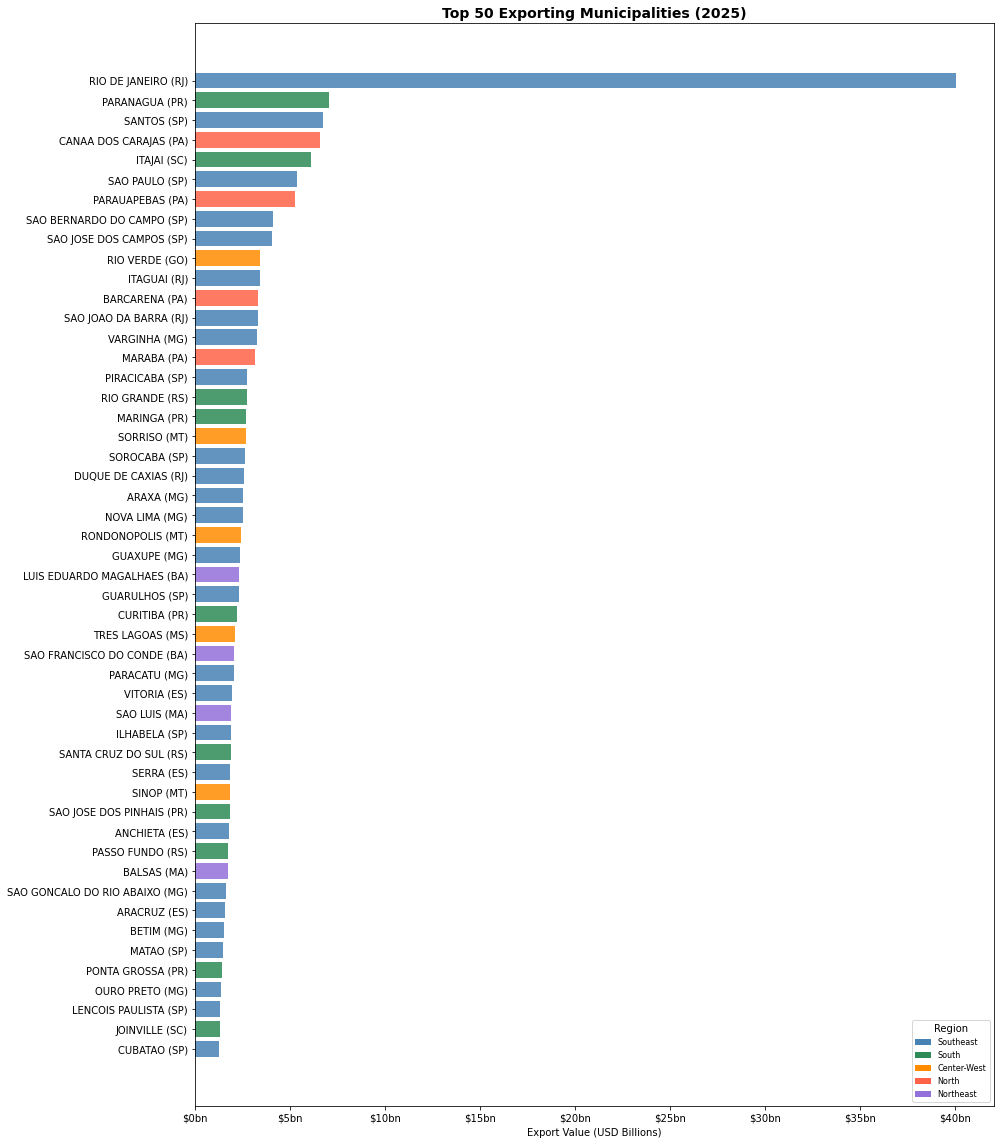

In [5]:
## ── Chart: Top 50 municipalities by export value ────────────────────────────
REGION_COLORS = {
    'Southeast'  : 'steelblue',
    'South'      : 'seagreen',
    'Center-West': 'darkorange',
    'North'      : 'tomato',
    'Northeast'  : 'mediumpurple',
    'Undeclared' : 'lightgray',
}

df_top50 = df_mun_exp.head(50).sort_values('exports_usd_bn', ascending=True)
bar_colors = df_top50['region'].map(REGION_COLORS).fillna('lightgray')

fig, ax = plt.subplots(figsize=(14, 16))
bars = ax.barh(
    df_top50['municipality'] + ' (' + df_top50['uf'] + ')',
    df_top50['exports_usd_bn'],
    color=bar_colors, alpha=0.85
)
ax.set_title(f"Top 50 Exporting Municipalities ({MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Export Value (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

## Region legend
legend_elements = [Patch(facecolor=c, label=r) for r, c in REGION_COLORS.items()
                   if r != 'Undeclared']
ax.legend(handles=legend_elements, title='Region', fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('output_3_1_2_top50_municipalities.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview

The top 50 exporting municipalities confirm the regional dominance pattern established at state level in Section 2.1, with steelblue (Southeast) accounting for the majority of bars. Rio de Janeiro stands apart from the rest of the ranking — its bar at \\$40.03bn is nearly 6x the length of second-placed Paranaguá (\\$7.03bn), a gap larger than the entire distance between rank 2 and rank 50.

**Southeast dominance is structural but distributed.** São Paulo state places 16 municipalities in the top 50 — more than any other state — yet no individual São Paulo municipality exceeds \\$6.71bn (Santos). Export activity within São Paulo is dispersed across many industrial centres rather than concentrated in a single city, producing a long tail of mid-size exporters in the \\$1.3–5.4bn range.

**Center-West municipalities cluster in the mid-range.** Orange bars (Center-West) — Sorriso, Rondonópolis, Sinop, Três Lagoas — appear consistently in the \\$1.8–2.7bn band. This reflects the dispersed agribusiness geography of the commodity interior, where production is distributed across many mid-size municipalities rather than concentrated in a single urban hub.

**North region is front-loaded.** The three red bars (North) — Canaã dos Carajás, Parauapebas, Barcarena, and Marabá — are clustered in the top 15. Below rank 15, North virtually disappears from the chart, confirming that the region's export capacity is geographically narrow and extraction-dependent.

**South is notably absent from the top ranks.** Despite being Brazil's third largest export region at \\$57.38bn, no South municipality appears in the top 5. Paranaguá (\\$7.03bn) is the South's highest-ranked municipality at position 2, with Itajaí (\\$6.12bn) at position 5. Below these two port cities, South municipalities are sparse and small — consistent with the region's distributed industrial and agribusiness base.

---
---

### 3.1.3 — Top 50 Exporting Municipalities — Summary Table
Ranked table showing each municipality's absolute export value, share of national exports, and cumulative share — quantifying how quickly export activity concentrates as you move down the ranking.

In [6]:
## Municipality exports by state — all municipalities, all values
df_mun_state = df_mun_exp.copy().sort_values(['uf', 'exports_usd'], ascending=[True, False]).reset_index(drop=True)
df_mun_state = df_mun_state[~df_mun_state['state'].isin(exclude_non_geo)]

## ── Summary table: municipality, state, volume, % of state, % of national ────
national_total = df_mun_exp['exports_usd'].sum()
state_totals   = df_mun_state.groupby('state')['exports_usd'].sum()

df_top50_table = df_mun_exp.head(50).copy()
df_top50_table['state_total']    = df_top50_table['state'].map(state_totals)
df_top50_table['pct_of_state']   = (df_top50_table['exports_usd'] / df_top50_table['state_total'] * 100).round(1)
df_top50_table['pct_of_national'] = (df_top50_table['exports_usd'] / national_total * 100).round(1)

df_top50_table = df_top50_table[
    ['municipality', 'uf', 'state', 'exports_usd_bn', 'pct_of_state', 'pct_of_national']
].rename(columns={
    'municipality'    : 'Municipality',
    'uf'             : 'UF',
    'state'           : 'State',
    'exports_usd_bn'  : 'Exports (USD bn)',
    'pct_of_state'    : '% of State Exports',
    'pct_of_national' : '% of National Exports',
})

df_top50_table['Exports (USD bn)']     = df_top50_table['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_top50_table['% of State Exports']   = df_top50_table['% of State Exports'].apply(lambda x: f'{x:.1f}%')
df_top50_table['% of National Exports'] = df_top50_table['% of National Exports'].apply(lambda x: f'{x:.1f}%')

display(
    df_top50_table.style
    .set_caption(f'Top 50 Exporting Municipalities — State and National Share ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

Municipality,UF,State,Exports (USD bn),% of State Exports,% of National Exports
RIO DE JANEIRO,RJ,Rio de Janeiro,$40.03bn,74.3%,11.5%
PARANAGUA,PR,Paraná,$7.03bn,26.0%,2.0%
SANTOS,SP,São Paulo,$6.71bn,8.8%,1.9%
CANAA DOS CARAJAS,PA,Pará,$6.55bn,27.1%,1.9%
ITAJAI,SC,Santa Catarina,$6.12bn,41.0%,1.8%
SAO PAULO,SP,São Paulo,$5.37bn,7.1%,1.5%
PARAUAPEBAS,PA,Pará,$5.28bn,21.8%,1.5%
SAO BERNARDO DO CAMPO,SP,São Paulo,$4.11bn,5.4%,1.2%
SAO JOSE DOS CAMPOS,SP,São Paulo,$4.06bn,5.3%,1.2%
RIO VERDE,GO,Goiás,$3.42bn,29.2%,1.0%


#### Overview

The top 50 municipalities account for the majority of national export value, with concentration falling sharply after the first tier. Rio de Janeiro (11.5%) is the only municipality with a double-digit national share — the gap between rank 1 and rank 2 (Paranaguá at 2.0%) is larger than the gap between rank 2 and rank 50 (Joinville and Cubatão at 0.4%).

Cumulative share reaches approximately 50% within the top 10 and the remaining 40 municipalities in the ranking contribute the second 50% in progressively smaller increments — confirming that national registered export concentration at municipality level follows the same steep drop-off pattern observed at state level in Section 2.1.

**Itajaí at 41.0% of Santa Catarina state exports** is the highest state-share figure outside Rio de Janeiro (74.3%) and the most analytically significant given the state's import deficit — examined directly in Section 3.10. Whether this reflects the registration of large exporting companies in Itajaí or a broader economic function requires confirmation at the entity level.

---
---

### 3.1.4 — State Export Distribution: Municipality Concentration Within States
For each state represented in the top 50, the number of municipalities appearing in the ranking and their combined share of state exports — identifying whether state-level export value is driven by a single dominant municipality or distributed across multiple centres. States with few municipalities in the top 50 but high combined shares are single-cluster exporters; states with many municipalities but low individual shares are distributed exporters.

In [7]:
## ── State export distribution: municipality concentration within top 50 ───────
national_total   = df_mun_exp['exports_usd'].sum()
state_totals_map = df_mun_exp.groupby('state')['exports_usd'].sum()

## Build state-level summary from top 50
df_state_dist = (
    df_mun_exp.head(50)
    .groupby(['state', 'region'])
    .agg(
        mun_count       = ('municipality', 'count'),
        top50_exp_usd   = ('exports_usd', 'sum'),
    )
    .reset_index()
)

df_state_dist['state_total_usd']   = df_state_dist['state'].map(state_totals_map)
df_state_dist['pct_of_state']      = (df_state_dist['top50_exp_usd'] / df_state_dist['state_total_usd'] * 100).round(1)
df_state_dist['pct_of_national']   = (df_state_dist['top50_exp_usd'] / national_total * 100).round(1)
df_state_dist['avg_per_mun_bn']    = (df_state_dist['top50_exp_usd'] / df_state_dist['mun_count'] / 1e9).round(2)

## Sort by total export value of municipalities in top 50
df_state_dist = df_state_dist.sort_values('top50_exp_usd', ascending=False).reset_index(drop=True)

## Format for display
df_state_dist_display = df_state_dist.copy().rename(columns={
    'state'           : 'State',
    'region'          : 'Region',
    'mun_count'       : 'Municipalities in Top 50',
    'top50_exp_usd'   : 'Combined Export Value',
    'pct_of_state'    : '% of State Exports',
    'pct_of_national' : '% of National Exports',
    'avg_per_mun_bn'  : 'Avg per Municipality (USD bn)',
})
df_state_dist_display['Combined Export Value']           = df_state_dist_display['Combined Export Value'].apply(lambda x: f'\\${x/1e9:.2f}bn')
df_state_dist_display['% of State Exports']              = df_state_dist_display['% of State Exports'].apply(lambda x: f'{x:.1f}%')
df_state_dist_display['% of National Exports']           = df_state_dist_display['% of National Exports'].apply(lambda x: f'{x:.1f}%')
df_state_dist_display['Avg per Municipality (USD bn)']   = df_state_dist_display['Avg per Municipality (USD bn)'].apply(lambda x: f'\\${x:.2f}bn')

##print(f"State Export Distribution — Municipalities in Top 50 ({MAX_YEAR})")
display(
    df_state_dist_display.style
    .set_caption(f'State Export Distribution: Municipality Concentration Within Top 50 ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

State,Region,Municipalities in Top 50,Combined Export Value,state_total_usd,% of State Exports,% of National Exports,Avg per Municipality (USD bn)
Rio de Janeiro,Southeast,4,\$49.34bn,53837572765.000000,91.6%,14.2%,\$12.33bn
São Paulo,Southeast,11,\$33.91bn,75980526793.000000,44.6%,9.7%,\$3.08bn
Pará,North,4,\$18.33bn,24189747966.000000,75.8%,5.3%,\$4.58bn
Minas Gerais,Southeast,8,\$17.26bn,41300605049.000000,41.8%,5.0%,\$2.16bn
Paraná,South,5,\$15.21bn,27007718436.000000,56.3%,4.4%,\$3.04bn
Santa Catarina,South,2,\$7.42bn,14951608600.000000,49.6%,2.1%,\$3.71bn
Espírito Santo,Southeast,4,\$7.14bn,10903526505.000000,65.5%,2.0%,\$1.78bn
Mato Grosso,Center-West,3,\$6.95bn,27464573461.000000,25.3%,2.0%,\$2.32bn
Rio Grande do Sul,South,3,\$6.32bn,20169492298.000000,31.3%,1.8%,\$2.11bn
Bahia,Northeast,2,\$4.37bn,11463334640.000000,38.1%,1.3%,\$2.19bn


#### Overview

The top 50 municipalities represent 13 states and account for \\$175.41bn — approximately 50.4% of national exports. The table reveals two distinct patterns: states where a small number of municipalities in the top 50 capture the majority of state exports, and states where top-50 representation is broad but individual municipality shares are low.

**Rio de Janeiro is the most concentrated state in the dataset on two dimensions.** Four municipalities account for 91.6% of state exports at an average of \\$12.33bn per municipality — the highest average of any state in the ranking by a factor of 4x over Pará (\\$4.58bn). However, the four-municipality figure overstates diversification: Rio de Janeiro city alone accounts for 74.3% of state exports, meaning the remaining three municipalities — Itaguaí, São João da Barra, and Duque de Caxias — contribute only 17.3% combined. All four are port or port-adjacent municipalities concentrated along the state's coastal corridor. The 91.6% state capture is port infrastructure concentration, not distributed industrial capacity, and the underlying single-municipality dominance at 74.3% is the more analytically significant figure.

**Pará and Maranhão show the highest extraction-driven concentration.** Pará's four top-50 municipalities account for 75.8% of state exports (\\$18.33bn) at \\$4.58bn average — the second highest average in the table. Maranhão's two municipalities (São Luís and Balsas) account for 66.3% of state exports at \\$1.82bn average, confirming that Maranhão's export base is structurally dependent on a port city and a single agribusiness frontier municipality.

**Espírito Santo at 65.5% with four municipalities signals a concentrated coastal industrial cluster.** All four — Vitória, Serra, Anchieta, and Aracruz — are within the state's coastal industrial corridor. Unlike Pará and Maranhão, the concentration here reflects deliberate industrial co-location rather than resource geography.

**São Paulo is the only large state with distributed concentration.** Eleven municipalities in the top 50 account for only 44.6% of state exports at \\$3.08bn average — the largest municipality count of any state in the table and one of the lowest state-capture percentages. The remaining 55.4% of São Paulo's \\$75.98bn export total is distributed across 444 additional municipalities, confirming the breadth of the state's industrial base.

**Mato Grosso presents the sharpest contrast between state scale and top-50 representation.** Three municipalities account for only 25.3% of the state's \\$27.46bn in exports — the lowest state capture percentage in the table. This reflects the dispersed agribusiness geography of the commodity interior, where soybean production and processing is distributed across the entire state rather than concentrated in a small number of urban centres.

**Nine states have no municipalities in the top 50.** Amazonas, Piauí, Alagoas, Sergipe, Roraima, Paraíba, Amapá, Distrito Federal, and Acre — together accounting for \\$2.39bn (0.7% of national exports) — are entirely absent from the top 50. Their combined export value is less than 6% of Rio de Janeiro city alone.

---
---

## 3.2 — Municipality Import Rankings: Which Municipalities Drive National Imports?
Ranking all municipalities by total import value in MAX_YEAR — identifying whether import concentration mirrors export concentration or reveals a different geographic pattern, particularly the role of port cities and industrial hubs.

### 3.2.1 — Top 50 Importing Municipalities — Query and Data Load
Aggregates total FOB import value by municipality for MAX_YEAR, joining `imp_mun` to `uf_mun` and `uf` using the same join structure as the export query in 3.1.1. Results are ordered by import value descending — this ranked dataframe is reused across all import sections.

In [8]:
## Query top municipalities by import value
query_mun_imp = f"""
    SELECT i."CO_MUN"            AS mun_code,
           m.nome_municipio       AS municipality,
           i."SG_UF_MUN"         AS uf,
           u.nome_estado          AS state,
           u.nome_regiao          AS region,
           SUM(i."VL_FOB")       AS imports_usd
    FROM imp_mun i
    JOIN uf_mun m ON i."CO_MUN"     = m.codigo_municipio
    JOIN uf u     ON i."SG_UF_MUN"  = u.sigla
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY i."CO_MUN", m.nome_municipio, i."SG_UF_MUN", u.nome_estado, u.nome_regiao
    ORDER BY imports_usd DESC
"""

df_mun_imp = pd.read_sql(query_mun_imp, engine)
df_mun_imp['imports_usd_bn'] = (df_mun_imp['imports_usd'] / 1e9).round(3)
df_mun_imp['region'] = df_mun_imp['region'].map(region_name_map).fillna(df_mun_imp['region'])
df_mun_imp = df_mun_imp[~df_mun_imp['state'].isin(exclude_non_geo)]

print(f"Total municipalities with imports in {MAX_YEAR}: {len(df_mun_imp):,}")
print(f"\nTop 10 importing municipalities:")
print(df_mun_imp.head(10)[['municipality', 'state', 'imports_usd_bn']].to_string(index=False))

Total municipalities with imports in 2025: 2,486

Top 10 importing municipalities:
  municipality          state  imports_usd_bn
        ITAJAI Santa Catarina          16.314
        MANAUS       Amazonas          15.826
     SAO PAULO      São Paulo          10.772
RIO DE JANEIRO Rio de Janeiro           9.974
    PETROPOLIS Rio de Janeiro           9.469
     CARIACICA Espírito Santo           7.173
      PAULINIA      São Paulo           6.226
      SAO LUIS       Maranhão           4.461
     JOINVILLE Santa Catarina           4.458
       JUNDIAI      São Paulo           4.301


#### Overview

2,486 municipalities recorded imports in 2025 — a broader base than the export side, consistent with importing companies being registered across a wider set of locations than exporting companies.

The top 10 import ranking is structurally distinct from the export ranking. Only São Paulo and Rio de Janeiro appear in both top 10 rankings.

**Itajaí leads at \\$16.31bn** — the primary evidence for the Santa Catarina gateway hypothesis flagged in Section 2.1.2 and examined directly in Section 3.10. A single municipality registering the largest import volume in Brazil is the most significant finding in this ranking.

**Manaus at \\$15.83bn confirms the Zona Franca dynamic.** As established in Section 2.8, Amazonas runs a \\$15.13bn import deficit driven by the Zona Franca de Manaus — a federal free trade zone where electronics, motorcycles, and consumer goods are assembled from imported components under tax incentive. Manaus accounting for 98.5% of Amazonas state imports is structurally expected.

**Petrópolis (\\$9.47bn) is anomalous.** The fifth largest importing municipality nationally carries no established profile as an industrial or logistics hub and does not appear in the export ranking. NCM-level investigation is required before this figure is interpreted as reflecting genuine local import activity rather than a registration or classification anomaly.

**São Paulo city imports \\$10.77bn — 12.5% of the state's \\$86.50bn total.** Unlike the export side where São Paulo city accounts for only 7.1% of state registered exports, its import share is materially higher — reflecting the concentration of registered importing companies in the city relative to the rest of the state.

---
---

### 3.2.2 — Top 50 Importing Municipalities — Bar Chart
Horizontal bar chart of the top 50 municipalities by import value, colour-coded by region — identifying whether import activity is geographically concentrated in the same regions as exports or reveals a different distribution, particularly the weight of port-connected municipalities in the South and Southeast.

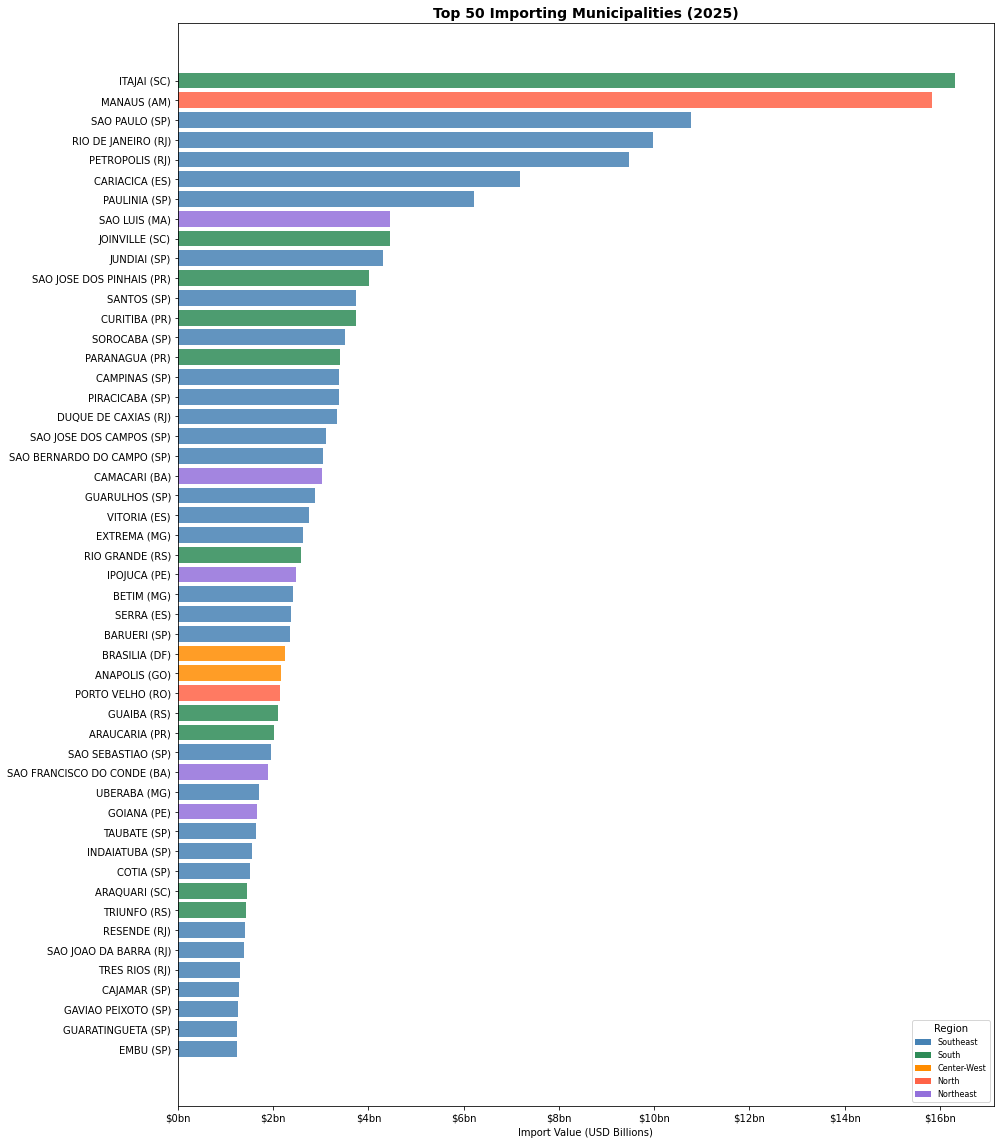

In [9]:
## ── Chart: Top 50 municipalities by import value ─────────────────────────────
df_top50_imp = df_mun_imp.head(50).sort_values('imports_usd_bn', ascending=True)
bar_colors   = df_top50_imp['region'].map(REGION_COLORS).fillna('lightgray')

fig, ax = plt.subplots(figsize=(14, 16))
ax.barh(
    df_top50_imp['municipality'] + ' (' + df_top50_imp['uf'] + ')',
    df_top50_imp['imports_usd_bn'],
    color=bar_colors, alpha=0.85
)
ax.set_title(f'Top 50 Importing Municipalities ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Import Value (USD Billions)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

legend_elements = [Patch(facecolor=c, label=r) for r, c in REGION_COLORS.items()
                   if r != 'Undeclared']
ax.legend(handles=legend_elements, title='Region', fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('output_3_2_3_top50_imp_municipalities.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview

The import chart reveals a different regional pattern from the export ranking. Southeast dominates by municipality count with 28 of the top 50 — but South takes the top position through Itajaí alone, and North places second through Manaus despite having only one municipality in the top 50.

**The top 2 municipalities are structurally isolated from the rest of the ranking.** Itajaí (\\$16.31bn) and Manaus (\\$15.83bn) sit materially above the third-ranked São Paulo (\\$10.77bn) and represent two distinct import registration dynamics — the Santa Catarina anomaly and the Zona Franca respectively. Below rank 3 the ranking compresses rapidly, with most municipalities clustered in the \\$2–4bn range.

**Southeast dominance is broad but shallow.** São Paulo state's 17 municipalities span from \\$10.77bn (São Paulo city) down to approximately \\$1.3bn (Guaratinguetá, Embu), with no other São Paulo municipality exceeding \\$6.5bn. The state registers more importing municipalities in the top 50 than any other state by a significant margin.

**Center-West makes a limited appearance.** Only Brasília (DF) and Anápolis (GO) appear — both in the \\$2bn range — consistent with the coverage ratio findings in Section 2.14.

---
---

### 3.2.3 — Top 50 Importing Municipalities — Summary Table
Ranked table showing each municipality's absolute import value, share of national imports, and cumulative share — mirroring the export summary in 3.1.3. Comparing the two tables reveals whether import concentration is higher or lower than export concentration at the municipality level.

In [10]:
## ── Summary table: municipality, state, volume, % of state, % of national ────
national_imp_total = df_mun_imp['imports_usd'].sum()
state_imp_totals   = df_mun_imp.groupby('state')['imports_usd'].sum()

df_top50_imp_table = df_mun_imp.head(50).copy()
df_top50_imp_table['state_total']     = df_top50_imp_table['state'].map(state_imp_totals)
df_top50_imp_table['pct_of_state']    = (df_top50_imp_table['imports_usd'] / df_top50_imp_table['state_total'] * 100).round(1)
df_top50_imp_table['pct_of_national'] = (df_top50_imp_table['imports_usd'] / national_imp_total * 100).round(1)

df_top50_imp_table = df_top50_imp_table[
    ['municipality', 'uf', 'state', 'imports_usd_bn', 'pct_of_state', 'pct_of_national']
].rename(columns={
    'municipality'    : 'Municipality',
    'uf'             : 'UF',    
    'state'           : 'State',
    'imports_usd_bn'  : 'Imports (USD bn)',
    'pct_of_state'    : '% of State Imports',
    'pct_of_national' : '% of National Imports',
})
df_top50_imp_table['Imports (USD bn)']      = df_top50_imp_table['Imports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_top50_imp_table['% of State Imports']    = df_top50_imp_table['% of State Imports'].apply(lambda x: f'{x:.1f}%')
df_top50_imp_table['% of National Imports'] = df_top50_imp_table['% of National Imports'].apply(lambda x: f'{x:.1f}%')

##print(f"\nTop 50 Importing Municipalities ({MAX_YEAR}) — National Total: ${national_imp_total/1e9:.1f}bn")
display(
    df_top50_imp_table.style
    .set_caption(f'Top 50 Importing Municipalities — State and National Share ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

Municipality,UF,State,Imports (USD bn),% of State Imports,% of National Imports
ITAJAI,SC,Santa Catarina,$16.31bn,48.0%,5.8%
MANAUS,AM,Amazonas,$15.83bn,98.5%,5.6%
SAO PAULO,SP,São Paulo,$10.77bn,12.5%,3.8%
RIO DE JANEIRO,RJ,Rio de Janeiro,$9.97bn,31.0%,3.6%
PETROPOLIS,RJ,Rio de Janeiro,$9.47bn,29.4%,3.4%
CARIACICA,ES,Espírito Santo,$7.17bn,51.9%,2.6%
PAULINIA,SP,São Paulo,$6.23bn,7.2%,2.2%
SAO LUIS,MA,Maranhão,$4.46bn,93.8%,1.6%
JOINVILLE,SC,Santa Catarina,$4.46bn,13.1%,1.6%
JUNDIAI,SP,São Paulo,$4.30bn,5.0%,1.5%


#### Overview

The top 50 importing municipalities account for \\$183.0bn — 65.3% of national imports. Concentration is higher than the export side where the top 50 accounted for approximately 50.4% of national exports, reflecting the pull of a small number of registration clusters on the import side.

**Manaus is the most state-concentrated municipality in the ranking.** At 98.5% of Amazonas state imports, it is effectively the only importing municipality in the state — a direct consequence of the Zona Franca structure where all bonded imports flow through a single registered location. São Luís (93.8% of Maranhão) and Porto Velho (95.2% of Rondônia) show similar single-municipality dominance at materially lower absolute values.

**Industrial processing municipalities register disproportionately high import values relative to their export profiles.** Paulínia (SP, \\$6.23bn), Camaçari (BA, \\$3.03bn), Ipojuca (PE, \\$2.48bn), and Anápolis (GO, \\$2.16bn) all rank materially higher on the import side than the export side — consistent with companies registered in these municipalities importing raw material and intermediate inputs. NCM-level confirmation in Step 4 is required to identify the specific input categories driving each municipality's import profile.

**Cariacica (ES) at 51.9% of Espírito Santo imports is the most significant within-state concentration finding outside the single-municipality states.** Combined with Vitória (20.0%) and Serra (17.2%), three municipalities account for 89.1% of Espírito Santo's total registered imports.

**Anápolis (GO) at 40.3% of Goiás imports registers the highest import share of any Center-West municipality.** This is consistent with the \\$1.94bn pharmaceutical import anomaly flagged in Section 2.8 and deferred to Step 4 for NCM-level confirmation.

**Pernambuco places two municipalities in the top 50.** Ipojuca (34.3%, \\$2.48bn) and Goiana (23.0%, \\$1.66bn) together account for 57.3% of Pernambuco's state registered imports.

**São Paulo's 17 municipalities collectively account for \\$57.65bn — 66.7% of state imports** — yet no individual municipality exceeds 12.5% of state imports, with 13 of the 17 each accounting for less than 5% of state imports individually.

---
---

### 3.2.4 — 3.2.4 — State Import Distribution: Municipality Concentration Within States
For each state represented in the top 50 importing municipalities, the number of municipalities appearing in the ranking and their combined share of state imports — identifying whether state-level import value is driven by a single dominant municipality or distributed across multiple centres. States with few municipalities in the top 50 but high combined shares are single-node importers; states with many municipalities but low individual shares are distributed importers.

In [11]:
## ── State import distribution: municipality concentration within top 50 ───────
national_imp_total   = df_mun_imp['imports_usd'].sum()
state_imp_totals_map = df_mun_imp.groupby('state')['imports_usd'].sum()

## Build state-level summary from top 50
df_state_imp_dist = (
    df_mun_imp.head(50)
    .groupby(['state', 'region'])
    .agg(
        mun_count       = ('municipality', 'count'),
        top50_imp_usd   = ('imports_usd', 'sum'),
    )
    .reset_index()
)

df_state_imp_dist['state_total_usd'] = df_state_imp_dist['state'].map(state_imp_totals_map)
df_state_imp_dist['pct_of_state']    = (df_state_imp_dist['top50_imp_usd'] / df_state_imp_dist['state_total_usd'] * 100).round(1)
df_state_imp_dist['pct_of_national'] = (df_state_imp_dist['top50_imp_usd'] / national_imp_total * 100).round(1)
df_state_imp_dist['avg_per_mun_bn']  = (df_state_imp_dist['top50_imp_usd'] / df_state_imp_dist['mun_count'] / 1e9).round(2)

## Sort by total import value of municipalities in top 50
df_state_imp_dist = df_state_imp_dist.sort_values('top50_imp_usd', ascending=False).reset_index(drop=True)

## Format for display
df_state_imp_dist_display = df_state_imp_dist.copy().rename(columns={
    'state'           : 'State',
    'region'          : 'Region',
    'mun_count'       : 'Municipalities in Top 50',
    'top50_imp_usd'   : 'Combined Import Value',
    'pct_of_state'    : '% of State Imports',
    'pct_of_national' : '% of National Imports',
    'avg_per_mun_bn'  : 'Avg per Municipality (USD bn)',
})
df_state_imp_dist_display['Combined Import Value']           = df_state_imp_dist_display['Combined Import Value'].apply(lambda x: f'${x/1e9:.2f}bn')
df_state_imp_dist_display['% of State Imports']              = df_state_imp_dist_display['% of State Imports'].apply(lambda x: f'{x:.1f}%')
df_state_imp_dist_display['% of National Imports']           = df_state_imp_dist_display['% of National Imports'].apply(lambda x: f'{x:.1f}%')
df_state_imp_dist_display['Avg per Municipality (USD bn)']   = df_state_imp_dist_display['Avg per Municipality (USD bn)'].apply(lambda x: f'${x:.2f}bn')

display(
    df_state_imp_dist_display.style
    .set_caption(f'State Import Distribution: Municipality Concentration Within Top 50 ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

State,Region,Municipalities in Top 50,Combined Import Value,state_total_usd,% of State Imports,% of National Imports,Avg per Municipality (USD bn)
São Paulo,Southeast,19,$58.37bn,86500010650.000000,67.5%,20.8%,$3.07bn
Rio de Janeiro,Southeast,6,$26.89bn,32173326653.000000,83.6%,9.6%,$4.48bn
Santa Catarina,South,3,$22.22bn,33992553126.000000,65.4%,7.9%,$7.41bn
Amazonas,North,1,$15.83bn,16064501785.000000,98.5%,5.6%,$15.83bn
Paraná,South,4,$13.19bn,20153663141.000000,65.5%,4.7%,$3.30bn
Espírito Santo,Southeast,3,$12.31bn,13810300156.000000,89.1%,4.4%,$4.10bn
Minas Gerais,Southeast,3,$6.73bn,18332979018.000000,36.7%,2.4%,$2.24bn
Rio Grande do Sul,South,3,$6.12bn,13380651276.000000,45.7%,2.2%,$2.04bn
Bahia,Northeast,2,$4.92bn,9311068239.000000,52.9%,1.8%,$2.46bn
Maranhão,Northeast,1,$4.46bn,4757990490.000000,93.8%,1.6%,$4.46bn


#### Overview

The top 50 importing municipalities represent 14 states and account for \\$183.04bn — 65.3% of national imports. Concentration is materially higher than the export side, where the top 50 accounted for 50.4% of national exports.

**Single-municipality import markets dominate the North and Northeast.** Amazonas (98.5%), Rondônia (95.2%), Maranhão (93.8%) and Distrito Federal (100.0%) each place one municipality in the top 50 and that municipality accounts for the near-totality of state registered imports.

**Santa Catarina produces the highest average per municipality in the table at \\$7.41bn** — driven by Itajaí's \\$16.31bn rather than distributed evenly across its three municipalities. The average overstates structural breadth and the state's position as a demand market versus a registration hub remains unresolved pending the Step 4 NCM-level investigation flagged in Section 3.11.

**Espírito Santo (89.1%, 3 municipalities) and Rio de Janeiro (83.6%, 6 municipalities) achieve the highest state-capture percentages among multi-municipality states.** Both concentrate registered import activity in a small number of co-located coastal and port-adjacent municipalities, consistent with the industrial corridor structure identified in Sections 3.2.3 and 3.5.2.

**Minas Gerais records the lowest state-capture percentage in the table at 36.7%** — three municipalities account for barely a third of the state's $18.33bn import base, confirming the distributed import structure established in Section 3.8.

**São Paulo places the most municipalities in the top 50 of any state at 19, yet captures only 67.5% of state imports through them.** The remaining 32.5% of $86.50bn is distributed across a further 418 municipalities. São Paulo and Minas Gerais are the only two states in the table where the top-50 municipalities do not cover the majority of state import demand.

---
---

## 3.3 — Export and Import Co-Location: Do States Trade Through the Same Municipalities?
For each state, this section identifies how many of the top export municipalities also appear among the top import municipalities — distinguishing between states where trade activity is concentrated in the same industrial hubs and states where exports and imports flow through structurally different locations.

### 3.3.1 — Overlap Count by State
For each state, the number of municipalities appearing in both the top 5 export and top 5 import rankings — a symmetric measure of whether the same economic centres drive both sides of the state's trade ledger. A score of 5 indicates complete co-location of export and import activity; a score of 0 indicates full structural separation between export production sites and import consumption or processing centres.

In [12]:
## ── Top 5 export municipalities per state — styled tables ────────────────────
states_ordered_exp = (
    df_mun_state.groupby('state')['exports_usd']
    .sum().sort_values(ascending=False).index.tolist()
)
states_ordered_exp = [s for s in states_ordered_exp if s not in exclude_non_geo]

## ── Export/Import municipality overlap by state ───────────────────────────────
overlap_rows = []

for state in states_ordered_exp:
    exp_subset = (
        df_mun_state[df_mun_state['state'] == state]
        .sort_values('exports_usd', ascending=False)
        .head(5)
    )
    imp_subset = (
        df_mun_imp[df_mun_imp['state'] == state]
        .sort_values('imports_usd', ascending=False)
        .head(5)  ## changed from 10 to 5
    )
    if exp_subset.empty or imp_subset.empty:
        continue

    exp_muns     = set(exp_subset['mun_code'].tolist())
    imp_muns     = set(imp_subset['mun_code'].tolist())
    overlap_muns = exp_muns & imp_muns
    overlap_names = (
        exp_subset[exp_subset['mun_code'].isin(overlap_muns)]['municipality']
        .tolist()
    )

    region      = exp_subset['region'].iloc[0]
    exp_total   = df_mun_state[df_mun_state['state'] == state]['exports_usd'].sum()
    imp_total   = df_mun_imp[df_mun_imp['state'] == state]['imports_usd'].sum()

    overlap_rows.append({
        'state'          : state,
        'region'         : region,
        'exp_total_bn'   : round(exp_total / 1e9, 2),
        'imp_total_bn'   : round(imp_total / 1e9, 2),
        'overlap_count'  : len(overlap_muns),
        'overlap_municipalities': ', '.join(overlap_names) if overlap_names else '—',
    })

df_overlap = pd.DataFrame(overlap_rows).sort_values('overlap_count', ascending=False)

print(f"Export/Import Municipality Overlap by State ({MAX_YEAR})")
print(f"(Top 5 export municipalities vs Top 5 import municipalities)\n")
print(df_overlap[['state', 'region', 'overlap_count', 'overlap_municipalities']].to_string(index=False))

Export/Import Municipality Overlap by State (2025)
(Top 5 export municipalities vs Top 5 import municipalities)

              state      region  overlap_count                                  overlap_municipalities
               Acre       North              4 BRASILEIA, SENADOR GUIOMARD, RIO BRANCO, EPITACIOLANDIA
         Pernambuco   Northeast              4        GOIANA, IPOJUCA, CABO DE SANTO AGOSTINHO, RECIFE
             Paraná       South              4 PARANAGUA, CURITIBA, SAO JOSE DOS PINHAIS, PONTA GROSSA
 Mato Grosso do Sul Center-West              4  TRES LAGOAS, RIBAS DO RIO PARDO, CAMPO GRANDE, CORUMBA
     Espírito Santo   Southeast              3                              VITORIA, SERRA, VILA VELHA
          Tocantins       North              3            PORTO NACIONAL, PALMAS, PARAISO DO TOCANTINS
     Rio de Janeiro   Southeast              3      RIO DE JANEIRO, SAO JOAO DA BARRA, DUQUE DE CAXIAS
           Maranhão   Northeast              3                 

#### Overview

No state achieves the maximum overlap of 5 — the highest scores are 4, recorded by Acre, Pernambuco, Paraná, and Mato Grosso do Sul. Two states record zero overlap: Minas Gerais and Alagoas. The results suggest that complete co-location of registered export and import activity is rare and that structural separation between the two sides of the trade ledger is the norm across Brazilian states.

**The four states at overlap 4 represent different co-location types.** Paraná and Mato Grosso do Sul achieve high overlap through municipalities that register significant activity on both sides of the trade ledger. Pernambuco's overlap of 4 (Goiana, Ipojuca, Cabo de Santo Agostinho, Recife) reflects the same municipalities registering both export and import companies. Acre's overlap of 4 is driven by border municipalities where cross-border trade flows register on both sides simultaneously — making high overlap structurally expected rather than analytically significant.

**São Paulo's overlap of 2 is the most significant finding in the table.** Brazil's largest exporting state (\\$75.98bn) and largest importing state (\\$86.50bn) shares only Santos and São Paulo city across its top 5 registered export and import municipalities — confirming that the state's export and import company bases are largely registered in different municipalities.

**Minas Gerais at zero overlap is the sharpest registered separation in the dataset.** Brazil's third largest exporting state shares no municipalities between its top 5 export and top 5 import rankings — its registered export activity and registered import activity are concentrated in entirely different locations within the state.

**Alagoas at zero overlap reflects a small-state structural limitation** rather than a meaningful finding — with only 20 active export municipalities and a narrow export base, its top 5 export municipalities simply do not generate sufficient registered import volumes to appear in the import ranking.

---
---

### 3.3.2 — Overlap Summary Table
Styled summary showing each state's overlap count alongside total export and import value — allowing the co-location pattern to be read against the scale of each state's trade activity.

In [13]:
## ── Styled overlap summary table ─────────────────────────────────────────────
df_overlap_display = df_overlap.copy().rename(columns={
    'state'                   : 'State',
    'region'                  : 'Region',
    'exp_total_bn'            : 'Exports (USD bn)',
    'imp_total_bn'            : 'Imports (USD bn)',
    'overlap_count'           : 'Overlap (of 5)',
    'overlap_municipalities'  : 'Shared Municipalities',
})
df_overlap_display['Exports (USD bn)'] = df_overlap_display['Exports (USD bn)'].apply(lambda x: f'${x:.2f}bn')
df_overlap_display['Imports (USD bn)'] = df_overlap_display['Imports (USD bn)'].apply(lambda x: f'${x:.2f}bn')

display(
    df_overlap_display.style
    .set_caption(f'Export/Import Municipality Overlap by State ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

State,Region,Exports (USD bn),Imports (USD bn),Overlap (of 5),Shared Municipalities
Acre,North,$0.07bn,$0.01bn,4,"BRASILEIA, SENADOR GUIOMARD, RIO BRANCO, EPITACIOLANDIA"
Pernambuco,Northeast,$2.37bn,$7.24bn,4,"GOIANA, IPOJUCA, CABO DE SANTO AGOSTINHO, RECIFE"
Paraná,South,$27.01bn,$20.15bn,4,"PARANAGUA, CURITIBA, SAO JOSE DOS PINHAIS, PONTA GROSSA"
Mato Grosso do Sul,Center-West,$8.56bn,$2.71bn,4,"TRES LAGOAS, RIBAS DO RIO PARDO, CAMPO GRANDE, CORUMBA"
Espírito Santo,Southeast,$10.90bn,$13.81bn,3,"VITORIA, SERRA, VILA VELHA"
Tocantins,North,$2.96bn,$0.35bn,3,"PORTO NACIONAL, PALMAS, PARAISO DO TOCANTINS"
Rio de Janeiro,Southeast,$53.84bn,$32.17bn,3,"RIO DE JANEIRO, SAO JOAO DA BARRA, DUQUE DE CAXIAS"
Maranhão,Northeast,$5.49bn,$4.76bn,3,"SAO LUIS, BALSAS, IMPERATRIZ"
Ceará,Northeast,$2.30bn,$2.63bn,3,"SAO GONCALO DO AMARANTE, FORTALEZA, MARACANAU"
Rio Grande do Norte,Northeast,$1.11bn,$0.44bn,3,"GUAMARE, MOSSORO, NATAL"


#### Overview

The styled table adds export and import scale to the overlap count — allowing the co-location finding to be read against the size of each state's trade activity. The most analytically significant observation is that overlap score and trade scale are inversely correlated among large states: Brazil's three largest exporters — São Paulo (\\$75.98bn), Minas Gerais (\\$41.30bn), and Rio de Janeiro (\\$53.84bn) — record overlap scores of 2, 0, and 3 respectively, while several small states achieve scores of 4.

**High overlap in small states is structurally less meaningful.** Acre (overlap 4, \\$0.07bn exports, \\$0.01bn imports) and Roraima (overlap 3, \\$0.26bn exports, \\$0.05bn imports) achieve high scores because their entire registered trade activity is concentrated in a handful of border municipalities that register on both sides simultaneously.

**The most meaningful high-overlap readings are Paraná and Mato Grosso do Sul.** Both are material trading states — Paraná at \\$27.01bn exports and \\$20.15bn imports, Mato Grosso do Sul at \\$8.56bn and \\$2.71bn — where overlap 4 indicates that the same municipalities register both significant export and import activity rather than having structurally separate company bases.

**Santa Catarina's overlap of 3 alongside a \\$19.04bn trade deficit is the most structurally anomalous combination in the table.** The three shared municipalities — Itajaí, Joinville, and São Francisco do Sul — register significant activity on both sides of the trade ledger. The deficit is examined directly in Section 3.10.

**Amazonas presents the inverse anomaly.** An overlap of 2 alongside \\$16.06bn in imports against only \\$0.94bn in exports produces the largest import-to-export ratio in the table at approximately 17:1. The Zona Franca import concentration in Manaus generates import volumes with no corresponding export registration base.

**Goiás at overlap 1 (Rio Verde only) despite \\$11.70bn in exports and \\$5.36bn in imports confirms that its registered export and import company bases are geographically separate.** Rio Verde anchors the export side while Anápolis — confirmed as the state's primary import registration centre in Section 3.2.3 — does not appear in the export top 5, producing a clean separation between the state's two registered trade functions.

---
---

## 3.4 — Within-State Concentration: How Concentrated Is Each State's Export Activity?
Within every state, how many municipalities generate the majority of export value? A state where the top 3 municipalities account for 95% of exports is structurally different from one where exports are distributed across 50+ municipalities — even if the total export value is similar. This section measures within-state geographic concentration using HHI and top-N share metrics at municipality level.

### 3.4.1 — Within-State Export Concentration — Data Preparation
Derives `df_mun_state` directly from the already-loaded `df_mun_exp` dataframe to avoid a redundant database query. For each state, computes municipality-level HHI (sum of squared export shares), top 1/3/5 municipality share of state total, active municipality count, and the name of the dominant municipality. Results are stored in `df_conc` sorted by HHI descending.

The Herfindahl-Hirschman Index (HHI) used here is the sum of squared municipality export shares within each state. An HHI of 1.0 indicates that a single municipality accounts for 100% of state exports — complete concentration. An HHI approaching 0 indicates that exports are distributed evenly across a large number of municipalities — complete dispersion. In practice, values above 0.25 indicate high concentration, values between 0.10 and 0.25 indicate moderate concentration, and values below 0.10 indicate a distributed export base.

In [14]:
## Compute within-state concentration metrics per state
concentration_rows = []
for uf, group in df_mun_state.groupby('uf'):
    group = group.sort_values('exports_usd', ascending=False).reset_index(drop=True)
    state_total = group['exports_usd'].sum()
    if state_total == 0:
        continue
    group['share'] = group['exports_usd'] / state_total
    hhi   = (group['share'] ** 2).sum()
    top1  = group['share'].iloc[0] * 100
    top3  = group['share'].iloc[:3].sum() * 100
    top5  = group['share'].iloc[:5].sum() * 100
    n_mun = len(group)
    top_mun    = group['municipality'].iloc[0]
    state_name = group['state'].iloc[0]
    region     = group['region'].iloc[0]
    concentration_rows.append({
        'uf'              : uf,
        'state'           : state_name,
        'region'          : region,
        'n_mun'           : n_mun,
        'top1_share'      : round(top1, 1),
        'top3_share'      : round(top3, 1),
        'top5_share'      : round(top5, 1),
        'hhi_mun'         : round(hhi, 4),
        'top_municipality': top_mun,
        'state_total_bn'  : round(state_total / 1e9, 2),
    })

df_conc = pd.DataFrame(concentration_rows).sort_values('hhi_mun', ascending=False).reset_index(drop=True)

## ── Concentration tier classification ────────────────────────────────────────
def hhi_tier(hhi):
    if hhi >= 0.25:
        return 'High'
    elif hhi >= 0.10:
        return 'Moderate'
    else:
        return 'Distributed'

df_conc['concentration'] = df_conc['hhi_mun'].apply(hhi_tier)

## ── Build display dataframe ───────────────────────────────────────────────────
df_conc_display = df_conc[[
    'state', 'region', 'concentration', 'n_mun',
    'top1_share', 'top3_share', 'top5_share',
    'hhi_mun', 'top_municipality', 'state_total_bn'
]].copy().rename(columns={
    'state'           : 'State',
    'region'          : 'Region',
    'concentration'   : 'Concentration',
    'n_mun'           : 'Active Municipalities',
    'top1_share'      : 'Top 1 (%)',
    'top3_share'      : 'Top 3 (%)',
    'top5_share'      : 'Top 5 (%)',
    'hhi_mun'         : 'HHI',
    'top_municipality': 'Dominant Municipality',
    'state_total_bn'  : 'State Total (USD bn)',
})

## Format columns
for col in ['Top 1 (%)', 'Top 3 (%)', 'Top 5 (%)']:
    df_conc_display[col] = df_conc_display[col].apply(lambda x: f'{x:.1f}%')
df_conc_display['HHI']                  = df_conc_display['HHI'].apply(lambda x: f'{x:.4f}')
df_conc_display['State Total (USD bn)'] = df_conc_display['State Total (USD bn)'].apply(lambda x: f'\\${x:.2f}bn')

## ── Styling ───────────────────────────────────────────────────────────────────
tier_colors = {
    'High'       : '#d9534f',
    'Moderate'   : '#f0ad4e',
    'Distributed': '#5cb85c',
}

def row_bg(row):
    color_map = {
        'High'       : 'rgba(217, 83, 79, 0.08)',
        'Moderate'   : 'rgba(240, 173, 78, 0.08)',
        'Distributed': 'rgba(92, 184, 92, 0.08)',
    }
    bg = color_map.get(row['Concentration'], 'white')
    return [f'background-color: {bg}'] * len(row)

def color_concentration(val):
    color = tier_colors.get(val, 'black')
    return f'color: {color}; font-weight: bold'

table_styles = [
    {'selector': 'th', 'props': [
        ('background-color', '#2c3e50'),
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('border-bottom', '2px solid #1a252f'),
        ('padding', '8px 12px'),
    ]},
    {'selector': 'td', 'props': [
        ('padding', '6px 12px'),
        ('border-bottom', '1px solid #e0e0e0'),
    ]},
    {'selector': 'table', 'props': [
        ('border-collapse', 'collapse'),
        ('width', '100%'),
        ('font-size', '13px'),
    ]},
]

print(f"\nWithin-State Municipality Export Concentration — {MAX_YEAR}")
print(f"High (HHI ≥ 0.25) | Moderate (0.10 ≤ HHI < 0.25) | Distributed (HHI < 0.10)\n")

display(
    df_conc_display.style
    .apply(row_bg, axis=1)
    .applymap(color_concentration, subset=['Concentration'])
    .set_caption(f'Within-State Municipality Export Concentration ({MAX_YEAR})')
    .set_table_styles(table_styles)
    .hide_index()
)


Within-State Municipality Export Concentration — 2025
High (HHI ≥ 0.25) | Moderate (0.10 ≤ HHI < 0.25) | Distributed (HHI < 0.10)



State,Region,Concentration,Active Municipalities,Top 1 (%),Top 3 (%),Top 5 (%),HHI,Dominant Municipality,State Total (USD bn)
Distrito Federal,Center-West,High,1,100.0%,100.0%,100.0%,1.0000,BRASILIA,\$0.08bn
Roraima,North,High,10,96.5%,99.2%,99.6%,0.9325,BOA VISTA,\$0.26bn
Amapá,North,High,6,94.6%,98.5%,99.9%,0.8962,SANTANA,\$0.12bn
Amazonas,North,High,19,85.0%,98.8%,99.5%,0.7358,MANAUS,\$0.94bn
Rio de Janeiro,Southeast,High,66,74.3%,86.9%,93.3%,0.5637,RIO DE JANEIRO,\$53.84bn
Sergipe,Northeast,High,15,57.9%,96.6%,98.5%,0.4368,JAPARATUBA,\$0.48bn
Rio Grande do Norte,Northeast,High,47,52.7%,79.2%,86.3%,0.3202,GUAMARE,\$1.11bn
Ceará,Northeast,High,64,52.8%,69.5%,77.7%,0.3019,SAO GONCALO DO AMARANTE,\$2.30bn
Acre,North,High,9,40.9%,83.5%,97.6%,0.2787,BRASILEIA,\$0.07bn
Piauí,Northeast,High,27,35.7%,77.4%,88.0%,0.2590,URUCUI,\$0.85bn


#### Overview

Within-state municipality export concentration ranges from complete single-municipality dominance (Distrito Federal, HHI 1.0000) to highly distributed activity across hundreds of municipalities (São Paulo, HHI 0.0272).

**The High tier is defined by structural constraint rather than industrial specialisation.** Distrito Federal, Roraima, Amapá, and Amazonas are single-hub or frontier states where concentration reflects geographic and administrative constraint rather than deliberate economic organisation. Rio de Janeiro (HHI 0.5637) is the only High-tier state with material export scale — its concentration driven entirely by petroleum customs registration in a single municipality as established in Section 3.1.1.

**The Moderate tier spans a wide range of state profiles.** At the upper end, Rio Grande do Norte (HHI 0.3202) and Ceará (0.3019) show concentration driven by a small number of mineral or industrial export sites. At the lower end, Espírito Santo (0.1191) and Mato Grosso do Sul (0.1122) approach the Distributed threshold — Espírito Santo across its coastal industrial corridor and Mato Grosso do Sul across its agribusiness and industrial municipalities.

**Sergipe (HHI 0.4368) is the most concentrated state outside the structural constraint group.** With only 15 active municipalities and Japaratuba accounting for 57.9% of state exports, the top-5 share reaches 98.5% — virtually the entire state export base captured in five municipalities. NCM-level investigation is required to confirm whether Japaratuba's dominance reflects a single extractive operation.

**The four largest export states all sit in the Distributed tier.** São Paulo (HHI 0.0272, 455 municipalities), Minas Gerais (0.0304, 361 municipalities), Mato Grosso (0.0393, 86 municipalities), and Rio Grande do Sul (0.0531, 278 municipalities) record the four lowest HHI values in the dataset. Mato Grosso's inclusion is notable — despite being a primary commodity state, soybean production is dispersed across the cerrado frontier rather than concentrated at a single extraction site, producing a distributed profile structurally distinct from the mineral extraction states in the High tier.

---
---

### 3.4.2 — Within-State Export Concentration — Chart
Dual-panel horizontal bar chart showing municipality-level HHI (left panel) and top 3 municipality share of state exports (right panel) for all states, sorted by HHI ascending. The 50% reference line on the right panel marks the threshold above which fewer than 3 municipalities account for the majority of state export value. States are coloured by region for cross-regional pattern identification.

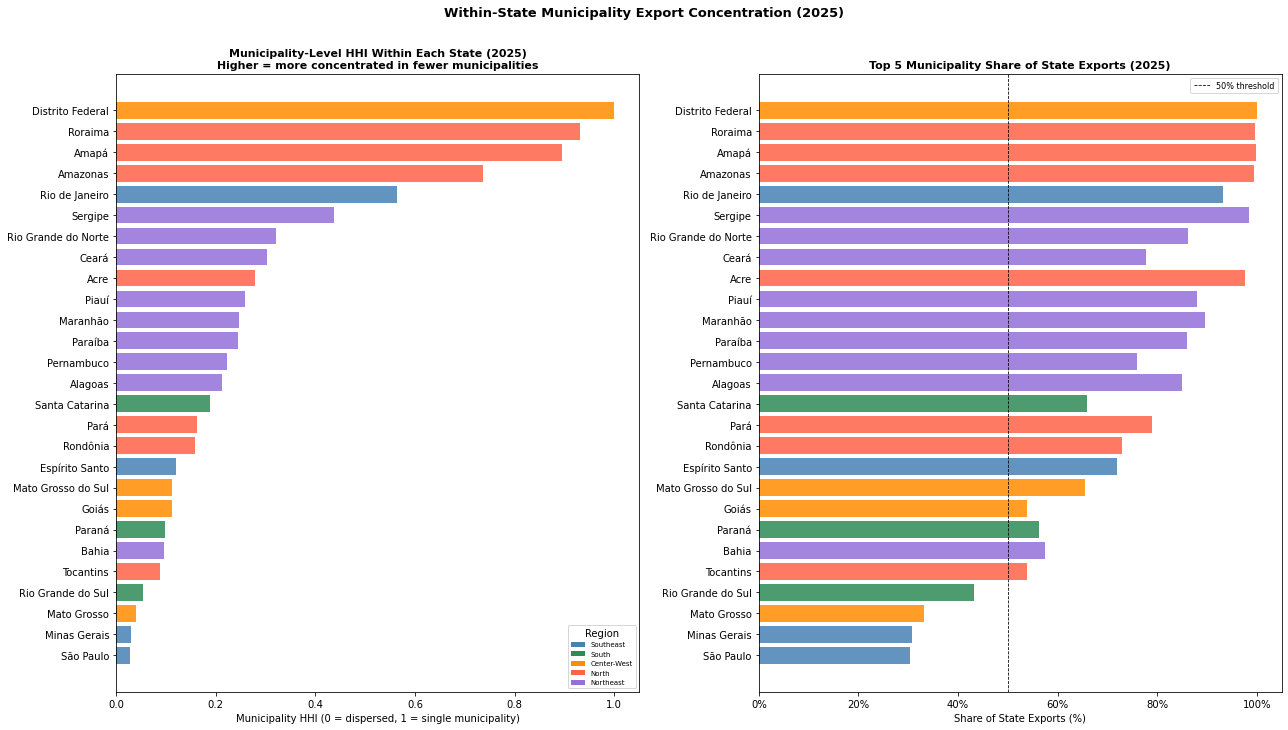

In [15]:
## ── Chart: within-state HHI ranked ─────────────────────────────────────────
df_conc_plot = df_conc.sort_values('hhi_mun', ascending=True)
bar_colors = df_conc_plot['region'].map(REGION_COLORS).fillna('lightgray')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

## Left: HHI
ax1.barh(df_conc_plot['state'], df_conc_plot['hhi_mun'], color=bar_colors, alpha=0.85)
ax1.set_title(f'Municipality-Level HHI Within Each State ({MAX_YEAR})\n'
              f'Higher = more concentrated in fewer municipalities',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Municipality HHI (0 = dispersed, 1 = single municipality)')

## Right: Top 5 share
ax2.barh(df_conc_plot['state'], df_conc_plot['top5_share'], color=bar_colors, alpha=0.85)
ax2.axvline(x=50, color='black', linewidth=0.8, linestyle='--', label='50% threshold')
ax2.set_title(f'Top 5 Municipality Share of State Exports ({MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Share of State Exports (%)')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend(fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in REGION_COLORS.items()
                   if r != 'Undeclared']
ax1.legend(handles=legend_elements, title='Region', fontsize=7, loc='lower right')

plt.suptitle(f'Within-State Municipality Export Concentration ({MAX_YEAR})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_3_4_2_within_state_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview

The dual-panel chart makes the structural separation between state types visually immediate and confirms the three-tier pattern established in 3.4.1. The left panel (HHI) and right panel (top-5 share) are broadly consistent — states that rank high on HHI also show high top-5 share — with one exception where the panels diverge meaningfully.

**The top 4 states are visually isolated from the rest of the HHI ranking.** Distrito Federal, Roraima, Amapá, and Amazonas form a distinct cluster above 0.70 HHI with a clear gap before Rio de Janeiro at 0.56. All remaining states fall below 0.50, confirming that extreme registered export concentration is limited to structurally constrained states rather than being a broad feature of Brazilian export geography.

**Sergipe, Acre, and Rio de Janeiro all show divergence between the two panels.** Each records a moderate-to-high HHI while their top-5 share reaches 98.5%, 97.6%, and 93.3% respectively. The divergence indicates that registered exports are not dominated by a single municipality alone but are captured almost entirely within the top 5, with negligible registered activity in the remaining municipalities. Beyond the top cluster, these states have no meaningful secondary registered export base.

**The 50% reference line separates 23 states above from 4 states below — and the implications differ fundamentally between the two groups.** For the 23 states above the line, the top 5 municipalities account for the majority of registered export activity and represent the primary focus for any state-level commercial engagement. For the 4 states below the line — São Paulo, Minas Gerais, Mato Grosso, and Rio Grande do Sul — registered export activity is distributed across many municipalities with no shortcut to coverage, reflecting the breadth of their respective export company bases.

**The concentration tier maps directly onto the commodity-industrial divide established in Step 2.** Without exception, every state classified as a primary commodity exporter in Section 2.4.1 falls in the High or Moderate tier. Every Distributed tier state is either industrialised (São Paulo, Minas Gerais, Paraná, Rio Grande do Sul) or a large commodity state where registered export activity is spread across the frontier (Mato Grosso, Goiás, Bahia).

**High and Moderate tier states face concentrated registered export exposure.** Where a single municipality accounts for the majority of registered export value, any disruption affecting the companies registered in that municipality concentrates impact at state level with limited offset from other municipalities. The four Distributed tier states with the lowest HHI values face no equivalent single point of registered concentration — and these are also four of Brazil's five largest exporters, suggesting that geographic distribution of registered export activity and export scale are positively correlated at state level.

---
---

### 3.4.3 — Geographic vs Product Concentration: Are They Correlated Across States?
Cross-tabulates each state's within-municipality export HHI from Section 3.4.1 against its product-level HHI from Step 2b (Section 2b.3) — testing whether states that are geographically concentrated in export registration are also concentrated in product mix. A positive correlation would indicate that concentration is a structural feature operating at all levels simultaneously; a weak or negative correlation would indicate that geographic and product concentration are independent dimensions requiring separate treatment in market entry analysis.

Pearson correlation — Geographic HHI vs Product HHI: r=0.187, p=0.352
              state      region  geo_hhi  product_hhi
   Distrito Federal Center-West 1.000000     0.161096
            Roraima       North 0.932462     0.191560
              Amapá       North 0.896166     0.274541
           Amazonas       North 0.735814     0.103227
     Rio de Janeiro   Southeast 0.563740     0.631138
            Sergipe   Northeast 0.436802     0.457154
Rio Grande do Norte   Northeast 0.320162     0.257501
              Ceará   Northeast 0.301933     0.146376
               Acre       North 0.278676     0.125952
              Piauí   Northeast 0.259001     0.687690
           Maranhão   Northeast 0.247571     0.264734
            Paraíba   Northeast 0.244576     0.198293
         Pernambuco   Northeast 0.222871     0.081340
            Alagoas   Northeast 0.211907     0.461724
     Santa Catarina       South 0.188116     0.032244
               Pará       North 0.161316     0.266406
           R

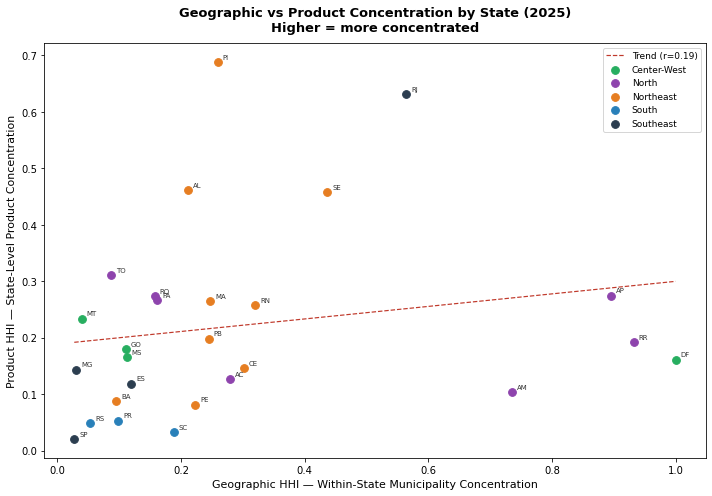

State,Region,Geographic HHI,Product HHI
Distrito Federal,Center-West,1.0000,0.1611
Roraima,North,0.9325,0.1916
Amapá,North,0.8962,0.2745
Amazonas,North,0.7358,0.1032
Rio de Janeiro,Southeast,0.5637,0.6311
Sergipe,Northeast,0.4368,0.4572
Rio Grande do Norte,Northeast,0.3202,0.2575
Ceará,Northeast,0.3019,0.1464
Acre,North,0.2787,0.1260
Piauí,Northeast,0.2590,0.6877


In [16]:
## ── Query NCM-level exports by state ─────────────────────────────────────────
query_product_hhi = f"""
    SELECT u.sigla                          AS uf,
           u.nome_estado                     AS state,
           u.nome_regiao                     AS region,
           e."CO_NCM"                        AS ncm,
           SUM(e."VL_FOB")                  AS ncm_exports
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA','CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA','REEXPORTACAO'
    )
    GROUP BY u.sigla, u.nome_estado, u.nome_regiao, e."CO_NCM"
"""

df_prod_hhi_raw = pd.read_sql(query_product_hhi, engine)
df_prod_hhi_raw['region'] = (
    df_prod_hhi_raw['region'].map(region_name_map)
    .fillna(df_prod_hhi_raw['region'])
)

## Compute product HHI per state from NCM-level shares
df_prod_hhi = (
    df_prod_hhi_raw.groupby(['uf', 'state', 'region'])
    .apply(lambda g: (
        (g['ncm_exports'] / g['ncm_exports'].sum()) ** 2
    ).sum())
    .reset_index(name='product_hhi')
)

## ── Query geographic HHI from municipality-level exports ─────────────────────
query_geo_hhi = f"""
    SELECT u.sigla                          AS uf,
           u.nome_estado                     AS state,
           SUM(POWER(
               mun_totals.mun_exports /
               NULLIF(state_totals.state_exports, 0), 2))
               AS geo_hhi
    FROM (
        SELECT e."SG_UF_MUN"   AS uf,
               e."CO_MUN"      AS mun_code,
               SUM(e."VL_FOB") AS mun_exports
        FROM exp_mun e
        WHERE e."CO_ANO" = {MAX_YEAR}
        GROUP BY e."SG_UF_MUN", e."CO_MUN"
    ) mun_totals
    JOIN (
        SELECT e."SG_UF_MUN"   AS uf,
               SUM(e."VL_FOB") AS state_exports
        FROM exp_mun e
        WHERE e."CO_ANO" = {MAX_YEAR}
        GROUP BY e."SG_UF_MUN"
    ) state_totals ON mun_totals.uf = state_totals.uf
    JOIN uf u ON mun_totals.uf = u.sigla
    WHERE u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA','CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA','REEXPORTACAO'
    )
    GROUP BY u.sigla, u.nome_estado
"""

df_geo_hhi = pd.read_sql(query_geo_hhi, engine)

## ── Merge ────────────────────────────────────────────────────────────────────
df_hhi_compare = df_geo_hhi.merge(
    df_prod_hhi[['uf', 'region', 'product_hhi']], on='uf'
)

## ── Correlation ──────────────────────────────────────────────────────────────
from scipy.stats import pearsonr
r, p = pearsonr(df_hhi_compare['geo_hhi'], df_hhi_compare['product_hhi'])
print(f"Pearson correlation — Geographic HHI vs Product HHI: r={r:.3f}, p={p:.3f}")
print(df_hhi_compare[['state', 'region', 'geo_hhi', 'product_hhi']]
      .sort_values('geo_hhi', ascending=False).to_string(index=False))

## ── Chart ────────────────────────────────────────────────────────────────────
region_colors = {
    'Southeast'  : '#2c3e50',
    'South'      : '#2980b9',
    'Center-West': '#27ae60',
    'Northeast'  : '#e67e22',
    'North'      : '#8e44ad',
}

fig, ax = plt.subplots(figsize=(10, 7))

for region, grp in df_hhi_compare.groupby('region'):
    ax.scatter(
        grp['geo_hhi'], grp['product_hhi'],
        color=region_colors.get(region, 'grey'),
        label=region, s=60, zorder=3
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row['uf'],
            (row['geo_hhi'], row['product_hhi']),
            textcoords='offset points', xytext=(5, 3),
            fontsize=7, color='#333333'
        )

## Trend line
m, b = np.polyfit(df_hhi_compare['geo_hhi'], df_hhi_compare['product_hhi'], 1)
x_line = np.linspace(
    df_hhi_compare['geo_hhi'].min(),
    df_hhi_compare['geo_hhi'].max(), 100
)
ax.plot(x_line, m * x_line + b, color='#c0392b', linewidth=1.2,
        linestyle='--', label=f'Trend (r={r:.2f})')

ax.set_xlabel('Geographic HHI — Within-State Municipality Concentration', fontsize=11)
ax.set_ylabel('Product HHI — State-Level Product Concentration', fontsize=11)
ax.set_title(
    'Geographic vs Product Concentration by State (2025)\n'
    'Higher = more concentrated',
    fontsize=13, fontweight='bold', pad=12
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## ── Styled table ─────────────────────────────────────────────────────────────
display(
    df_hhi_compare[['state', 'region', 'geo_hhi', 'product_hhi']]
    .sort_values('geo_hhi', ascending=False)
    .rename(columns={
        'state'       : 'State',
        'region'      : 'Region',
        'geo_hhi'     : 'Geographic HHI',
        'product_hhi' : 'Product HHI',
    })
    .style
    .format({
        'Geographic HHI' : '{:.4f}',
        'Product HHI'    : '{:.4f}',
    })
    .set_caption('Geographic vs Product Concentration by State (2025)')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

#### Overview
The correlation between geographic HHI and product HHI across 27 states is weak and statistically non-significant (r=0.187, p=0.352). The scatter plot confirms no consistent linear relationship — states with high geographic concentration do not systematically show high product concentration, and vice versa. The two dimensions of concentration are largely independent.

#### Business Relevance
The weak correlation has a direct analytical implication: geographic concentration and product concentration must be treated as separate risk dimensions, not proxies for each other. A state that is easy to enter from a coverage standpoint — concentrated in one or two municipalities — is not necessarily exposed to commodity risk, and a state with a diversified municipal base is not necessarily diversified in product terms.

Four states sit in positions that illustrate this independence most clearly. Rio de Janeiro has moderate geographic concentration (0.564) and the highest product HHI in the dataset (0.631) — geographically distributed across multiple municipalities but almost entirely dependent on a single product category. Piauí shows the same pattern at smaller scale: moderate geographic concentration (0.259) with very high product HHI (0.688). Both states combine manageable geographic coverage with extreme product risk. At the opposite extreme, Mato Grosso is geographically distributed (0.039) but moderately product-concentrated (0.234) — a wide municipal base exporting a relatively narrow commodity mix.

Santa Catarina is the most unusual data point in the chart. Its geographic HHI (0.188) places it in the mid-range, yet its product HHI (0.032) is the lowest in the dataset — lower even than São Paulo (0.021). This indicates that behind Itajaí's dominant registration share, the actual product mix registered across Santa Catarina's municipalities is the most diversified of any state. This finding adds a further dimension to the Step 4 investigation: Itajaí's geographic dominance does not translate into product concentration at the state level.

São Paulo (geo 0.027, product 0.021) and Rio Grande do Sul (geo 0.053, product 0.049) anchor the bottom-left of the scatter — the only two states with genuinely low concentration on both dimensions simultaneously. These are the two states identified in Section 3.8 as requiring multi-city import coverage strategies, and they are also the two states with the most structurally robust export bases by this combined measure.

*⚠️ Piauí (product HHI 0.688) and Rio de Janeiro (product HHI 0.631) are the two states with the highest product concentration in the dataset. Both carry significant single-sector export dependency that is not visible from geographic HHI alone. Step 4 NCM-level analysis should prioritise identifying the dominant NCM codes driving these figures.*

---
---

## 3.5 — State-Wide Municipality Analysis: Top Export and Import Locations by State
For each state, the top exporting and importing municipalities by value — identifying the specific cities driving each state's trade activity and whether export and import activity is concentrated in the same locations or different ones.

### 3.5.1 — Top Export Municipalities by State — Console Profile
For each state ordered by total export value, prints the top 5 exporting municipalities with absolute value and share of state total — providing a quick-scan reference for the dominant export cluster in each state.

In [17]:
for state in states_ordered_exp:
    subset = (
        df_mun_state[df_mun_state['state'] == state]
        .sort_values('exports_usd', ascending=False)
        .head(5)
        .copy()
    )
    if subset.empty:
        continue

    state_total   = df_mun_state[df_mun_state['state'] == state]['exports_usd'].sum()
    region        = subset['region'].iloc[0]
    top5_total    = subset['exports_usd'].sum()
    top5_share    = top5_total / state_total * 100

    subset['Share of State (%)'] = (subset['exports_usd'] / state_total * 100).round(1)
    subset['Cumulative (%)']     = subset['Share of State (%)'].cumsum().round(1)
    subset['Exports (USD bn)']   = subset['exports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
    subset['Share of State (%)'] = subset['Share of State (%)'].apply(lambda x: f'{x:.1f}%')
    subset['Cumulative (%)']     = subset['Cumulative (%)'].apply(lambda x: f'{x:.1f}%')

    display_df = subset[['municipality', 'Exports (USD bn)', 'Share of State (%)', 'Cumulative (%)']].rename(
        columns={'municipality': 'Municipality'}
    )

    ##print(f"\n{state} ({region}) — Total: ${state_total/1e9:.2f}bn | Top 5 share: {top5_share:.1f}%")
    display(
        display_df.style
        .set_caption(f'{state} — Top 5 Export Municipalities ({MAX_YEAR})')
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                          ('color', 'white'), ('font-weight', 'bold')]},
            {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
        ])
        .hide_index()
    )

Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
SANTOS,$6.71bn,8.8%,8.8%
SAO PAULO,$5.36bn,7.1%,15.9%
SAO BERNARDO DO CAMPO,$4.11bn,5.4%,21.3%
SAO JOSE DOS CAMPOS,$4.06bn,5.3%,26.6%
PIRACICABA,$2.76bn,3.6%,30.2%


Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
RIO DE JANEIRO,$40.03bn,74.3%,74.3%
ITAGUAI,$3.42bn,6.3%,80.6%
SAO JOAO DA BARRA,$3.32bn,6.2%,86.8%
DUQUE DE CAXIAS,$2.57bn,4.8%,91.6%
ANGRA DOS REIS,$0.88bn,1.6%,93.2%


Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
VARGINHA,$3.29bn,8.0%,8.0%
ARAXA,$2.54bn,6.1%,14.1%
NOVA LIMA,$2.52bn,6.1%,20.2%
GUAXUPE,$2.35bn,5.7%,25.9%
PARACATU,$2.03bn,4.9%,30.8%


Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
SORRISO,$2.67bn,9.7%,9.7%
RONDONOPOLIS,$2.44bn,8.9%,18.6%
SINOP,$1.84bn,6.7%,25.3%
SAPEZAL,$1.10bn,4.0%,29.3%
MATUPA,$1.05bn,3.8%,33.1%


Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
PARANAGUA,$7.03bn,26.0%,26.0%
MARINGA,$2.68bn,9.9%,35.9%
CURITIBA,$2.22bn,8.2%,44.1%
SAO JOSE DOS PINHAIS,$1.84bn,6.8%,50.9%
PONTA GROSSA,$1.44bn,5.3%,56.2%


...

Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
BOA VISTA,$0.25bn,96.5%,96.5%
PACARAIMA,$0.01bn,2.3%,98.8%
BONFIM,$0.00bn,0.4%,99.2%
CANTA,$0.00bn,0.3%,99.5%
IRACEMA,$0.00bn,0.1%,99.6%


Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
CAMPINA GRANDE,$0.06bn,40.0%,40.0%
SANTA RITA,$0.04bn,25.6%,65.6%
MAMANGUAPE,$0.01bn,9.5%,75.1%
VIEIROPOLIS,$0.01bn,5.7%,80.8%
LUCENA,$0.01bn,5.2%,86.0%


Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
SANTANA,$0.11bn,94.6%,94.6%
MACAPA,$0.00bn,2.2%,96.8%
MAZAGAO,$0.00bn,1.8%,98.6%
SERRA DO NAVIO,$0.00bn,0.8%,99.4%
OIAPOQUE,$0.00bn,0.5%,99.9%


Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
BRASILIA,$0.08bn,100.0%,100.0%


Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
BRASILEIA,$0.03bn,40.9%,40.9%
SENADOR GUIOMARD,$0.02bn,26.7%,67.6%
RIO BRANCO,$0.01bn,15.9%,83.5%
EPITACIOLANDIA,$0.01bn,11.9%,95.4%
MANOEL URBANO,$0.00bn,2.2%,97.6%


#### Overview

The state-level export profiles confirm the concentration patterns from Section 3.4 and reveal four structural registration archetypes across the 27 states.

**Single dominant location states** — Rio de Janeiro (74.3%), Amazonas (85.0%), and the structurally constrained frontier states — register the majority of export value in one municipality with negligible secondary activity. These states have no meaningful fallback registration base beyond their primary location.

**Two-node states** — Maranhão (São Luís 35.0%, Balsas 31.4%), Piauí (Uruçuí 35.7%, Bom Jesus 34.3%), and Sergipe (Japaratuba 57.9%, Estância 30.8%) — concentrate registered exports across two structurally distinct locations. Sergipe is the most extreme case with 88.7% captured in two municipalities across only 15 active registrations.

**Balanced cluster states** — Espírito Santo and Minas Gerais — show the narrowest top-5 value ranges in the dataset at 3.3pp and 3.1pp respectively. Both distribute registered export activity evenly across five municipalities with no single dominant location — the most structurally resilient profiles outside the Distributed HHI tier.

**Distributed states** — São Paulo (top-5 share 30.2%, 455 active municipalities), Minas Gerais (30.8%, 361), and Mato Grosso (33.1%, 86) — show no dominant registration location and the lowest top-5 shares in the dataset. These three account for \\$144.74bn in combined exports — 41.5% of national total — confirming that the majority of Brazil's export value is generated by states where registered activity is genuinely distributed rather than concentrated.

**The Northeastern states present the highest single-municipality shares outside the structurally constrained group.** São Gonçalo do Amarante (52.8% of Ceará) and Guamaré (52.7% of Rio Grande do Norte) exceed the 50% threshold at the top-1 level — a concentration reading comparable to structurally constrained states but occurring in states with 64 and 47 active municipalities respectively. Sector-level confirmation from Section 3.7 is required before interpreting the drivers of this concentration.

---
---

### 3.5.2 — Top Import Municipalities by State — Console Profile
For each state ordered by total import value, prints the top 5 importing municipalities with absolute value and share of state total — mirroring the export console profile in 3.5.1 and allowing the two to be compared side by side before the full styled tables in Section 3.5.3.2.

In [18]:
## Top 5 municipalities per state by import value
df_top5_imp_per_state = (
    df_mun_imp
    .groupby('uf', group_keys=False)
    .apply(lambda x: x.nlargest(5, 'imports_usd'))
    .reset_index(drop=True)
)

## Add state total for share calculation
state_imp_totals_map = df_mun_imp.groupby('uf')['imports_usd'].sum()
df_top5_imp_per_state['state_total'] = df_top5_imp_per_state['uf'].map(state_imp_totals_map)
df_top5_imp_per_state['mun_share_%'] = (
    df_top5_imp_per_state['imports_usd'] / df_top5_imp_per_state['state_total'] * 100
).round(1)

## Print state profiles — ordered by largest import state first
states_ordered_imp = (
    df_mun_imp.groupby('state')['imports_usd']
    .sum().sort_values(ascending=False).index.tolist()
)
states_ordered_imp = [s for s in states_ordered_imp if s not in exclude_non_geo]

## ── Top 10 import municipalities per state — styled tables ───────────────────
states_ordered_imp = (
    df_mun_imp.groupby('state')['imports_usd']
    .sum().sort_values(ascending=False).index.tolist()
)
states_ordered_imp = [s for s in states_ordered_imp if s not in exclude_non_geo]

for state in states_ordered_imp:
    subset = (
        df_mun_imp[df_mun_imp['state'] == state]
        .sort_values('imports_usd', ascending=False)
        .head(5)
        .copy()
    )
    if subset.empty:
        continue

    state_total   = df_mun_imp[df_mun_imp['state'] == state]['imports_usd'].sum()
    region        = subset['region'].iloc[0]
    top10_total   = subset['imports_usd'].sum()
    top10_share   = top10_total / state_total * 100

    subset['Share of State (%)'] = (subset['imports_usd'] / state_total * 100).round(1)
    subset['Cumulative (%)']     = subset['Share of State (%)'].cumsum().round(1)
    subset['Imports (USD bn)']   = subset['imports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
    subset['Share of State (%)'] = subset['Share of State (%)'].apply(lambda x: f'{x:.1f}%')
    subset['Cumulative (%)']     = subset['Cumulative (%)'].apply(lambda x: f'{x:.1f}%')

    display_df = subset[['municipality', 'Imports (USD bn)', 'Share of State (%)', 'Cumulative (%)']].rename(
        columns={'municipality': 'Municipality'}
    )

    ##print(f"\n{state} ({region}) — Total: ${state_total/1e9:.2f}bn | Top 10 share: {top10_share:.1f}%")
    display(
        display_df.style
        .set_caption(f'{state} — Top 5 Import Municipalities ({MAX_YEAR})')
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                          ('color', 'white'), ('font-weight', 'bold')]},
            {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
        ])
        .hide_index()
    )

Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
SAO PAULO,$10.77bn,12.5%,12.5%
PAULINIA,$6.23bn,7.2%,19.7%
JUNDIAI,$4.30bn,5.0%,24.7%
SANTOS,$3.74bn,4.3%,29.0%
SOROCABA,$3.51bn,4.1%,33.1%


Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
ITAJAI,$16.31bn,48.0%,48.0%
JOINVILLE,$4.46bn,13.1%,61.1%
ARAQUARI,$1.44bn,4.2%,65.3%
SAO FRANCISCO DO SUL,$1.16bn,3.4%,68.7%
SAO JOSE,$0.98bn,2.9%,71.6%


Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
RIO DE JANEIRO,$9.97bn,31.0%,31.0%
PETROPOLIS,$9.47bn,29.4%,60.4%
DUQUE DE CAXIAS,$3.35bn,10.4%,70.8%
RESENDE,$1.40bn,4.4%,75.2%
SAO JOAO DA BARRA,$1.38bn,4.3%,79.5%


Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
SAO JOSE DOS PINHAIS,$4.02bn,20.0%,20.0%
CURITIBA,$3.73bn,18.5%,38.5%
PARANAGUA,$3.41bn,16.9%,55.4%
ARAUCARIA,$2.03bn,10.1%,65.5%
PONTA GROSSA,$0.83bn,4.1%,69.6%


Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
EXTREMA,$2.62bn,14.3%,14.3%
BETIM,$2.41bn,13.1%,27.4%
UBERABA,$1.70bn,9.3%,36.7%
BELO HORIZONTE,$1.04bn,5.7%,42.4%
POUSO ALEGRE,$0.98bn,5.3%,47.7%


...

Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
PALMAS,$0.08bn,24.0%,24.0%
PALMEIRANTE,$0.06bn,18.5%,42.5%
PARAISO DO TOCANTINS,$0.06bn,18.3%,60.8%
MIRANORTE,$0.04bn,10.9%,71.7%
PORTO NACIONAL,$0.03bn,7.6%,79.3%


Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
TERESINA,$0.15bn,48.3%,48.3%
CRISTINO CASTRO,$0.09bn,30.4%,78.7%
RIBEIRO GONCALVES,$0.02bn,5.4%,84.1%
LAGOA DO BARRO DO PIAUI,$0.01bn,3.3%,87.4%
URUCUI,$0.01bn,2.7%,90.1%


Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
MACAPA,$0.28bn,99.4%,99.4%
SANTANA,$0.00bn,0.6%,100.0%
OIAPOQUE,$0.00bn,0.0%,100.0%


Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
BOA VISTA,$0.05bn,99.0%,99.0%
CARACARAI,$0.00bn,0.7%,99.7%
RORAINOPOLIS,$0.00bn,0.2%,99.9%
PACARAIMA,$0.00bn,0.2%,100.1%
BONFIM,$0.00bn,0.0%,100.1%


Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
RIO BRANCO,$0.00bn,60.3%,60.3%
SENADOR GUIOMARD,$0.00bn,24.9%,85.2%
EPITACIOLANDIA,$0.00bn,10.6%,95.8%
CRUZEIRO DO SUL,$0.00bn,3.5%,99.3%
BRASILEIA,$0.00bn,0.8%,100.1%


#### Overview

Import registration is more concentrated than export registration across all 27 states. In most states, one or two municipalities account for the majority of registered import value — reflecting where importing companies are headquartered, not necessarily where goods physically enter the country.
São Paulo is the only state with genuinely distributed import activity across multiple hubs (\$86.50bn, top 5 municipalities at 33.1% combined). All other major importing states concentrate in one dominant municipality: Itajaí at 48.0% of Santa Catarina's \\$33.99bn; Cariacica at 51.9% of Espírito Santo's \\$13.81bn; Manaus at 98.5% of Amazonas' \\$16.06bn.

In Minas Gerais, Belo Horizonte registers only 5.7% of the state's \\$18.33bn — Extrema (14.3%) and Betim (13.1%) lead the ranking, consistent with the distributed industrial structure identified at state level. In Pernambuco, Ipojuca (34.3%) and Goiana (23.0%) together account for 57.3% of the state's \\$7.24bn, outranking the state capital Recife (13.9%).

The North and Northeast are single-city import markets in registration terms. São Luís (93.8%), Porto Velho (95.2%), Macapá (99.4%) and Boa Vista (99.0%) each account for the near-totality of their respective state totals.

*⚠️ Santa Catarina's Itajaí (\\$16.31bn, 48.0%) and Rio de Janeiro's Petrópolis (\$9.47bn, 29.4%) both require NCM-level confirmation in Step 4 before the underlying demand structure can be characterised.*

---
---

## 3.6 — Municipality Export Growth Dynamics
Tracking the top 20 municipalities by export value over time — identifying which cities are growing fastest, which have plateaued, and whether the municipality-level growth pattern mirrors or diverges from the state-level dynamics documented in Section 2.2.

### 3.6.1 — Top 20 Municipality Export Trajectories (1997–2025)
Time-series line chart tracking annual export value for the top 20 municipalities by 2025 export value across the full 1997–2025 period. Each municipality is plotted as a separate line — revealing which cities have grown steadily, which surged recently, and which have plateaued or declined relative to peers.

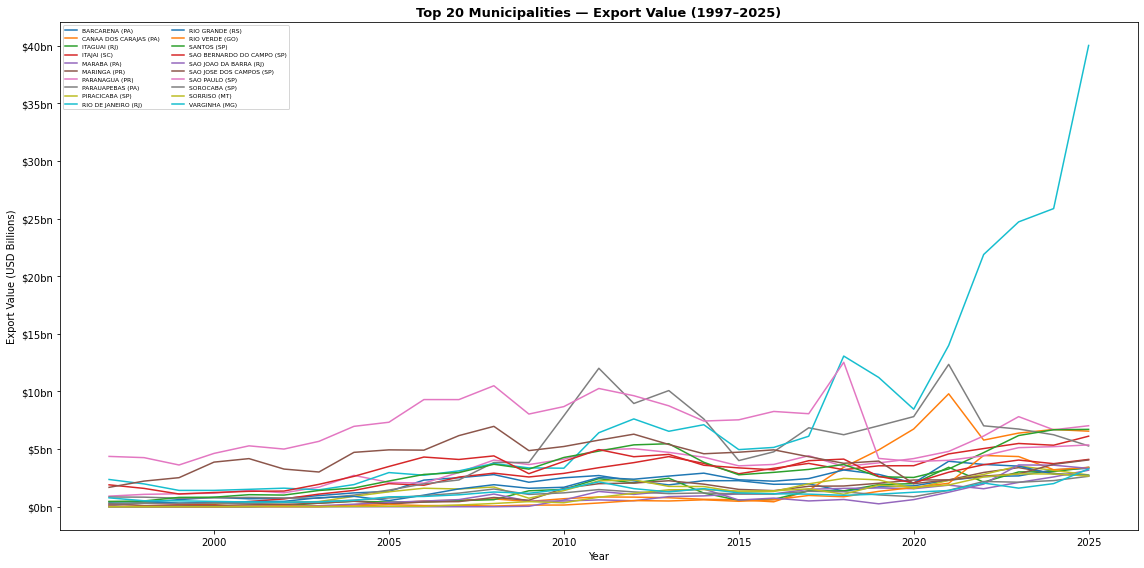

In [19]:
## Query municipality exports over time — top 20 by MAX_YEAR value
top20_mun = df_mun_exp.head(20)['mun_code'].tolist()
top20_mun_str = ', '.join([str(m) for m in top20_mun])  # bigint — no quotes

query_mun_time = f"""
    SELECT e."CO_ANO"            AS year,
           e."CO_MUN"            AS mun_code,
           m.nome_municipio       AS municipality,
           e."SG_UF_MUN"         AS uf,
           SUM(e."VL_FOB")       AS exports_usd
    FROM exp_mun e
    JOIN uf_mun m ON e."CO_MUN" = m.codigo_municipio
    WHERE e."CO_ANO" <= {MAX_YEAR}
    AND   e."CO_MUN" IN ({top20_mun_str})
    GROUP BY e."CO_ANO", e."CO_MUN", m.nome_municipio, e."SG_UF_MUN"
    ORDER BY e."CO_MUN", year
"""
df_mun_time = pd.read_sql(query_mun_time, engine)
df_mun_time['exports_usd_bn'] = df_mun_time['exports_usd'] / 1e9
df_mun_time['label'] = df_mun_time['municipality'] + ' (' + df_mun_time['uf'] + ')'

df_mun_pivot = df_mun_time.pivot(index='year', columns='label', values='exports_usd_bn').fillna(0)

fig, ax = plt.subplots(figsize=(16, 8))
for col in df_mun_pivot.columns:
    ax.plot(df_mun_pivot.index, df_mun_pivot[col], linewidth=1.5, label=col)

ax.set_title(f"Top 20 Municipalities — Export Value (1997–{MAX_YEAR})",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(fontsize=6, loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig('output_3_6_1_mun_time.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview

The 1997–2025 time series reveals one structurally dominant pattern and one structural break. The dominant pattern is compression — 19 of the top 20 municipalities trade within a narrow \\$0–\\$14bn band throughout the entire period with no individual municipality sustaining breakout growth above that range. The structural break is Rio de Janeiro, which diverges from the pack after 2020 and reaches \\$40bn by 2025 — a trajectory with no precedent in the dataset and no comparable municipality anywhere near it.

**Rio de Janeiro's post-2020 divergence is the defining feature of the chart.** From approximately \\$5bn in 2019, registered export value accelerates to \\$25bn by 2022 and \\$40bn by 2025. The scale and speed of this divergence — occurring in a single municipality over five years — compresses all other lines visually and makes the chart's primary value the illustration of this anomaly rather than the trajectories of the remaining 19 municipalities. The driver is not examined at municipality level until Step 4 but is consistent with the petroleum registration concentration identified throughout Sections 3.1 and 3.5.

**The remaining 19 municipalities show broadly flat trajectories relative to Rio de Janeiro's scale.** Most oscillate within a \\$1–\\$8bn range across the full 28-year period with moderate growth. The absence of any second municipality approaching sustained breakout growth above \\$14bn confirms that Rio de Janeiro's trajectory is a structural outlier rather than part of a broader pattern of municipality-level export acceleration.

**The 2011 peak and 2015 trough visible in several lines mirrors the state-level finding from Section 2.2.** The commodity price cycle that drove national export growth to a peak around 2011 and contraction through 2015–2016 is visible at municipality level — confirming that the cycle affected registered export activity across multiple locations simultaneously rather than being concentrated in specific municipalities.

*Note: The analytical value of this chart is limited to the macro observations above. The CAGR and YoY table in Section 3.6.2 provides the municipality-level growth detail that the overlapping line chart cannot legibly convey.*

---
---

### 3.6.2 — Top 20 Municipality Growth — CAGR and Year-on-Year Table
Growth summary table for the top 20 municipalities showing 1997 and 2025 export values, compound annual growth rate (CAGR) over the full period, and year-on-year change from 2024 to 2025. CAGR measures long-run structural growth; YoY captures recent momentum. Municipalities absent from the 1997 data (new industrial clusters) will show no CAGR and are flagged with a dash.

In [20]:
## ── Growth summary: CAGR and YoY for top 20 municipalities ─────────────────
growth_rows = []
for mun in top20_mun:
    subset = df_mun_time[df_mun_time['mun_code'] == mun].sort_values('year')
    if len(subset) < 2:
        continue
    label      = subset['label'].iloc[0]
    uf         = subset['uf'].iloc[0]
    val_start  = subset[subset['year'] == MIN_YEAR]['exports_usd'].values
    val_end    = subset[subset['year'] == MAX_YEAR]['exports_usd'].values
    val_prev   = subset[subset['year'] == MAX_YEAR - 1]['exports_usd'].values
    if len(val_start) == 0 or len(val_end) == 0:
        continue
    n_years = MAX_YEAR - MIN_YEAR
    cagr    = ((val_end[0] / val_start[0]) ** (1 / n_years) - 1) * 100 if val_start[0] > 0 else None
    yoy     = ((val_end[0] / val_prev[0]) - 1) * 100 if len(val_prev) > 0 and val_prev[0] > 0 else None
    growth_rows.append({
        'Municipality' : label,
        'UF'           : uf,
        f'{MIN_YEAR} (USD bn)' : round(val_start[0] / 1e9, 2),
        f'{MAX_YEAR} (USD bn)' : round(val_end[0]   / 1e9, 2),
        'CAGR (%)'     : round(cagr, 1) if cagr else None,
        'YoY (%)'      : round(yoy, 1)  if yoy  else None,
    })

df_growth_mun = pd.DataFrame(growth_rows).sort_values(f'{MAX_YEAR} (USD bn)', ascending=False)
for col in [f'{MIN_YEAR} (USD bn)', f'{MAX_YEAR} (USD bn)']:
    df_growth_mun[col] = df_growth_mun[col].apply(lambda x: f'\${x:.2f}bn')
for col in ['CAGR (%)', 'YoY (%)']:
    df_growth_mun[col] = df_growth_mun[col].apply(
        lambda x: f'{x:+.1f}%' if pd.notna(x) else '—'
    )
print(f"\nMunicipality Export Growth Summary — {MIN_YEAR} to {MAX_YEAR}")
display(
    df_growth_mun.style
    .set_caption(f'Top 20 Municipality Export Growth ({MIN_YEAR}–{MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)


Municipality Export Growth Summary — 1997 to 2025


Municipality,UF,1997 (USD bn),2025 (USD bn),CAGR (%),YoY (%)
RIO DE JANEIRO (RJ),RJ,\$2.37bn,\$40.03bn,+10.6%,+54.7%
PARANAGUA (PR),PR,\$0.92bn,\$7.03bn,+7.5%,+5.2%
SANTOS (SP),SP,\$0.46bn,\$6.71bn,+10.1%,+0.5%
ITAJAI (SC),SC,\$0.18bn,\$6.12bn,+13.3%,+14.7%
SAO PAULO (SP),SP,\$4.37bn,\$5.36bn,+0.7%,+2.9%
PARAUAPEBAS (PA),PA,\$0.85bn,\$5.28bn,+6.7%,-15.5%
SAO BERNARDO DO CAMPO (SP),SP,\$1.90bn,\$4.11bn,+2.8%,+9.8%
SAO JOSE DOS CAMPOS (SP),SP,\$1.68bn,\$4.06bn,+3.2%,+10.4%
ITAGUAI (RJ),RJ,\$0.00bn,\$3.42bn,+36.9%,+12.2%
RIO VERDE (GO),GO,\$0.03bn,\$3.42bn,+17.8%,+6.5%


#### Overview

The growth table confirms the two-tier structure visible in the chart — Rio de Janeiro is a structural outlier and the remaining municipalities form a second tier with materially lower but more consistent long-run growth. Three additional findings emerge at municipality level that were not visible in the chart.

**Rio de Janeiro's +10.6% CAGR understates the recency of its growth.** Starting from \\$2.37bn in 1997 the full-period CAGR appears moderate, but the +54.7% YoY confirms that the majority of the \\$40.03bn 2025 figure was registered in the final years of the period — consistent with the post-2020 acceleration visible in the chart. The CAGR is misleading as a long-run growth measure for this municipality.

**Itajaí (+13.3% CAGR) and Rio Verde (+17.8% CAGR) are the strongest sustained growers outside structural outliers.** Itajaí grew from \\$0.18bn to \\$6.12bn — a 34x increase over 28 years — with a +14.7% YoY confirming continued momentum. Rio Verde grew from \\$0.03bn to \\$3.42bn. Both CAGRs reflect growth from a near-zero base rather than expansion of an already large registration base, which limits direct comparison with municipalities that started the period at scale.

**São Paulo city (+0.7% CAGR) is the weakest performer in the table in long-run growth terms.** Starting from the largest 1997 base of any municipality (\\$4.37bn) it reached only \\$5.36bn by 2025 — a 23% total increase over 28 years against a national export increase of approximately 6.6x over the same period. Registered export activity in São Paulo city has been effectively flat in real terms while the broader export base expanded significantly around it.

**Three municipalities show negative YoY** — Parauapebas (-15.5%), Piracicaba (-12.7%), and Maringá (-7.0%) — indicating recent registered export value contraction against their 2024 levels. Parauapebas at -15.5% is the most significant given its scale (\\$5.28bn) and warrants monitoring ahead of Step 4.

**Varginha's +63.8% YoY is the highest single-year growth rate in the table** and is inconsistent with its long-run CAGR of +5.3%. A single-year jump of this magnitude in a municipality registering \\$3.29bn suggests either a significant new registration event, a reclassification, or a one-off export transaction rather than structural growth. This requires NCM-level confirmation before the figure is used in any forward-looking analysis.

**Itaguaí and Sorriso both show near-zero 1997 bases** — \\$0.00bn and \\$0.00bn respectively — making their CAGRs (+36.9% and +30.0%) mathematically large but reflecting entry into the export registration base during the period rather than sustained compound growth from scale. Their 2025 values of \\$3.42bn and \\$2.67bn are the more analytically relevant figures.

---
---

### 3.6.3 — Export Growth Decomposition: Price vs Volume at Municipality Level (2025 vs 2020)
Decomposes export value growth for the top 20 municipalities into price and volume components by comparing average unit value (USD/kg) in 2020 and 2025 against volume (kg) change over the same period. Municipalities where growth is driven by volume expansion are classified as commodity-scaling; municipalities where growth is driven by unit value increase are classified as value-upgrading. Connects the municipality-level growth findings from 3.6.1 to the commodity-industrial divide identified in Steps 2 and 2c, and provides a forward link to the multi-year decomposition planned for Step 5.

Export Growth Decomposition — Top 20 Municipalities (2020 vs 2025)
         municipality uf  value_growth_%  volume_growth_%  price_growth_%            driver
    SAO JOAO DA BARRA RJ           437.7            513.1           -12.3 Commodity-Scaling
       RIO DE JANEIRO RJ           372.9            214.9            50.1 Commodity-Scaling
             SOROCABA SP           204.0             76.6            72.2 Commodity-Scaling
               SANTOS SP           164.1             95.2            35.3 Commodity-Scaling
             VARGINHA MG           161.5             -5.9           177.8   Value-Upgrading
            RIO VERDE GO           104.0             68.6            21.0 Commodity-Scaling
  SAO JOSE DOS CAMPOS SP           102.7             21.4            67.0   Value-Upgrading
               MARABA PA           102.6             -4.9           113.1   Value-Upgrading
SAO BERNARDO DO CAMPO SP            98.5             35.0            47.0   Value-Upgrading
            B

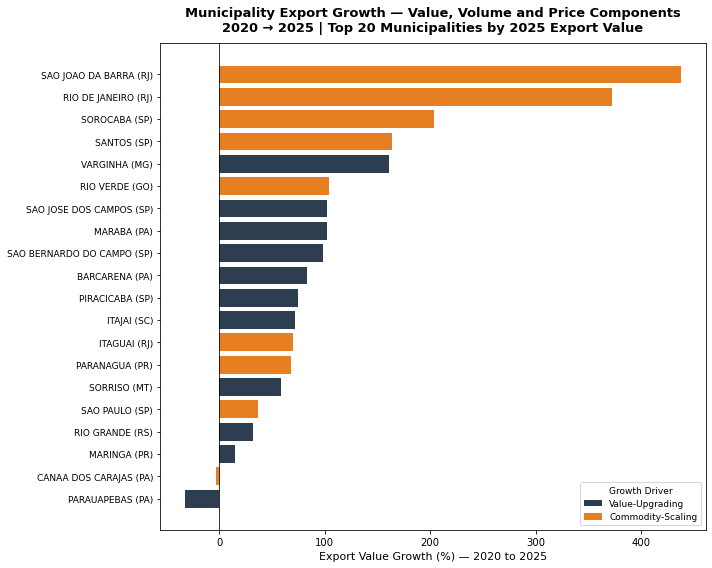

Municipality,UF,Exports 2020 (USD),Exports 2025 (USD),Value Growth (%),Volume Growth (%),Price Growth (%),Growth Driver
SAO JOAO DA BARRA,RJ,$0.62bn,$3.32bn,437.7%,513.1%,-12.3%,Commodity-Scaling
RIO DE JANEIRO,RJ,$8.46bn,$40.03bn,372.9%,214.9%,50.1%,Commodity-Scaling
SOROCABA,SP,$0.87bn,$2.64bn,204.0%,76.6%,72.2%,Commodity-Scaling
SANTOS,SP,$2.54bn,$6.71bn,164.1%,95.2%,35.3%,Commodity-Scaling
VARGINHA,MG,$1.26bn,$3.29bn,161.5%,-5.9%,177.8%,Value-Upgrading
RIO VERDE,GO,$1.68bn,$3.42bn,104.0%,68.6%,21.0%,Commodity-Scaling
SAO JOSE DOS CAMPOS,SP,$2.00bn,$4.06bn,102.7%,21.4%,67.0%,Value-Upgrading
MARABA,PA,$1.56bn,$3.17bn,102.6%,-4.9%,113.1%,Value-Upgrading
SAO BERNARDO DO CAMPO,SP,$2.07bn,$4.11bn,98.5%,35.0%,47.0%,Value-Upgrading
BARCARENA,PA,$1.82bn,$3.33bn,83.2%,12.4%,63.0%,Value-Upgrading


In [21]:
## ── Query unit value and volume for top 20 municipalities — 2020 and 2025 ───
query_decomp = f"""
    SELECT e."CO_ANO"            AS year,
           e."CO_MUN"            AS mun_code,
           m.nome_municipio       AS municipality,
           e."SG_UF_MUN"         AS uf,
           u.nome_estado          AS state,
           SUM(e."VL_FOB")       AS exports_usd,
           SUM(e."KG_LIQUIDO")   AS kg_total
    FROM exp_mun e
    JOIN uf_mun m ON e."CO_MUN"    = m.codigo_municipio
    JOIN uf u     ON e."SG_UF_MUN" = u.sigla
    WHERE e."CO_ANO" IN (2020, {MAX_YEAR})
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA','CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA','REEXPORTACAO'
    )
    GROUP BY e."CO_ANO", e."CO_MUN", m.nome_municipio,
             e."SG_UF_MUN", u.nome_estado
"""

df_decomp_raw = pd.read_sql(query_decomp, engine)

## ── Pivot exports and kg only — compute usd_per_kg after ────────────────────
df_decomp = df_decomp_raw.pivot_table(
    index=['mun_code', 'municipality', 'uf', 'state'],
    columns='year',
    values=['exports_usd', 'kg_total']
).reset_index()

## Flatten columns
new_cols = []
for col in df_decomp.columns:
    if isinstance(col, tuple):
        val, yr = col
        new_cols.append(f'{val}_{yr}' if yr != '' else val)
    else:
        new_cols.append(col)
df_decomp.columns = new_cols

## Keep only municipalities with data in both years
df_decomp = df_decomp.dropna(subset=[
    'exports_usd_2020', 'exports_usd_2025',
    'kg_total_2020', 'kg_total_2025'
])

## Compute unit value after pivot
df_decomp['usd_per_kg_2020'] = (
    df_decomp['exports_usd_2020'] /
    df_decomp['kg_total_2020'].replace(0, np.nan)
)

df_decomp['usd_per_kg_2025'] = (
    df_decomp['exports_usd_2025'] /
    df_decomp['kg_total_2025'].replace(0, np.nan)
)

## Restrict to top 20 by 2025 export value
top20_muns = (
    df_decomp.nlargest(20, 'exports_usd_2025')['mun_code'].tolist()
)
df_decomp = df_decomp[df_decomp['mun_code'].isin(top20_muns)].copy()

## Compute decomposition components
df_decomp['value_growth_%'] = (
    (df_decomp['exports_usd_2025'] - df_decomp['exports_usd_2020'])
    / df_decomp['exports_usd_2020'] * 100
).round(1)

df_decomp['volume_growth_%'] = (
    (df_decomp['kg_total_2025'] - df_decomp['kg_total_2020'])
    / df_decomp['kg_total_2020'] * 100
).round(1)

df_decomp['price_growth_%'] = (
    (df_decomp['usd_per_kg_2025'] - df_decomp['usd_per_kg_2020'])
    / df_decomp['usd_per_kg_2020'] * 100
).round(1)

## Classify driver
def classify_driver(row):
    if pd.isna(row['price_growth_%']) or pd.isna(row['volume_growth_%']):
        return 'Insufficient Data'
    elif row['price_growth_%'] > row['volume_growth_%']:
        return 'Value-Upgrading'
    elif row['volume_growth_%'] > row['price_growth_%']:
        return 'Commodity-Scaling'
    else:
        return 'Mixed'

df_decomp['driver'] = df_decomp.apply(classify_driver, axis=1)
df_decomp = df_decomp.sort_values('value_growth_%', ascending=False)

print("Export Growth Decomposition — Top 20 Municipalities (2020 vs 2025)")
print(df_decomp[['municipality', 'uf', 'value_growth_%',
                  'volume_growth_%', 'price_growth_%', 'driver']
                ].to_string(index=False))

## ── Chart ────────────────────────────────────────────────────────────────────
driver_colors = {
    'Value-Upgrading'   : '#2c3e50',
    'Commodity-Scaling' : '#e67e22',
    'Mixed'             : '#95a5a6',
    'Insufficient Data' : '#bdc3c7',
}

fig, ax = plt.subplots(figsize=(10, 8))

colors = df_decomp['driver'].map(driver_colors)
y_pos  = range(len(df_decomp))
labels = df_decomp['municipality'] + ' (' + df_decomp['uf'] + ')'

ax.barh(list(y_pos), df_decomp['value_growth_%'].values,
        color=colors, edgecolor='none')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Export Value Growth (%) — 2020 to 2025', fontsize=11)
ax.set_title(
    'Municipality Export Growth — Value, Volume and Price Components\n'
    '2020 → 2025 | Top 20 Municipalities by 2025 Export Value',
    fontsize=13, fontweight='bold', pad=12
)

legend_handles = [
    Patch(facecolor=c, label=l)
    for l, c in driver_colors.items()
    if l in df_decomp['driver'].unique()
]
ax.legend(handles=legend_handles, title='Growth Driver',
          fontsize=9, title_fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

## ── Styled table ─────────────────────────────────────────────────────────────
display(
    df_decomp[['municipality', 'uf', 'exports_usd_2020', 'exports_usd_2025',
               'value_growth_%', 'volume_growth_%', 'price_growth_%', 'driver']]
    .rename(columns={
        'municipality'     : 'Municipality',
        'uf'               : 'UF',
        'exports_usd_2020' : 'Exports 2020 (USD)',
        'exports_usd_2025' : 'Exports 2025 (USD)',
        'value_growth_%'   : 'Value Growth (%)',
        'volume_growth_%'  : 'Volume Growth (%)',
        'price_growth_%'   : 'Price Growth (%)',
        'driver'           : 'Growth Driver',
    })
    .style
    .format({
        'Exports 2020 (USD)' : lambda x: f'${x/1e9:.2f}bn',
        'Exports 2025 (USD)' : lambda x: f'${x/1e9:.2f}bn',
        'Value Growth (%)'   : '{:.1f}%',
        'Volume Growth (%)'  : '{:.1f}%',
        'Price Growth (%)'   : '{:.1f}%',
    })
    .set_caption('Export Growth Decomposition — Top 20 Municipalities (2020 vs 2025)')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

#### Overview
Twelve of the top 20 municipalities by 2025 export value are classified as value-upgrading and eight as commodity-scaling over the 2020–2025 period. All but two municipalities — Canaã dos Carajás (\\$-2.8%) and Parauapebas (\\$-32.5%) — recorded positive value growth. The 2020 base year captures the first full COVID year, which depresses the starting point for several municipalities and inflates the growth rates accordingly — this caveat applies particularly to the extreme figures at the top of the ranking.

#### Business Relevance
São João da Barra (437.7%) and Rio de Janeiro (372.9%) lead the ranking but for different reasons. São João da Barra's growth is volume-driven (513.1% volume, \\$-12.3% price) — a commodity-scaling result consistent with expanded oil export registration from the Porto do Açu complex. Rio de Janeiro's growth combines volume (214.9%) and price (50.1%) — the price component reflecting the oil price recovery from COVID lows rather than structural value upgrading.

The value-upgrading classification is most meaningful where volume growth is negative or flat while price growth is strongly positive. Varginha (\\$-5.9% volume, +177.8% price) is the clearest case — a municipality where the same or smaller physical volume is generating substantially higher USD value per kg, consistent with either a shift toward higher-grade coffee or improved pricing conditions. Marabá (\\$-4.9% volume, +113.1% price) and Rio Grande (\\$-7.2% volume, +42.5% price) follow the same pattern.

The São Paulo industrial cluster — São José dos Campos, São Bernardo do Campo, Piracicaba, Sorocaba — shows value-upgrading or near-balanced decomposition across all four municipalities, with price growth consistently outpacing or matching volume growth. This is consistent with the manufactured goods and aerospace export base identified in Section 3.7.1 and the low China share from Section 3.7.2 — these municipalities are growing through higher unit value rather than volume expansion.

Parauapebas (\\$-32.5%) is the only municipality with a significant negative value growth figure. Both volume and price declined, indicating that the reduction in registered export value reflects genuine contraction in iron ore shipment registration at this location — whether through operational changes, registration shifts to other municipalities, or market conditions — rather than a price or volume effect in isolation. Cross-referencing against Canaã dos Carajás, which also declined slightly (\\$-2.8%), suggests that Carajás complex iron ore registrations may have shifted between municipalities within the same operational area between 2020 and 2025.

*⚠️ The 2020 COVID base year inflates growth rates for municipalities with severely depressed 2020 activity — Rio de Janeiro, São João da Barra and Santos are the most affected. These figures should be interpreted as recovery trajectories rather than structural growth rates. A 2019 vs 2025 comparison would provide a more stable baseline and is noted as a potential refinement for Step 5.*


---
---

## 3.7 — Municipality Product Profiles: What Do the Top Municipalities Export?
Top 5 export sectors (SH2) for the top 20 municipalities by export value — connecting municipality-level scale to product composition. Joins `exp_mun` to `ncm_sh` via `SH4` to retrieve SH2 sector descriptions, then aggregates by municipality and sector. Determines whether municipality export identity mirrors state-level profiles from Section 2.4 or reveals sub-state product specialisation not visible at the state level.
For each of the top 20 municipalities, lists the five largest export sectors by FOB value with their share of that municipality's total exports — revealing the degree of product specialisation and whether dominant municipalities are single-sector exporters or diversified industrial hubs.

### 3.7.1 — Municipality Export Sector Profiles: What Do the Top Municipalities Export?
Breaks down the export composition of the top 20 municipalities by 2025 export value at SH2 sector level — identifying the specific product categories driving each municipality's trade and connecting the geographic concentration findings from Sections 3.1 and 3.4 to the sector structure analysis from Step 2. For each municipality, the top 5 sectors are ranked by share of total municipal export value, revealing whether high export values reflect single-commodity dominance or diversified industrial activity. Results provide the product-level foundation for the China dependency analysis in Section 3.7.2.

In [22]:
## Query top sectors per municipality for top 20 municipalities
top20_mun_str = ', '.join([str(m) for m in top20_mun])  # already fixed in 3.4, reuse

query_mun_sectors = f"""
    SELECT e."CO_MUN"                AS mun_code,
           m.nome_municipio           AS municipality,
           e."SG_UF_MUN"             AS uf,
           s.codigo_sh2               AS sh2_code,
           MAX(s.descricao_sh2_ing)   AS sector,
           SUM(e."VL_FOB")           AS exports_usd
    FROM exp_mun e
    JOIN uf_mun m  ON e."CO_MUN"  = m.codigo_municipio
    JOIN (
        SELECT DISTINCT codigo_sh4, codigo_sh2, descricao_sh2_ing
        FROM ncm_sh
    ) s ON e."SH4" = s.codigo_sh4
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND   e."CO_MUN" IN ({top20_mun_str})
    GROUP BY e."CO_MUN", m.nome_municipio, e."SG_UF_MUN", s.codigo_sh2
    ORDER BY e."CO_MUN", exports_usd DESC
"""

df_mun_sectors = pd.read_sql(query_mun_sectors, engine)
df_mun_sectors['exports_usd_bn'] = (df_mun_sectors['exports_usd'] / 1e9).round(3)

## Top 5 sectors per municipality
df_top5_sectors = (
    df_mun_sectors
    .groupby('mun_code', group_keys=False)
    .apply(lambda x: x.nlargest(5, 'exports_usd'))
    .reset_index(drop=True)
)
mun_totals = df_mun_sectors.groupby('mun_code')['exports_usd'].sum()
df_top5_sectors['mun_total']  = df_top5_sectors['mun_code'].map(mun_totals)
df_top5_sectors['sector_share_%'] = (
    df_top5_sectors['exports_usd'] / df_top5_sectors['mun_total'] * 100
).round(1)

## Print profiles
#print(f"Top 5 Export Sectors by Municipality ({MAX_YEAR})")
#print("=" * 70)
#for mun_code in top20_mun:
#    subset = df_top5_sectors[df_top5_sectors['mun_code'] == mun_code]
#    if subset.empty:
#        continue
#    mun_name = subset['municipality'].iloc[0]
#    uf_code  = subset['uf'].iloc[0]
#    mun_total = subset['mun_total'].iloc[0] / 1e9
#    print(f"\n  {mun_name} ({uf_code}) — Total: \${mun_total:.2f}bn")
#    for _, row in subset.iterrows():
#        print(f"  {str(row['sector'])[:50]:<50} "              f"\${row['exports_usd_bn']:.2f}bn  "              f"({row['sector_share_%']:.1f}%)")

## ── Styled tables: top 5 sectors per municipality ────────────────────────────
for mun_code in top20_mun:
    subset = df_top5_sectors[df_top5_sectors['mun_code'] == mun_code].copy()
    if subset.empty:
        continue

    mun_name  = subset['municipality'].iloc[0]
    uf_code   = subset['uf'].iloc[0]
    mun_total = subset['mun_total'].iloc[0] / 1e9
    top5_share = subset['sector_share_%'].sum()

    subset['Cumulative (%)']    = subset['sector_share_%'].cumsum().round(1)
    subset['Exports (USD bn)']  = subset['exports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
    subset['Share (%)']         = subset['sector_share_%'].apply(lambda x: f'{x:.1f}%')
    subset['Cumulative (%)']    = subset['Cumulative (%)'].apply(lambda x: f'{x:.1f}%')

    display_df = subset[['sector', 'Exports (USD bn)', 'Share (%)', 'Cumulative (%)']].rename(
        columns={'sector': 'Sector (SH2)'}
    )

    print(f"\n{mun_name} ({uf_code}) — Total: ${mun_total:.2f}bn | Top 5 sector share: {top5_share:.1f}%")
    display(
        display_df.style
        .set_caption(f'{mun_name} ({uf_code}) — Top 5 Export Sectors ({MAX_YEAR})')
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                          ('color', 'white'), ('font-weight', 'bold')]},
            {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
        ])
        .hide_index()
    )


RIO DE JANEIRO (RJ) — Total: $40.03bn | Top 5 sector share: 98.6%


Sector (SH2),Exports (USD bn),Share (%),Cumulative (%)
"Mineral fuels, mineral oils, bituminous substances; mineral waxes",$36.99bn,92.4%,92.4%
Iron and steel,$1.84bn,4.6%,97.0%
"Nuclear reactors, boilers, machinery and mechanical appliances; others",$0.34bn,0.8%,97.8%
Rubber and articles thereof,$0.16bn,0.4%,98.2%
"Aircraft, spacecraft, and parts thereof",$0.15bn,0.4%,98.6%



PARANAGUA (PR) — Total: $7.03bn | Top 5 sector share: 94.6%


Sector (SH2),Exports (USD bn),Share (%),Cumulative (%)
"Oil seeds and oleaginous fruits; Grains, Seeds, others",$3.51bn,49.9%,49.9%
Meat and edible meat offal,$1.81bn,25.8%,75.7%
Sugars and sugar confectionery,$0.53bn,7.5%,83.2%
Residues and waste from the food industries; others,$0.48bn,6.8%,90.0%
Cereals,$0.33bn,4.6%,94.6%



SANTOS (SP) — Total: $6.71bn | Top 5 sector share: 94.2%


...

Sector (SH2),Exports (USD bn),Share (%),Cumulative (%)
"Oil seeds and oleaginous fruits; Grains, Seeds, others",$1.51bn,56.3%,56.3%
Cereals,$0.56bn,20.7%,77.0%
Sugars and sugar confectionery,$0.35bn,13.0%,90.0%
Meat and edible meat offal,$0.12bn,4.6%,94.6%
Residues and waste from the food industries; others,$0.06bn,2.3%,96.9%



SORRISO (MT) — Total: $2.67bn | Top 5 sector share: 99.8%


Sector (SH2),Exports (USD bn),Share (%),Cumulative (%)
"Oil seeds and oleaginous fruits; Grains, Seeds, others",$1.72bn,64.6%,64.6%
Cereals,$0.65bn,24.2%,88.8%
Residues and waste from the food industries; others,$0.18bn,6.7%,95.5%
Edible vegetables and certain roots and tubers,$0.08bn,3.1%,98.6%
Cotton,$0.03bn,1.2%,99.8%



SOROCABA (SP) — Total: $2.64bn | Top 5 sector share: 92.2%


Sector (SH2),Exports (USD bn),Share (%),Cumulative (%)
"Vehicles other than railway or tramway rolling-stock, and parts and accessories thereof",$1.49bn,56.4%,56.4%
"Nuclear reactors, boilers, machinery and mechanical appliances; others",$0.49bn,18.5%,74.9%
Electrical machinery and equipment and parts thereof; others,$0.32bn,12.1%,87.0%
"Optical, photographic, cinematographic instruments; others",$0.09bn,3.5%,90.5%
Articles of iron or steel,$0.04bn,1.7%,92.2%


#### Overview

The sector profiles confirm and extend the structural findings from earlier sections. Across the top 20 municipalities three distinct export archetypes are visible at product level: single-sector dominant municipalities, commodity aggregation municipalities registering multiple agricultural sectors, and diversified industrial municipalities registering manufactured goods across several categories.

**Three municipalities register a single sector at effectively 100%.** Canaã dos Carajás (ores 100.0%), Parauapebas (ores 100.0%), and Itaguaí (ores 99.8%) have no meaningful secondary sector — their entire registered export identity is a single product category. Rio de Janeiro approaches this with mineral fuels at 92.4%, leaving only 7.6% across four additional sectors. These four are the most exposed to single-sector price and demand risk in the dataset.

**Varginha (MG) at 97.7% coffee is the only non-mineral single-sector municipality in the top 20.** Its entire registered export identity is a single agricultural commodity — coffee — with no industrial or diversification component. Combined with its +63.8% YoY from Section 3.6.2, the concentration in a single perishable agricultural commodity makes Varginha the most exposed municipality to sector-specific price volatility outside the mineral extraction group.

**São Bernardo do Campo (69.2% vehicles), São José dos Campos (78.1% aircraft), Sorocaba (56.4% vehicles), and Piracicaba (67.6% machinery) form a distinct São Paulo industrial cluster** — each registering manufactured goods as their primary sector. These four are the only municipalities in the top 20 where the leading sector is a manufactured product rather than a commodity or mineral fuel. Together they account for \\$14.57bn in registered exports across four distinct industrial categories, confirming the diversified manufacturing base identified in Section 3.5.1.

**Paranaguá and Maringá (PR) show overlapping agricultural sector profiles** — both register oil seeds as their primary sector (49.9% and 56.3% respectively) with meat and cereals as secondary sectors. The near-identical sector composition across two municipalities in the same state is consistent with both registering exports from the same agricultural production base in the Paraná interior.

**Barcarena (PA) is the most structurally distinct municipality in the Pará group.** While Canaã dos Carajás, Parauapebas, and Itaguaí register exclusively in ores, Barcarena registers inorganic chemicals (65.8%) and aluminium (19.3%) — confirming a different registered production profile from the three ore municipalities despite being in the same state. This is the only municipality in the Pará top 5 that does not register primarily in ores.

**São Paulo city's sector profile is the most diversified in the top 20.** Sugars (29.2%), oil seeds (14.1%), precious stones (7.1%), machinery (4.3%), and mineral fuels (3.9%) across five materially different sectors — with no single sector exceeding 30% — is the broadest registered export profile in the dataset. No other municipality shows this level of sector diversification at the top-5 level, consistent with São Paulo's role as the primary commercial registration centre for a wide range of export activities.

**São João da Barra (RJ) registers two sectors that together account for 98.5% of exports** — mineral fuels (75.3%) and ores (23.2%). The combination of these two primary commodity sectors in a single municipality is unique in the top 20 and is consistent with its position as a secondary Rio de Janeiro state export registration location alongside the petroleum-dominant Rio de Janeiro city.

---
---

### 3.7.2 — Municipality-Level China Export Share: Where Is China Dependency Concentrated?
Quantifies the share of each top municipality's exports destined for China, extending the state-level China dependency analysis from Section 2.7 to the municipality level. Identifies whether China exposure is concentrated in a small number of commodity export hubs — consistent with the state-level finding that commodity-dominant states show higher China share — or distributed across municipalities with different product profiles. Results are ranked by China share and cross-referenced against the product profiles from Section 3.7.1.

National average China share (top 20 municipalities): 35.5%
         municipality uf  china_share_%  total_exports  china_exports
              ITAGUAI RJ           88.2   3.416229e+09   3.012451e+09
          PARAUAPEBAS PA           75.2   5.277065e+09   3.969828e+09
    CANAA DOS CARAJAS PA           63.2   6.555345e+09   4.142529e+09
            RIO VERDE GO           62.0   3.416505e+09   2.117855e+09
              MARINGA PR           54.5   2.679299e+09   1.461067e+09
            PARANAGUA PR           47.2   7.029507e+09   3.314432e+09
              SORRISO MT           45.9   2.666086e+09   1.223172e+09
       RIO DE JANEIRO RJ           41.9   4.002668e+10   1.677258e+10
           RIO GRANDE RS           38.0   2.718469e+09   1.033763e+09
    SAO JOAO DA BARRA RJ           31.0   3.324647e+09   1.032081e+09
               SANTOS SP           27.6   6.713624e+09   1.853266e+09
            SAO PAULO SP           19.1   5.364934e+09   1.024199e+09
               MARABA PA      

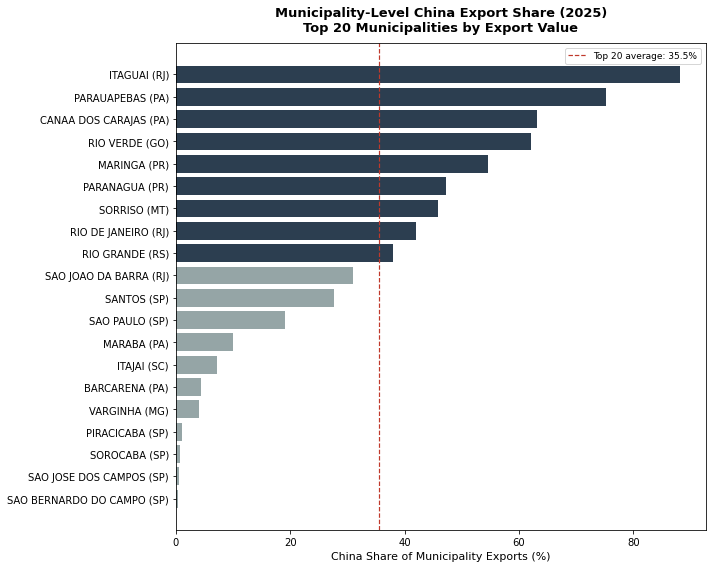

Municipality,UF,Total Exports (USD bn),China Exports (USD bn),China Share (%)
ITAGUAI,RJ,$3.42bn,$3.01bn,88.2%
PARAUAPEBAS,PA,$5.28bn,$3.97bn,75.2%
CANAA DOS CARAJAS,PA,$6.56bn,$4.14bn,63.2%
RIO VERDE,GO,$3.42bn,$2.12bn,62.0%
MARINGA,PR,$2.68bn,$1.46bn,54.5%
PARANAGUA,PR,$7.03bn,$3.31bn,47.2%
SORRISO,MT,$2.67bn,$1.22bn,45.9%
RIO DE JANEIRO,RJ,$40.03bn,$16.77bn,41.9%
RIO GRANDE,RS,$2.72bn,$1.03bn,38.0%
SAO JOAO DA BARRA,RJ,$3.32bn,$1.03bn,31.0%


In [23]:
## ── Get top 20 municipalities by 2025 export value ───────────────────────────
top20_mun_codes = (
    df_mun_exp.nlargest(20, 'exports_usd')['mun_code'].tolist()
)
mun_codes_sql = ', '.join(str(c) for c in top20_mun_codes)

## China country code in MDIC data is 160
CHINA_CODE = 160

query_china = f"""
    SELECT e."CO_MUN"             AS mun_code,
           m.nome_municipio        AS municipality,
           e."SG_UF_MUN"          AS uf,
           SUM(e."VL_FOB")        AS total_exports,
           SUM(CASE WHEN e."CO_PAIS" = {CHINA_CODE}
                    THEN e."VL_FOB" ELSE 0 END) AS china_exports
    FROM exp_mun e
    JOIN uf_mun m ON e."CO_MUN"    = m.codigo_municipio
    JOIN uf u     ON e."SG_UF_MUN" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."CO_MUN" IN ({mun_codes_sql})
    GROUP BY e."CO_MUN", m.nome_municipio, e."SG_UF_MUN"
"""

df_china = pd.read_sql(query_china, engine)
df_china['china_share_%'] = (
    df_china['china_exports'] / df_china['total_exports'] * 100
).round(1)
df_china = df_china.sort_values('china_share_%', ascending=False)

## National average for reference line
national_china_share = (
    df_china['china_exports'].sum() / df_china['total_exports'].sum() * 100
)
print(f"National average China share (top 20 municipalities): "
      f"{national_china_share:.1f}%")
print(df_china[['municipality', 'uf', 'china_share_%',
                 'total_exports', 'china_exports']].to_string(index=False))

## ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

bar_colors = [
    '#2c3e50' if x >= national_china_share else '#95a5a6'
    for x in df_china['china_share_%']
]
labels = df_china['municipality'] + ' (' + df_china['uf'] + ')'

ax.barh(labels.tolist(), df_china['china_share_%'].tolist(),
        color=bar_colors, edgecolor='none')
ax.axvline(national_china_share, color='#c0392b', linewidth=1.2,
           linestyle='--',
           label=f'Top 20 average: {national_china_share:.1f}%')
ax.invert_yaxis()
ax.set_xlabel('China Share of Municipality Exports (%)', fontsize=11)
ax.set_title(
    'Municipality-Level China Export Share (2025)\n'
    'Top 20 Municipalities by Export Value',
    fontsize=13, fontweight='bold', pad=12
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## ── Styled table ─────────────────────────────────────────────────────────────
display(
    df_china[['municipality', 'uf', 'total_exports',
              'china_exports', 'china_share_%']]
    .rename(columns={
        'municipality'  : 'Municipality',
        'uf'            : 'UF',
        'total_exports' : 'Total Exports (USD bn)',
        'china_exports' : 'China Exports (USD bn)',
        'china_share_%' : 'China Share (%)',
    })
    .style
    .format({
        'Total Exports (USD bn)': lambda x: f'${x/1e9:.2f}bn',
        'China Exports (USD bn)': lambda x: f'${x/1e9:.2f}bn',
        'China Share (%)'       : '{:.1f}%',
    })
    .set_caption('Municipality-Level China Export Share (2025)')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

#### Overview
China export share among the top 20 municipalities by export value divides sharply at the top-20 average of 35.5%. Nine municipalities sit above it — all commodity or bulk logistics registrations — and eleven sit below, concentrated in São Paulo state's industrial municipalities. The range is extreme: from 88.2% at Itaguaí to 0.3% at São Bernardo do Campo, a spread that reflects the full commodity-industrial divide operating at municipality level.

#### Business Relevance
The top of the ranking confirms that China dependency at municipality level is driven by a small number of high-concentration commodity export hubs. Itaguaí (88.2%, \\$3.01bn to China) exports almost exclusively iron ore — 99.8% ores and slag as shown in Section 3.7.1 — making it effectively a single-commodity, single-destination municipality. Parauapebas (75.2%) and Canaã dos Carajás (63.2%) are the same structural profile: Carajás iron ore complex registrations with China as the dominant destination. Rio Verde (62.0%) and Sorriso (45.9%) represent the agricultural equivalent — soy and corn municipalities where China accounts for the majority of registered export value.

This concentration has a direct risk implication. The five municipalities above 45% China share collectively export \\$24.84bn, of which \\$14.47bn is registered to China. A sustained reduction in Chinese demand for iron ore or soy — whether through policy, substitution or demand contraction — would affect these municipalities disproportionately and with limited alternative destination diversification available at short notice.

Rio de Janeiro city (41.9%, \\$16.77bn to China) is the largest absolute China-exposed municipality in the dataset by value. Given its oil and gas registration dominance identified in Steps 2 and 2c, this figure reflects crude oil exports to China rather than diversified commodity exposure — a structurally different risk profile from the ore and soy municipalities above it in the ranking.

The bottom half of the ranking is a near-complete map of São Paulo state's industrial export base. São José dos Campos (0.5%), São Bernardo do Campo (0.3%), Sorocaba (0.7%) and Piracicaba (1.0%) — aerospace, automotive and capital goods clusters — route almost none of their exports to China. This is the clearest municipality-level evidence of the commodity-industrial divide: the same municipalities that show low China share in this section are the value-upgrading municipalities in Section 3.6.2 and the low-HHI, high-frequency exporters consistent with Regression 1 in Step 2c.

Itajaí (7.2%, \\$0.44bn to China) is notable given its scale as the fifth largest exporting municipality in the dataset at \\$6.12bn. Its low China share indicates that its export base — whatever its composition — is not commodity-oriented toward the China market, which further distinguishes its export profile from its import profile and adds a dimension to the Step 4 investigation.

*⚠️ Marabá (9.9%) is lower than expected for a Pará iron ore municipality. This may reflect a product mix difference from Parauapebas and Canaã dos Carajás — Marabá's export base may include processed steel products alongside ore. NCM-level confirmation in Step 4 would clarify whether this represents genuine destination diversification or a product classification distinction.*

---
---

## 3.8 — Within-State Import Concentration: How Concentrated Is Each State's Import Activity?
Mirroring the export concentration analysis in Section 3.4 — measuring how many municipalities account for the majority of each state's import value and computing municipality-level HHI for imports. Identifies whether import activity is structurally more or less concentrated than exports, and whether the same states that show high export concentration also show high import concentration.

### 3.8.1 — Within-State Import Concentration — Summary Table
Ranked summary table of import concentration metrics by state — showing active municipality count, top 1/3 share, HHI, and the dominant import municipality for each state, ordered by HHI descending.

For each state, the municipality-level HHI and top 3 municipality share of total state imports — identifying whether import activity is driven by a single dominant city or distributed across multiple locations.

In [25]:
## Within-state import concentration
imp_conc_rows = []
for uf, group in df_mun_imp.groupby('uf'):
    group = group.sort_values('imports_usd', ascending=False).reset_index(drop=True)
    state_total = group['imports_usd'].sum()
    if state_total == 0:
        continue
    group['share'] = group['imports_usd'] / state_total
    hhi    = (group['share'] ** 2).sum()
    top3   = group['share'].iloc[:3].sum() * 100
    n_mun  = len(group)
    imp_conc_rows.append({
        'uf'         : uf,
        'state'      : group['state'].iloc[0],
        'region'     : group['region'].iloc[0],
        'n_mun_imp'  : n_mun,
        'top3_imp_%' : round(top3, 1),
        'hhi_imp'    : round(hhi, 4),
        'top_imp_mun': group['municipality'].iloc[0],
        'imp_total_bn': round(state_total / 1e9, 2),
    })

df_imp_conc = pd.DataFrame(imp_conc_rows).sort_values('hhi_imp', ascending=False)

## ── Styled summary table ──────────────────────────────────────────────────────
df_imp_conc_display = df_imp_conc[
    ['state', 'region', 'n_mun_imp', 'top3_imp_%', 'hhi_imp', 'top_imp_mun', 'imp_total_bn']
].copy().rename(columns={
    'state'        : 'State',
    'region'       : 'Region',
    'n_mun_imp'    : 'Active Municipalities',
    'top3_imp_%'   : 'Top 3 Share (%)',
    'hhi_imp'      : 'HHI',
    'top_imp_mun'  : 'Largest Import Municipality',
    'imp_total_bn' : 'State Total (USD bn)',
})
df_imp_conc_display['Top 3 Share (%)']      = df_imp_conc_display['Top 3 Share (%)'].apply(lambda x: f'{x:.1f}%')
df_imp_conc_display['HHI']                  = df_imp_conc_display['HHI'].apply(lambda x: f'{x:.4f}')
df_imp_conc_display['State Total (USD bn)'] = df_imp_conc_display['State Total (USD bn)'].apply(lambda x: f'${x:.2f}bn')

display(
    df_imp_conc_display.style
    .set_caption(f'Within-State Municipality Import Concentration ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

## ── Styled summary table: within-state import concentration ──────────────────
df_imp_conc_display = df_imp_conc[
    ['state', 'region', 'n_mun_imp', 'top3_imp_%', 'hhi_imp', 'top_imp_mun', 'imp_total_bn']
].copy().rename(columns={
    'state'        : 'State',
    'region'       : 'Region',
    'n_mun_imp'    : 'Active Municipalities',
    'top3_imp_%'   : 'Top 3 Share (%)',
    'hhi_imp'      : 'HHI',
    'top_imp_mun'  : 'Largest Import Municipality',
    'imp_total_bn' : 'State Total (USD bn)',
})
df_imp_conc_display['Top 3 Share (%)']      = df_imp_conc_display['Top 3 Share (%)'].apply(lambda x: f'{x:.1f}%')
df_imp_conc_display['HHI']                  = df_imp_conc_display['HHI'].apply(lambda x: f'{x:.4f}')
df_imp_conc_display['State Total (USD bn)'] = df_imp_conc_display['State Total (USD bn)'].apply(lambda x: f'${x:.2f}bn')

display(
    df_imp_conc_display.style
    .set_caption(f'Within-State Municipality Import Concentration ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

State,Region,Active Municipalities,Top 3 Share (%),HHI,Largest Import Municipality,State Total (USD bn)
Distrito Federal,Center-West,1,100.0%,1.0000,BRASILIA,$2.26bn
Amapá,North,3,100.0%,0.9882,MACAPA,$0.29bn
Roraima,North,5,99.8%,0.9794,BOA VISTA,$0.05bn
Amazonas,North,21,99.7%,0.9706,MANAUS,$16.06bn
Rondônia,North,21,98.5%,0.9079,PORTO VELHO,$2.25bn
Maranhão,Northeast,31,98.9%,0.8809,SAO LUIS,$4.76bn
Alagoas,Northeast,21,96.6%,0.7728,MACEIO,$1.12bn
Acre,North,5,95.8%,0.4376,RIO BRANCO,$0.01bn
Paraíba,Northeast,39,84.9%,0.3939,JOAO PESSOA,$0.99bn
Espírito Santo,Southeast,48,89.1%,0.3426,CARIACICA,$13.81bn


State,Region,Active Municipalities,Top 3 Share (%),HHI,Largest Import Municipality,State Total (USD bn)
Distrito Federal,Center-West,1,100.0%,1.0000,BRASILIA,$2.26bn
Amapá,North,3,100.0%,0.9882,MACAPA,$0.29bn
Roraima,North,5,99.8%,0.9794,BOA VISTA,$0.05bn
Amazonas,North,21,99.7%,0.9706,MANAUS,$16.06bn
Rondônia,North,21,98.5%,0.9079,PORTO VELHO,$2.25bn
Maranhão,Northeast,31,98.9%,0.8809,SAO LUIS,$4.76bn
Alagoas,Northeast,21,96.6%,0.7728,MACEIO,$1.12bn
Acre,North,5,95.8%,0.4376,RIO BRANCO,$0.01bn
Paraíba,Northeast,39,84.9%,0.3939,JOAO PESSOA,$0.99bn
Espírito Santo,Southeast,48,89.1%,0.3426,CARIACICA,$13.81bn


#### Overview
The styled table consolidates the HHI, top-3 share, active municipality count and state import total into a single reference. States are ordered by HHI descending, placing the most concentrated at the top and the most distributed at the bottom. The four regions sort broadly but not perfectly along this axis — North and Northeast dominate the upper half, Southeast and South the lower half, with Center-West distributed across both.

#### Business Relevance
The HHI ranking maps directly onto market access complexity. States at the high-concentration end of the distribution are operationally simple to enter — one registration address, one logistics node, one commercial relationship covers the near-totality of import demand. States at the low-concentration end require distributed coverage to reach equivalent market share.

The table makes the scale asymmetry explicit. The six most concentrated states — Distrito Federal, Amapá, Roraima, Amazonas, Rondônia and Maranhão — combine for \\$25.61bn in total imports. The six least concentrated — São Paulo, Minas Gerais, Rio Grande do Sul, Paraná, Santa Catarina and Rio de Janeiro — combine for \\$204.52bn. The markets that are easiest to enter from a coverage standpoint represent a fraction of the addressable import base. The markets that require distributed multi-city strategies account for the overwhelming majority of it.

Three states represent the most operationally complex entry cases and the largest prize simultaneously. São Paulo (\\$86.50bn, HHI 0.039, 437 municipalities), Minas Gerais (\\$18.33bn, HHI 0.063, 366 municipalities) and Rio Grande do Sul (\\$13.38bn, HHI 0.088, 280 municipalities) combine low concentration with large absolute import volumes. In all three, no shortcut coverage strategy — anchored on one or two municipalities — captures a majority of the registered import base.

Santa Catarina (\\$33.99bn, HHI 0.255) is the outlier that does not fit either group cleanly. It ranks as the third largest import state in the table yet sits mid-table on concentration, with 212 active municipalities but Itajaí alone at 48.0%. Until the composition of Itajaí's \\$16.31bn is confirmed at NCM level in Step 4, the state's position as a genuine demand market versus a registration and logistics hub remains unresolved — and that distinction is material for any market entry decision.

For states with HHI above 0.700 — Distrito Federal, Amapá, Roraima, Amazonas, Rondônia and Maranhão — a single in-market presence is sufficient to cover the registered import base. The commercial risk in these markets is counterparty concentration, not geographic distribution.

---
---

### 3.8.2 — Within-State Import Concentration — Chart
Dual-panel chart showing municipality-level HHI (left) and top 3 municipality import share (right) for each state — directly comparable to the export concentration chart in Section 3.4.2, allowing export and import geographic patterns to be read side by side.

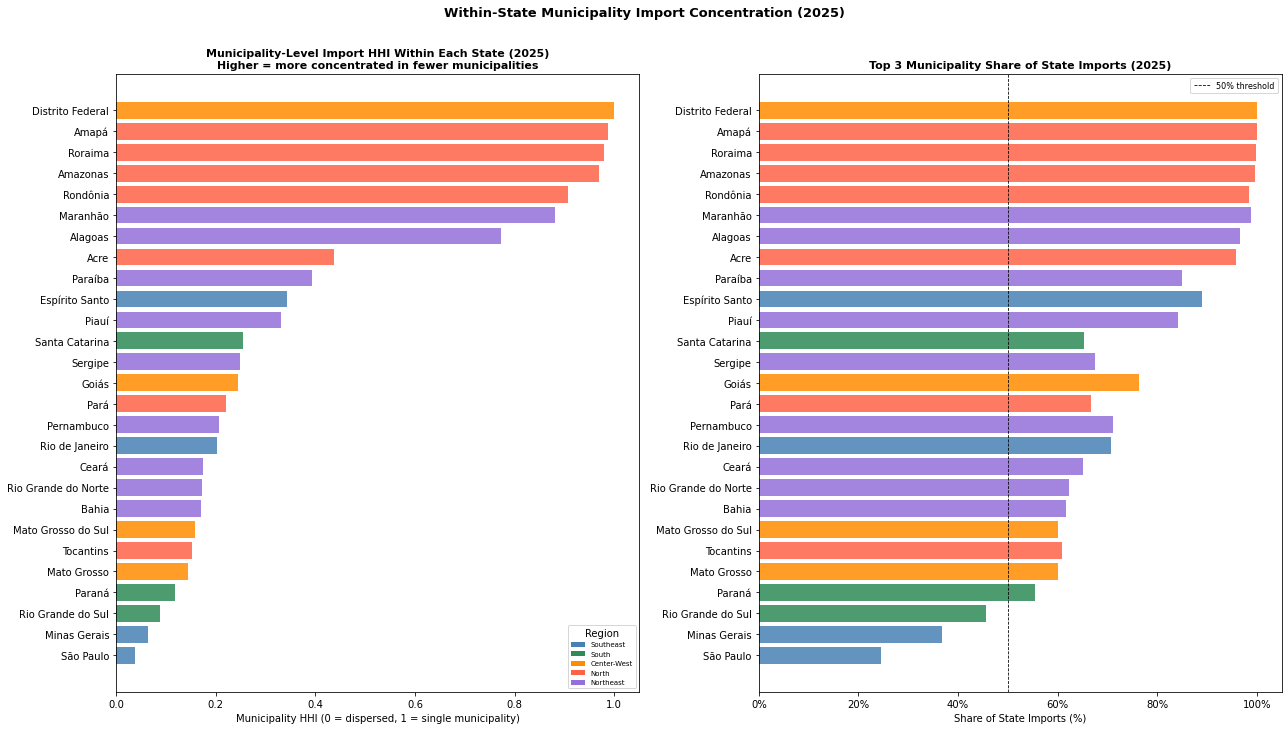

In [26]:
## ── Chart: within-state import HHI ranked — mirror of export concentration ───
df_imp_conc_plot = df_imp_conc.sort_values('hhi_imp', ascending=True)
bar_colors_imp = df_imp_conc_plot['region'].map(REGION_COLORS).fillna('lightgray')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

## Left: HHI
ax1.barh(df_imp_conc_plot['state'], df_imp_conc_plot['hhi_imp'],
         color=bar_colors_imp, alpha=0.85)
ax1.set_title(f'Municipality-Level Import HHI Within Each State ({MAX_YEAR})\n'
              f'Higher = more concentrated in fewer municipalities',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Municipality HHI (0 = dispersed, 1 = single municipality)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in REGION_COLORS.items()
                   if r != 'Undeclared']
ax1.legend(handles=legend_elements, title='Region', fontsize=7, loc='lower right')

## Right: Top 3 share
ax2.barh(df_imp_conc_plot['state'], df_imp_conc_plot['top3_imp_%'],
         color=bar_colors_imp, alpha=0.85)
ax2.axvline(x=50, color='black', linewidth=0.8, linestyle='--', label='50% threshold')
ax2.set_title(f'Top 3 Municipality Share of State Imports ({MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Share of State Imports (%)')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend(fontsize=8)

plt.suptitle(f'Within-State Municipality Import Concentration ({MAX_YEAR})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_3_8_2_within_state_imp_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview
The two panels confirm the same structural divide from different angles. Northern and Northeastern states sit at the high-concentration end of both charts — high HHI and top-3 share above 90% in most cases. Southern and Southeastern states sit at the low-concentration end — low HHI and top-3 share well below the 50% threshold line. The regional colour pattern is consistent across both panels with no material exceptions.

#### Business Relevance
The 50% threshold line on the right panel is the practical dividing line for market entry logistics. Every state above it — from Distrito Federal down to Pernambuco — can be covered by registering presence in three or fewer municipalities. Every state below it requires broader geographic coverage to reach the majority of registered import demand.

Two states sit close to the threshold and warrant attention. Rio de Janeiro (70.8%) sits just above it despite having 71 active import municipalities, meaning three municipalities deliver the majority of demand but a long tail exists. Bahia (61.7%) and Ceará (65.1%) are above the threshold but with lower HHI scores (0.170 and 0.174 respectively), indicating that the top-3 share is meaningful but no single municipality dominates — coverage requires three distinct commercial relationships, not one.

São Paulo and Minas Gerais are the only states where top-3 share falls below 40% — 24.6% and 36.7% respectively. These are the only two states in the dataset where a three-municipality strategy is structurally insufficient. For any supplier or distributor entering these markets, multi-city coverage is not optional.

The HHI panel reinforces a point relevant to risk assessment: high concentration is not only a market access simplifier — it is a single-point-of-failure risk. For states with HHI above 0.700, any disruption to the dominant municipality's import activity — regulatory, logistical or economic — affects the near-totality of the state's import base with no alternative distribution pathway.

---
---

## 3.9 — Trade Balance at Municipality Level
Combining municipality export and import data to identify net surplus and deficit municipalities — connecting to the state-level coverage ratio analysis in Section 2.14 and identifying whether state-level deficits are driven by specific municipalities or distributed across the state.

*Note: Municipality-level trade balance should be interpreted with caution — import registration municipality may reflect the customs point of entry rather than the end-use location, particularly for large port cities.*

### 3.9.1 — Municipality Trade Balance — Surplus and Deficit Summary
Merges municipality-level exports and imports on `mun_code` using an outer join — municipalities with only exports or only imports are retained with the missing side set to zero. The top 20 surplus and top 20 deficit municipalities are printed, showing raw export value, import value, and net balance. Note that import registration municipality reflects the customs point of entry, not necessarily the end-use location — deficit readings for port cities should be interpreted with this caveat.

In [27]:
## Merge municipality exports and imports
df_mun_balance = df_mun_exp[['mun_code', 'municipality', 'uf', 'state', 'region', 'exports_usd']].merge(
    df_mun_imp[['mun_code', 'imports_usd']],
    on='mun_code', how='outer'
).fillna(0)

df_mun_balance['exports_usd_bn'] = (df_mun_balance['exports_usd'] / 1e9).round(3)
df_mun_balance['imports_usd_bn'] = (df_mun_balance['imports_usd'] / 1e9).round(3)
df_mun_balance['balance_usd_bn'] = (
    (df_mun_balance['exports_usd'] - df_mun_balance['imports_usd']) / 1e9
).round(3)

## Top surplus and deficit municipalities
df_surplus = df_mun_balance.nlargest(20, 'balance_usd_bn')
df_deficit = df_mun_balance.nsmallest(20, 'balance_usd_bn')

print(f"\nTop 20 Surplus Municipalities ({MAX_YEAR})")
print(df_surplus[['municipality', 'uf', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']].to_string(index=False))
print(f"\nTop 20 Deficit Municipalities ({MAX_YEAR})")
print(df_deficit[['municipality', 'uf', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']].to_string(index=False))


Top 20 Surplus Municipalities (2025)
          municipality uf  exports_usd_bn  imports_usd_bn  balance_usd_bn
        RIO DE JANEIRO RJ          40.027           9.974          30.053
     CANAA DOS CARAJAS PA           6.555           0.100           6.456
           PARAUAPEBAS PA           5.277           0.249           5.029
             PARANAGUA PR           7.030           3.413           3.617
               ITAGUAI RJ           3.416           0.099           3.317
             RIO VERDE GO           3.417           0.151           3.265
                SANTOS SP           6.714           3.736           2.978
                MARABA PA           3.170           0.285           2.885
              VARGINHA MG           3.288           0.831           2.457
               SORRISO MT           2.666           0.240           2.426
                 ARAXA MG           2.537           0.142           2.395
               MARINGA PR           2.679           0.316           2.363


#### Overview
The surplus and deficit rankings separate Brazil's export production municipalities from its industrial import and consumption hubs. Surplus municipalities are concentrated in commodity extraction, agricultural processing and port registration. Deficit municipalities are concentrated in manufacturing, refining and commercial centres where import demand structurally exceeds registered export activity.

#### Business Relevance
The surplus list is dominated by two profiles. The first is mineral extraction — Canaã dos Carajás (\\$6.46bn), Parauapebas (\\$5.03bn), Marabá (\\$2.89bn) and Barcarena (\\$2.22bn) are all Pará municipalities tied to iron ore and aluminium operations. The second is agricultural processing — Sorriso (\\$2.43bn), Rio Verde (\\$3.27bn), Luís Eduardo Magalhães ($2.20bn) and Guaxupé (\\$2.33bn) reflect soy, corn and coffee export registrations in the Center-West and Minas Gerais interior. These municipalities generate large surpluses with minimal import activity — Guaxupé registers only \\$0.02bn in imports against \\$2.35bn in exports. They are not import markets.

Rio de Janeiro city (\\$30.05bn surplus) is the largest single surplus municipality in the dataset by a wide margin, driven by the oil and gas registration concentration identified in Steps 2 and 2c. Ilhabela (\\$1.88bn surplus, \\$0.00bn imports) is a secondary reflection of the same dynamic — offshore oil platform registrations with negligible import activity.

The deficit list identifies where import demand is structurally concentrated. Manaus (\\$-15.03bn) and Itajaí (\\$-10.19bn) lead by a significant margin, though for structurally different reasons — Manaus reflects the Zona Franca de Manaus consumer and industrial goods intake; Itajaí's composition remains unresolved pending Step 4. Paulínia (\\$-5.38bn) and Jundiaí (\\$-3.35bn) are industrial manufacturing deficits within São Paulo state. São José dos Pinhais (\\$-2.18bn) and Camaçari (\\$-2.15bn) reflect automotive and petrochemical input demand respectively.

Petrópolis (\\$-8.87bn) is the second largest deficit municipality in the dataset. With only \\$0.60bn in registered exports, the deficit is almost entirely import-driven. As established in Section 3.5.2, this reflects the registered address of importing companies whose goods enter through other points — the product composition driving this figure remains unidentified and is the highest-priority open item for Step 4.

Three municipalities appear on neither extreme but carry strategic relevance: Santos (\\$2.98bn surplus), Paranaguá (\\$3.62bn surplus) and São Luís (\\$-2.54bn deficit) all combine significant export and import registration activity, consistent with their dual function as both export dispatch and import intake hubs for their respective hinterlands.

---
---

### 3.9.2 — Municipality Trade Balance — Surplus and Deficit Chart
Side-by-side horizontal bar chart showing the top 20 surplus municipalities (left, blue) and top 20 deficit municipalities (right, red) by net trade balance — providing a visual complement to the printed summary in 3.9.1 and making the scale of individual municipality surpluses and deficits immediately readable.

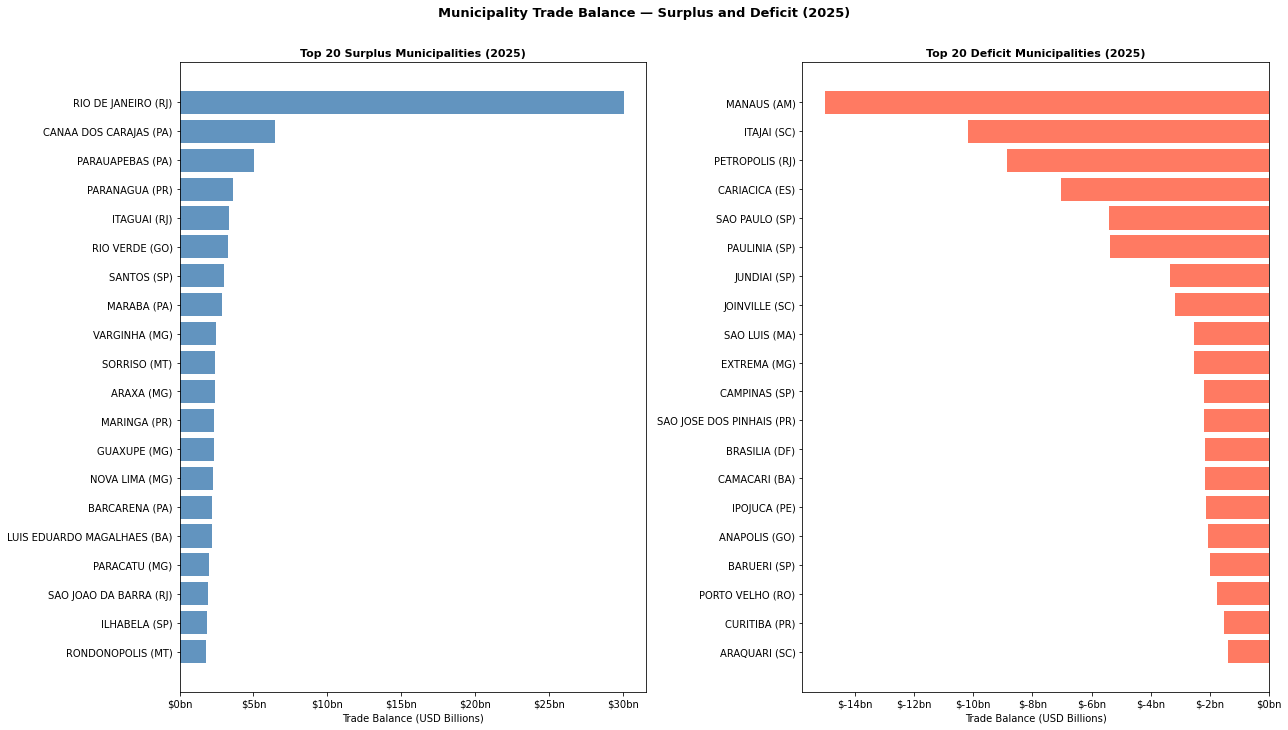

In [28]:
## ── Chart: surplus vs deficit municipalities ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

## Surplus
df_s = df_surplus.sort_values('balance_usd_bn', ascending=True)
ax1.barh(
    df_s['municipality'] + ' (' + df_s['uf'] + ')',
    df_s['balance_usd_bn'],
    color='steelblue', alpha=0.85
)
ax1.set_title(f'Top 20 Surplus Municipalities ({MAX_YEAR})', fontsize=11, fontweight='bold')
ax1.set_xlabel('Trade Balance (USD Billions)')
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

## Deficit
df_d = df_deficit.sort_values('balance_usd_bn', ascending=False)
ax2.barh(
    df_d['municipality'] + ' (' + df_d['uf'] + ')',
    df_d['balance_usd_bn'],
    color='tomato', alpha=0.85
)
ax2.set_title(f'Top 20 Deficit Municipalities ({MAX_YEAR})', fontsize=11, fontweight='bold')
ax2.set_xlabel('Trade Balance (USD Billions)')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

plt.suptitle(f'Municipality Trade Balance — Surplus and Deficit ({MAX_YEAR})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_3_9_2_mun_balance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Overview
The chart makes the scale asymmetry between the two lists immediately visible. Rio de Janeiro's \\$30.05bn surplus dwarfs every other municipality on the surplus side — the next closest, Canaã dos Carajás, is less than one quarter of its value. On the deficit side, Manaus (\\$-15.03bn) and Itajaí (\\$-10.19bn) stand apart from the remainder, with Petrópolis (\\$-8.87bn) and Cariacica ($-7.03bn) forming a secondary tier before the distribution compresses toward \\$-2bn.

#### Business Relevance
The visual separation between the two panels reflects a structural feature of Brazil's trade geography: surplus municipalities are few, large and commodity-driven; deficit municipalities are more numerous, more moderate in individual scale, and concentrated in manufacturing and consumption hubs.
The surplus panel is effectively a commodity extraction map. With the exception of Santos and Paranaguá — which combine export dispatch with import intake — every municipality in the top 20 surplus list generates its balance through a single dominant sector with negligible import demand. This has a direct implication for supplier strategy: these municipalities are not addressable import markets regardless of their trade value.

The deficit panel is the inverse — it is the closest approximation available in this dataset to a map of where import demand is registered. The 20 municipalities shown collectively represent the highest-concentration import demand locations in Brazil. For any company evaluating distribution entry points, the deficit panel identifies where the import base is registered, with the caveat that Itajaí and Petrópolis remain structurally uncharacterised pending Step 4.

The compression of the deficit distribution — most municipalities clustering between \\$-2bn and \\$-5bn once the top three are excluded — indicates that below the Manaus, Itajaí and Petrópolis tier, import demand at municipality level is relatively evenly distributed across industrial and commercial hubs. No single municipality outside those three represents a disproportionate share of the addressable deficit base.

---
---

### 3.9.3 — Import Deficit Municipalities Over Time: Is the Current Structure Persistent or Recent? (1997–2025)
Tracks the import deficit of the top 10 deficit municipalities from 2025 — including Manaus, Itajaí and Petrópolis — back to 1997, showing whether the current deficit concentration is a long-standing structural feature or has emerged recently. Municipalities whose deficits have grown continuously are distinguished from those where deficits are recent or cyclical. Directly relevant to the Santa Catarina and Espírito Santo open investigations and to any market entry strategy that relies on import deficit as a proxy for addressable demand.

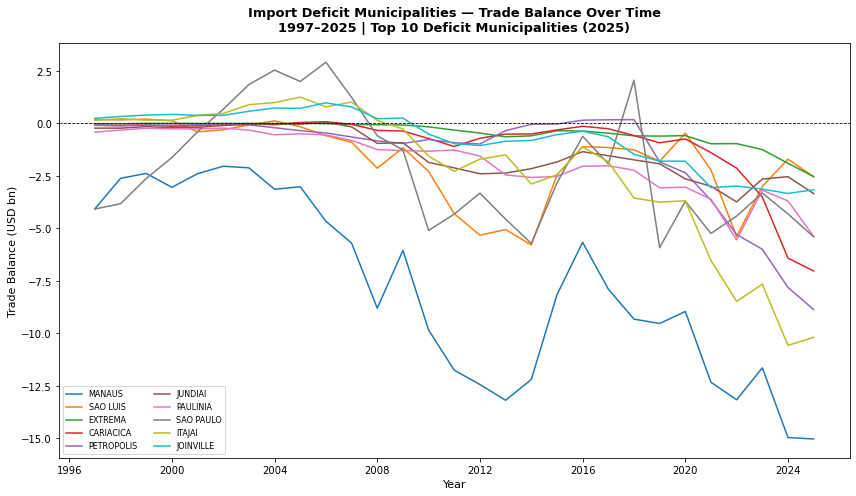

Municipality,UF,Exports (USD bn),Imports (USD bn),Balance (USD bn)
MANAUS,AM,$0.79bn,$15.83bn,$-15.03bn
ITAJAI,SC,$6.12bn,$16.31bn,$-10.19bn
PETROPOLIS,RJ,$0.60bn,$9.47bn,$-8.87bn
CARIACICA,ES,$0.14bn,$7.17bn,$-7.03bn
SAO PAULO,SP,$5.36bn,$10.77bn,$-5.41bn
PAULINIA,SP,$0.84bn,$6.23bn,$-5.38bn
JUNDIAI,SP,$0.95bn,$4.30bn,$-3.35bn
JOINVILLE,SC,$1.30bn,$4.46bn,$-3.16bn
SAO LUIS,MA,$1.92bn,$4.46bn,$-2.54bn
EXTREMA,MG,$0.08bn,$2.62bn,$-2.54bn


In [29]:
## ── Identify top 10 deficit municipalities from 2025 ─────────────────────────
query_deficit_2025 = f"""
    SELECT e."CO_MUN"             AS mun_code,
           m.nome_municipio        AS municipality,
           e."SG_UF_MUN"          AS uf,
           SUM(e."VL_FOB")        AS exports_usd
    FROM exp_mun e
    JOIN uf_mun m ON e."CO_MUN"    = m.codigo_municipio
    JOIN uf u     ON e."SG_UF_MUN" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA','CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA','REEXPORTACAO'
    )
    GROUP BY e."CO_MUN", m.nome_municipio, e."SG_UF_MUN"
"""

query_imp_2025 = f"""
    SELECT i."CO_MUN"             AS mun_code,
           SUM(i."VL_FOB")        AS imports_usd
    FROM imp_mun i
    JOIN uf u ON i."SG_UF_MUN" = u.sigla
    WHERE i."CO_ANO" = {MAX_YEAR}
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA','CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA','REEXPORTACAO'
    )
    GROUP BY i."CO_MUN"
"""

df_exp_2025 = pd.read_sql(query_deficit_2025, engine)
df_imp_2025 = pd.read_sql(query_imp_2025, engine)
df_bal_2025 = df_exp_2025.merge(df_imp_2025, on='mun_code', how='outer').fillna(0)
df_bal_2025['balance'] = df_bal_2025['exports_usd'] - df_bal_2025['imports_usd']

top10_deficit_codes = (
    df_bal_2025.nsmallest(10, 'balance')['mun_code'].tolist()
)
top10_deficit_names = (
    df_bal_2025[df_bal_2025['mun_code'].isin(top10_deficit_codes)]
    .set_index('mun_code')['municipality'].to_dict()
)

## ── Query time series for those municipalities ────────────────────────────────
mun_codes_sql = ', '.join(str(c) for c in top10_deficit_codes)

query_ts_exp = f"""
    SELECT e."CO_ANO" AS year, e."CO_MUN" AS mun_code,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp_mun e
    WHERE e."CO_ANO" BETWEEN 1997 AND {MAX_YEAR}
    AND e."CO_MUN" IN ({mun_codes_sql})
    GROUP BY e."CO_ANO", e."CO_MUN"
"""

query_ts_imp = f"""
    SELECT i."CO_ANO" AS year, i."CO_MUN" AS mun_code,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp_mun i
    WHERE i."CO_ANO" BETWEEN 1997 AND {MAX_YEAR}
    AND i."CO_MUN" IN ({mun_codes_sql})
    GROUP BY i."CO_ANO", i."CO_MUN"
"""

df_ts_exp = pd.read_sql(query_ts_exp, engine)
df_ts_imp = pd.read_sql(query_ts_imp, engine)
df_ts = df_ts_exp.merge(df_ts_imp, on=['year', 'mun_code'], how='outer').fillna(0)
df_ts['balance'] = df_ts['exports_usd'] - df_ts['imports_usd']
df_ts['municipality'] = df_ts['mun_code'].map(top10_deficit_names)

## ── Chart ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

for mun_code, grp in df_ts.groupby('mun_code'):
    grp = grp.sort_values('year')
    label = top10_deficit_names.get(mun_code, str(mun_code))
    ax.plot(grp['year'], grp['balance'] / 1e9, linewidth=1.5, label=label)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Trade Balance (USD bn)', fontsize=11)
ax.set_title(
    'Import Deficit Municipalities — Trade Balance Over Time\n'
    '1997–2025 | Top 10 Deficit Municipalities (2025)',
    fontsize=13, fontweight='bold', pad=12
)
ax.legend(fontsize=8, loc='lower left', ncol=2)
ax.xaxis.set_major_locator(mticker.MultipleLocator(4))
plt.tight_layout()
plt.show()

## ── Styled table — 2025 snapshot with context ────────────────────────────────
df_deficit_display = (
    df_bal_2025[df_bal_2025['mun_code'].isin(top10_deficit_codes)]
    .sort_values('balance')
    .copy()
)
df_deficit_display['exports_usd_bn'] = df_deficit_display['exports_usd'] / 1e9
df_deficit_display['imports_usd_bn'] = df_deficit_display['imports_usd'] / 1e9
df_deficit_display['balance_bn']     = df_deficit_display['balance'] / 1e9

display(
    df_deficit_display[['municipality', 'uf',
                         'exports_usd_bn', 'imports_usd_bn', 'balance_bn']]
    .rename(columns={
        'municipality'    : 'Municipality',
        'uf'              : 'UF',
        'exports_usd_bn'  : 'Exports (USD bn)',
        'imports_usd_bn'  : 'Imports (USD bn)',
        'balance_bn'      : 'Balance (USD bn)',
    })
    .style
    .format({
        'Exports (USD bn)': '${:.2f}bn',
        'Imports (USD bn)': '${:.2f}bn',
        'Balance (USD bn)': '${:+.2f}bn',
    })
    .set_caption('Top 10 Deficit Municipalities — 2025 Snapshot')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

#### Overview
The time series separates the top 10 deficit municipalities into three structurally distinct groups. Manaus has carried a persistent and deepening deficit since 1997, reaching \\$-15.03bn by 2025 — the largest single-municipality deficit in the dataset and the only one that has been consistently dominant across the entire period. Itajaí and Petrópolis emerge as significant deficit municipalities only from approximately 2010 onwards, with their deficits accelerating sharply post-2015. The remaining seven municipalities cluster near zero for most of the period before diverging downward in the 2015–2025 window.

#### Business Relevance
Manaus is the only municipality where the deficit is structural across the full 28-year period. Its trajectory — a deficit of approximately \\$-2.5bn in 1997 growing to \\$-15.03bn by 2025 — reflects the continuous expansion of the Zona Franca de Manaus import base rather than a recent shift. For any supplier evaluating Manaus as a target market, the deficit is not a cyclical opportunity — it is the permanent operating condition of that market.

Itajaí's deficit is a recent and accelerating phenomenon. The chart shows near-zero balance through approximately 2010, followed by a sharp and sustained decline to \\$-10.19bn by 2025. This trajectory is inconsistent with a long-established industrial import base and strengthens the case that the deficit reflects a structural change in registration or logistics activity rather than organic demand growth. This is the most important observation in the chart for the Step 4 investigation — the timing of Itajaí's deficit emergence is a diagnostic data point that NCM-level analysis should be able to explain.

Petrópolis follows a similar post-2010 emergence pattern, reaching \\$-8.87bn by 2025 from a position close to balance before 2012. As with Itajaí, the pace and timing of this deterioration requires product-level explanation before the figure can be used analytically.

Cariacica, São Paulo city, Paulínia, Jundiaí, Joinville, São Luís and Extrema all show deficits that materialise primarily in the 2015–2025 window, with values converging in the \\$-2.5bn to \\$-7.0bn range by 2025. The convergence of multiple municipalities into similar deficit levels in this period is consistent with the post-2015 structural shift identified in the regression analysis in Step 2c — a parallel that warrants explicit cross-referencing when Step 3 findings are written up.

*⚠️ Itajaí's deficit emergence post-2010 and Petrópolis' post-2012 are the two most analytically significant observations in this chart. Both require NCM-level decomposition in Step 4 to determine whether the deficit growth reflects genuine demand expansion, registration consolidation, or a change in how imports are classified at those locations.*

---
---

## 3.10 — Active exporting and importing municipalities — 1997 vs 2025

Between 1997 and 2025, the number of municipalities with registered export activity grew from 1,438 to 2,488 — a 73.0% increase. Import participation grew from 1,664 to 2,487 — a 49.5% increase. The headline count growth raises two questions that the raw numbers cannot answer: whether new entrants contribute meaningfully to trade value or constitute a low-value long tail, and whether participation growth is distributed across all regions or concentrated in specific states — particularly the Center-West agricultural expansion frontier.

In [30]:
## Active exporting and importing municipalities — 1997 vs 2025
query_mun_count = """
    SELECT
        'Exports' AS trade_type,
        SUM(CASE WHEN "CO_ANO" = 1997 THEN 1 ELSE 0 END) AS count_1997,
        SUM(CASE WHEN "CO_ANO" = 2025 THEN 1 ELSE 0 END) AS count_2025
    FROM (
        SELECT DISTINCT "CO_MUN", "CO_ANO"
        FROM exp_mun
        WHERE "CO_ANO" IN (1997, 2025)
    ) e
    UNION ALL
    SELECT
        'Imports' AS trade_type,
        SUM(CASE WHEN "CO_ANO" = 1997 THEN 1 ELSE 0 END) AS count_1997,
        SUM(CASE WHEN "CO_ANO" = 2025 THEN 1 ELSE 0 END) AS count_2025
    FROM (
        SELECT DISTINCT "CO_MUN", "CO_ANO"
        FROM imp_mun
        WHERE "CO_ANO" IN (1997, 2025)
    ) i
"""
df_mun_count = pd.read_sql(query_mun_count, engine)
df_mun_count['change'] = df_mun_count['count_2025'] - df_mun_count['count_1997']
df_mun_count['pct_change'] = ((df_mun_count['count_2025'] / df_mun_count['count_1997'] - 1) * 100).round(1)
print(df_mun_count.to_string(index=False))

trade_type  count_1997  count_2025  change  pct_change
   Exports        1438        2488    1050        73.0
   Imports        1664        2487     823        49.5


### 3.10.1 — Value Tier Distribution of Exporting Municipalities: 1997 vs 2025
Classifing all exporting municipalities in 1997 and 2025 into three value tiers — the municipalities accounting for the top 80% of national export value, the next 15%, and the bottom 5% — to determine whether the 1,050 new municipal entrants since 1997 are meaningful contributors to national export value or a long tail of negligible volume. 
The result qualifies if the top-tier municipality count has grown modestly while the long tail has expanded significantly, concentration has deepened despite broader participation.

In [31]:
## Query export value by municipality for 1997 and 2025
query_tier = f"""
    SELECT e."CO_ANO"           AS year,
           e."CO_MUN"           AS mun_code,
           SUM(e."VL_FOB")      AS exports_usd
    FROM exp_mun e
    JOIN uf u ON e."SG_UF_MUN" = u.sigla
    WHERE e."CO_ANO" IN (1997, {MAX_YEAR})
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
    GROUP BY e."CO_ANO", e."CO_MUN"
    ORDER BY e."CO_ANO", exports_usd DESC
"""

df_tier = pd.read_sql(query_tier, engine)

## Compute cumulative value share within each year and assign tiers
results = []
for year, grp in df_tier.groupby('year'):
    grp = grp.sort_values('exports_usd', ascending=False).copy()
    total = grp['exports_usd'].sum()
    grp['cum_share'] = grp['exports_usd'].cumsum() / total

    tier_80  = (grp['cum_share'] <= 0.80).sum()
    tier_95  = ((grp['cum_share'] > 0.80) & (grp['cum_share'] <= 0.95)).sum()
    tier_100 = (grp['cum_share'] > 0.95).sum()
    total_mun = len(grp)

    results.append({
        'Year'                        : year,
        'Total Municipalities'        : total_mun,
        'Top tier — 80% of value'     : tier_80,
        'Mid tier — next 15% of value': tier_95,
        'Long tail — bottom 5%'       : tier_100,
        'Top tier share of total mun' : f"{tier_80 / total_mun * 100:.1f}%",
    })

df_tiers = pd.DataFrame(results)

print("Export Municipality Value Tier Distribution — 1997 vs 2025")
print(df_tiers.to_string(index=False))

display(
    df_tiers.style
    .set_caption('Export Municipality Value Tier Distribution — 1997 vs 2025')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption',
         'props'   : [('font-size', '13px'), ('font-weight', 'bold'),
                      ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props'   : [('background-color', '#2c3e50'), ('color', 'white'),
                      ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th:not(:first-child)',
         'props'   : [('text-align', 'center')]},
        {'selector': 'td:not(:first-child)',
         'props'   : [('text-align', 'center')]},
        {'selector': 'tr:nth-child(even)',
         'props'   : [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

Export Municipality Value Tier Distribution — 1997 vs 2025
 Year  Total Municipalities  Top tier — 80% of value  Mid tier — next 15% of value  Long tail — bottom 5% Top tier share of total mun
 1997                  1437                      118                           233                   1086                        8.2%
 2025                  2486                      217                           371                   1898                        8.7%


Year,Total Municipalities,Top tier — 80% of value,Mid tier — next 15% of value,Long tail — bottom 5%,Top tier share of total mun
1997,1437,118,233,1086,8.2%
2025,2486,217,371,1898,8.7%


#### Overview
Between 1997 and 2025 the number of exporting municipalities grew by 1,049 — from 1,437 to 2,486. The tier distribution shows that this growth was concentrated in the long tail. The bottom 5% of export value grew from 1,086 to 1,898 municipalities — an addition of 812 low-value entrants. The top tier, which accounts for 80% of national export value, grew from 118 to 217 municipalities.

#### Business Relevance
The top-tier share of total municipalities has remained virtually unchanged — 8.2% in 1997 and 8.7% in 2025. Despite the participation base nearly doubling, the proportion of municipalities that matter for 80% of national export value has held constant. Concentration has not meaningfully loosened over 28 years.

The practical implication is direct: in 2025, 217 municipalities account for 80% of Brazil's registered export value. The remaining 2,269 — 91.3% of all active exporting municipalities — collectively account for the remaining 20%. For any supplier, logistics operator or trade finance provider targeting export-linked demand, the addressable market is structurally defined by those 217 municipalities, not by the 2,486 headline participation figure.

The mid tier grew from 233 to 371 municipalities — an addition of 138 locations contributing the next 15% of value. This is the segment where meaningful but non-dominant export activity resides, and its growth indicates that Brazil's export base has broadened modestly in the middle. The long tail expansion from 1,086 to 1,898 reflects the agricultural frontier opening new registration locations with individually negligible trade volumes — consistent with the Center-West participation growth expected in 3.10.2.

---
---

### 3.10.2 — State-Level Participation Growth: Where Did New Municipalities Come From?
Disaggregates the national participation growth figure by state to identify which states drove the expansion between 1997 and 2025. The central question is whether new exporting municipalities are concentrated in the Center-West agricultural frontier states — consistent with the soy and corn expansion documented at state level in Step 2 — or distributed across all regions. A geographically concentrated growth pattern would indicate that participation expansion is a sectoral and regional phenomenon rather than a broad structural deepening of Brazil's export base.

Export Municipality Participation Growth by State — 1997 vs 2025
              state      region  count_1997  count_2025  change  pct_change
       Minas Gerais   Southeast         177         361     184       104.0
          São Paulo   Southeast         293         455     162        55.3
  Rio Grande do Sul       South         191         278      87        45.5
             Paraná       South         149         234      85        57.0
              Bahia   Northeast          77         151      74        96.1
     Santa Catarina       South         142         215      73        51.4
        Mato Grosso Center-West          35          86      51       145.7
              Goiás Center-West          37          85      48       129.7
Rio Grande do Norte   Northeast          13          47      34       261.5
              Ceará   Northeast          34          64      30        88.2
     Espírito Santo   Southeast          30          59      29        96.7
          Tocantins    

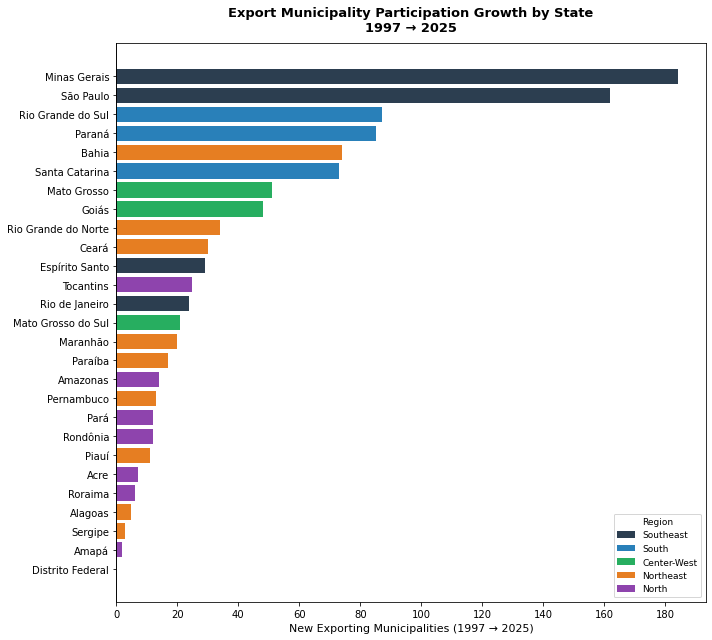

State,Region,1997,2025,New Municipalities,Growth (%)
Minas Gerais,Southeast,177,361,184,104.000000
São Paulo,Southeast,293,455,162,55.300000
Rio Grande do Sul,South,191,278,87,45.500000
Paraná,South,149,234,85,57.000000
Bahia,Northeast,77,151,74,96.100000
Santa Catarina,South,142,215,73,51.400000
Mato Grosso,Center-West,35,86,51,145.700000
Goiás,Center-West,37,85,48,129.700000
Rio Grande do Norte,Northeast,13,47,34,261.500000
Ceará,Northeast,34,64,30,88.200000


In [32]:
## Query municipality count by state for 1997 and 2025 — exports and imports
query_state_growth = f"""
    SELECT e."CO_ANO"            AS year,
           u.nome_estado          AS state,
           u.nome_regiao          AS region,
           COUNT(DISTINCT e."CO_MUN") AS mun_count
    FROM exp_mun e
    JOIN uf u ON e."SG_UF_MUN" = u.sigla
    WHERE e."CO_ANO" IN (1997, {MAX_YEAR})
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
    GROUP BY e."CO_ANO", u.nome_estado, u.nome_regiao
    ORDER BY u.nome_estado, e."CO_ANO"
"""

df_sg = pd.read_sql(query_state_growth, engine)
df_sg['region'] = df_sg['region'].map(region_name_map).fillna(df_sg['region'])

## Pivot to wide format and compute change
df_sg_wide = df_sg.pivot(index=['state', 'region'], columns='year', values='mun_count').reset_index()
df_sg_wide.columns.name = None
df_sg_wide = df_sg_wide.rename(columns={1997: 'count_1997', MAX_YEAR: 'count_2025'})
df_sg_wide['change']     = df_sg_wide['count_2025'] - df_sg_wide['count_1997']
df_sg_wide['pct_change'] = (df_sg_wide['change'] / df_sg_wide['count_1997'] * 100).round(1)
df_sg_wide = df_sg_wide.sort_values('change', ascending=False)

print("Export Municipality Participation Growth by State — 1997 vs 2025")
print(df_sg_wide.to_string(index=False))

## Chart — horizontal bar, change in municipality count, coloured by region
region_colors = {
    'Southeast'  : '#2c3e50',
    'South'      : '#2980b9',
    'Center-West': '#27ae60',
    'Northeast'  : '#e67e22',
    'North'      : '#8e44ad',
}

fig, ax = plt.subplots(figsize=(10, 9))

colors = df_sg_wide['region'].map(region_colors)

ax.barh(df_sg_wide['state'], df_sg_wide['change'], color=colors, edgecolor='none')

ax.set_xlabel('New Exporting Municipalities (1997 → 2025)', fontsize=11)
ax.set_title('Export Municipality Participation Growth by State\n1997 → 2025',
             fontsize=13, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)

## Region legend
legend_handles = [
    Patch(facecolor=c, label=r) for r, c in region_colors.items()
]
ax.legend(handles=legend_handles, title='Region', fontsize=9,
          title_fontsize=9, loc='lower right')

ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## Styled table output
display(
    df_sg_wide[['state', 'region', 'count_1997', 'count_2025', 'change', 'pct_change']]
    .rename(columns={
        'state'      : 'State',
        'region'     : 'Region',
        'count_1997' : '1997',
        'count_2025' : '2025',
        'change'     : 'New Municipalities',
        'pct_change' : 'Growth (%)',
    })
    .style
    .set_caption('Export Municipality Participation Growth by State — 1997 vs 2025')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption',
         'props'   : [('font-size', '13px'), ('font-weight', 'bold'),
                      ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props'   : [('background-color', '#2c3e50'), ('color', 'white'),
                      ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th:not(:first-child)',
         'props'   : [('text-align', 'center')]},
        {'selector': 'td:not(:first-child)',
         'props'   : [('text-align', 'center')]},
        {'selector': 'tr:nth-child(even)',
         'props'   : [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

#### Overview
Participation growth between 1997 and 2025 is not evenly distributed across Brazil. The absolute growth leaders are Southeast and South states — Minas Gerais (+184), São Paulo (+162), Rio Grande do Sul (+87) and Paraná (+85) — reflecting the depth of their existing industrial and agricultural bases. The highest percentage growth is concentrated in smaller Northern and Northeastern states starting from low bases — Tocantins (+357%), Acre (+350%), Maranhão (+286%) and Amazonas (+280%) — where even modest absolute additions produce large percentage changes.

#### Business Relevance
The chart separates two structurally different types of participation growth. The first is depth expansion — large states adding municipalities to an already broad base. Minas Gerais grew from 177 to 361 active exporting municipalities, São Paulo from 293 to 455. These additions represent genuine broadening of an established industrial and agricultural export base across a large territory.

The second is frontier activation. Mato Grosso (+145.7%, from 35 to 86) and Goiás (+129.7%, from 37 to 85) show the Center-West agricultural expansion in municipal registration terms — new soy, corn and cotton producing locations entering the export registry as the Cerrado frontier extended westward. This is consistent with the commodity long-tail finding in 3.10.1: the new entrants are predominantly agricultural municipalities contributing individually small volumes to a concentrated national export base.

The North and Northeast percentage growth figures — while visually striking — translate to small absolute additions from low starting points. Tocantins grew by 25 municipalities; Maranhão by 20; Amazonas by 14. These states remain peripheral in terms of export municipality count and, by extension, in terms of the addressable export-linked commercial base they represent.

Distrito Federal is the only state with zero growth — one active exporting municipality in both 1997 and 2025 — consistent with its function as a federal administrative centre with no meaningful industrial or agricultural export base.

The combined reading of 3.10.1 and 3.10.2 produces a single conclusion: Brazil's export participation has broadened significantly in count terms, but the value structure has not changed. The top tier — 8.2% of municipalities in 1997, 8.7% in 2025 — still accounts for 80% of national export value. The new entrants are predominantly low-value agricultural frontier municipalities in the Center-West and long-tail industrial locations in the Southeast. The commercial geography of Brazilian exports in 2025 is more populated but not more distributed than it was in 1997.

---
---

## 3.11 — Santa Catarina Deep-Dive: Port Cities and the \\$21.80bn Import Deficit
Santa Catarina carries the largest import deficit of any Brazilian state at \\$21.80bn — flagged as an open investigation in Section 2.1.2. This section tests the gateway/transshipment hypothesis: if the deficit is driven by 1–2 port municipalities (Itajaí, Navegantes, São Francisco do Sul), it suggests customs registration rather than end-use consumption. If distributed across many municipalities, it points to structural industrial import dependency.

### 3.11.1 — Santa Catarina Municipality Export and Import Breakdown
Full municipality-level export and import rankings for Santa Catarina — identifying which cities account for the state's export base and which drive the import deficit, and whether the same municipalities appear on both sides.

In [33]:
## ── Santa Catarina municipality deep-dive ────────────────────────────────────
SC_STATE = 'Santa Catarina'

sc_exp = (
    df_mun_state[df_mun_state['state'] == SC_STATE]
    .sort_values('exports_usd', ascending=False)
    .copy()
)
sc_imp = (
    df_mun_imp[df_mun_imp['state'] == SC_STATE]
    .sort_values('imports_usd', ascending=False)
    .copy()
)

sc_exp_total = sc_exp['exports_usd'].sum()
sc_imp_total = sc_imp['imports_usd'].sum()
sc_balance   = (sc_exp_total - sc_imp_total) / 1e9

print(f"Santa Catarina — Trade Overview ({MAX_YEAR})")
print(f"  Exports : ${sc_exp_total/1e9:.2f}bn")
print(f"  Imports : ${sc_imp_total/1e9:.2f}bn")
print(f"  Balance : ${sc_balance:.2f}bn")
print(f"  Active export municipalities : {len(sc_exp):,}")
print(f"  Active import municipalities : {len(sc_imp):,}")

## Export breakdown
sc_exp['share_%']      = (sc_exp['exports_usd'] / sc_exp_total * 100).round(1)
sc_exp['cumulative_%'] = sc_exp['share_%'].cumsum().round(1)
sc_exp['exports_usd_bn'] = sc_exp['exports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
sc_exp['share_%']        = sc_exp['share_%'].apply(lambda x: f'{x:.1f}%')
sc_exp['cumulative_%']   = sc_exp['cumulative_%'].apply(lambda x: f'{x:.1f}%')

print(f"\nTop 15 Export Municipalities — Santa Catarina ({MAX_YEAR})")
display(
    sc_exp.head(15)[['municipality', 'exports_usd_bn', 'share_%', 'cumulative_%']]
    .rename(columns={
        'municipality'   : 'Municipality',
        'exports_usd_bn' : 'Exports (USD bn)',
        'share_%'        : 'Share of State (%)',
        'cumulative_%'   : 'Cumulative (%)',
    })
    .style
    .set_caption('Santa Catarina — Top 15 Export Municipalities (2025)')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

## Import breakdown
sc_imp['share_%']      = (sc_imp['imports_usd'] / sc_imp_total * 100).round(1)
sc_imp['cumulative_%'] = sc_imp['share_%'].cumsum().round(1)
sc_imp['imports_usd_bn'] = sc_imp['imports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
sc_imp['share_%']        = sc_imp['share_%'].apply(lambda x: f'{x:.1f}%')
sc_imp['cumulative_%']   = sc_imp['cumulative_%'].apply(lambda x: f'{x:.1f}%')

print(f"\nTop 15 Import Municipalities — Santa Catarina ({MAX_YEAR})")
display(
    sc_imp.head(15)[['municipality', 'imports_usd_bn', 'share_%', 'cumulative_%']]
    .rename(columns={
        'municipality'   : 'Municipality',
        'imports_usd_bn' : 'Imports (USD bn)',
        'share_%'        : 'Share of State (%)',
        'cumulative_%'   : 'Cumulative (%)',
    })
    .style
    .set_caption('Santa Catarina — Top 15 Import Municipalities (2025)')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

Santa Catarina — Trade Overview (2025)
  Exports : $14.95bn
  Imports : $33.99bn
  Balance : $-19.04bn
  Active export municipalities : 215
  Active import municipalities : 212

Top 15 Export Municipalities — Santa Catarina (2025)


Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
ITAJAI,$6.12bn,41.0%,41.0%
JOINVILLE,$1.30bn,8.7%,49.7%
SAO FRANCISCO DO SUL,$1.10bn,7.4%,57.1%
JARAGUA DO SUL,$0.98bn,6.5%,63.6%
BLUMENAU,$0.36bn,2.4%,66.0%
CACADOR,$0.34bn,2.3%,68.3%
LAGES,$0.32bn,2.1%,70.4%
CHAPECO,$0.22bn,1.5%,71.9%
TRES BARRAS,$0.17bn,1.1%,73.0%
RIO DO SUL,$0.15bn,1.0%,74.0%



Top 15 Import Municipalities — Santa Catarina (2025)


Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
ITAJAI,$16.31bn,48.0%,48.0%
JOINVILLE,$4.46bn,13.1%,61.1%
ARAQUARI,$1.44bn,4.2%,65.3%
SAO FRANCISCO DO SUL,$1.16bn,3.4%,68.7%
SAO JOSE,$0.98bn,2.9%,71.6%
NAVEGANTES,$0.97bn,2.9%,74.5%
BLUMENAU,$0.90bn,2.7%,77.2%
FLORIANOPOLIS,$0.83bn,2.4%,79.6%
PALHOCA,$0.78bn,2.3%,81.9%
JARAGUA DO SUL,$0.61bn,1.8%,83.7%


#### Overview
Santa Catarina's 2025 trade balance stands at \\$-19.04bn. Exports total \\$14.95bn across 215 active municipalities; imports total \\$33.99bn across 212. The top 15 export municipalities account for 78.6% of state export value; the top 15 import municipalities account for 89.2% of state import value — indicating that the import base is more concentrated in its upper tier than the export base.

#### Analysis
Itajaí dominates both sides of the ledger but asymmetrically. It accounts for 41.0% of state exports (\\$6.12bn) and 48.0% of state imports (\\$16.31bn), producing a single-municipality deficit of $-10.19bn. No other municipality approaches this scale on either side. The asymmetry — Itajaí imports at 2.7x its export value — is the central unresolved question for Step 4. Whether this reflects domestic industrial demand, customs registration of goods transiting to other states, or re-export activity cannot be determined from registration data alone.

Beyond Itajaí, the export and import lists share four municipalities in their respective top 15: Joinville, São Francisco do Sul, Jaraguá do Sul and Blumenau. All four run import deficits — Joinville at \\$-3.16bn is the largest. These are Santa Catarina's established industrial municipalities and their deficits are consistent with manufacturing input demand. Jaraguá do Sul (\\$0.98bn exports, $0.61bn imports) is the only municipality in the overlap that approaches balance.

The import list introduces eight municipalities absent from the export top 15 — Araquari, São José, Navegantes, Florianópolis, Palhoça, Criciúma, Brusque and Garuva. Of these, Araquari (\\$1.44bn) and Navegantes (\\$0.97bn) are port-adjacent and their import registrations may reflect logistics and customs activity rather than end-use demand. The remaining six are commercial and industrial municipalities whose registrations are more likely to reflect genuine consumption and production input demand.

*⚠️ Itajaí's \\$-10.19bn single-municipality deficit and Araquari's \\$1.44bn import registration without a corresponding export base are the two figures requiring NCM-level decomposition in Step 4. Until the product composition of Itajaí's $16.31bn import base is confirmed, the gateway versus industrial demand question remains open.*

---
---

### 3.11.2 — Overlap: Do Santa Catarina's Export and Import Municipalities Coincide?
Identifying which municipalities appear in both the top export and top import rankings for Santa Catarina — a direct test of whether the same industrial clusters drive both sides of the state's trade ledger, or whether export and import activity are geographically separated.

In [37]:
## ── SC export/import overlap ──────────────────────────────────────────────────
sc_exp_raw = df_mun_state[df_mun_state['state'] == SC_STATE].sort_values(
    'exports_usd', ascending=False
).head(15)
sc_imp_raw_top = df_mun_imp[df_mun_imp['state'] == SC_STATE].sort_values(
    'imports_usd', ascending=False
).head(15)

sc_overlap_muns = set(sc_exp_raw['mun_code']) & set(sc_imp_raw_top['mun_code'])

sc_overlap = sc_exp_raw[sc_exp_raw['mun_code'].isin(sc_overlap_muns)][
    ['municipality', 'exports_usd']
].merge(
    sc_imp_raw_top[sc_imp_raw_top['mun_code'].isin(sc_overlap_muns)][
        ['municipality', 'imports_usd']
    ],
    on='municipality'
).copy()

sc_overlap['balance']          = sc_overlap['exports_usd'] - sc_overlap['imports_usd']
sc_overlap['Exports (USD bn)'] = sc_overlap['exports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
sc_overlap['Imports (USD bn)'] = sc_overlap['imports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
sc_overlap['Balance (USD bn)'] = sc_overlap['balance'].apply(lambda x: f'${x/1e9:+.2f}bn')

print(f"Santa Catarina — Municipalities in Both Top 15 Export and Import Rankings ({MAX_YEAR})")
print(f"Total overlapping municipalities: {len(sc_overlap)}")
display(
    sc_overlap[['municipality', 'Exports (USD bn)', 'Imports (USD bn)', 'Balance (USD bn)']]
    .rename(columns={'municipality': 'Municipality'})
    .style
    .set_caption('Santa Catarina — Export/Import Overlap Municipalities (2025)')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

Santa Catarina — Municipalities in Both Top 15 Export and Import Rankings (2025)
Total overlapping municipalities: 6


Municipality,Exports (USD bn),Imports (USD bn),Balance (USD bn)
ITAJAI,$6.12bn,$16.31bn,$-10.19bn
JOINVILLE,$1.30bn,$4.46bn,$-3.16bn
SAO FRANCISCO DO SUL,$1.10bn,$1.16bn,$-0.06bn
JARAGUA DO SUL,$0.98bn,$0.61bn,$+0.36bn
BLUMENAU,$0.36bn,$0.90bn,$-0.54bn
IMBITUBA,$0.14bn,$0.33bn,$-0.19bn


#### Overview
Six municipalities appear in both the top 15 export and top 15 import rankings for Santa Catarina. Together they account for the dominant share of the state's registered trade activity on both sides. Five of the six run import deficits; one — Jaraguá do Sul — runs a modest surplus.

#### Analysis
The overlap confirms that Santa Catarina's trade activity, both inbound and outbound, is anchored in the same set of municipalities. This is not a state where exports and imports are geographically separated — the same industrial and port-adjacent locations drive both sides of the ledger.

Itajaí and Joinville together account for \\$7.42bn in exports and \\$20.77bn in imports — the two municipalities alone are responsible for the structural shape of the state's deficit. Itajaí's \\$-10.19bn and Joinville's \\$-3.16bn are not offset by any other municipality in the overlap list. São Francisco do Sul is the closest to balance at \\$-0.06bn, consistent with a port registration location where export and import flows are matched in scale. Jaraguá do Sul is the only municipality running a surplus (\\$+0.36bn), indicating a net export orientation within the overlap group.

Blumenau (\\$-0.54bn) and Imbituba (\\$-0.19bn) contribute smaller deficits. Both are industrial and port-adjacent respectively, and their deficits are consistent with manufacturing input demand and logistics registration rather than transshipment activity — though NCM-level confirmation remains outstanding.

The state's \\$-19.04bn deficit is not distributed across 200+ municipalities — it is concentrated in six locations, with two municipalities (Itajaí and Joinville) accounting for \\$-13.35bn of it. The transshipment versus industrial demand question therefore reduces to a question about those two municipalities specifically, and within them, primarily about Itajaí.

*⚠️ The \\$-13.35bn combined deficit of Itajaí and Joinville represents 70.1% of Santa Catarina's total state deficit. NCM-level decomposition of these two municipalities in Step 4 will determine whether the deficit is structurally explained.*

---
---

## 3.12 — Espírito Santo Deep-Dive: Trade Balance Reversal and the Coastal Industrial Corridor
Espírito Santo's trade balance reversed from +\\$4.89bn (2014) to -\\$3.30bn (2025) — flagged as an open investigation in Section 2.1.2. This section tests whether the reversal is driven by a small number of specific municipalities within the coastal industrial corridor (Cariacica, Vitória, Serra, Aracruz, Anchieta) or reflects a broader structural shift across the state. The vehicle import anomaly ($6.21bn) and the ore and pulp China routing divergence identified in Section 2.8 provide the investigative frame.

### 3.12.1 — Espírito Santo Municipality Export and Import Breakdown
Full municipality-level export and import rankings for Espírito Santo — identifying which cities account for the state's export base and which drive the import deficit, and whether the same municipalities appear on both sides.

In [38]:
## ── Espírito Santo municipality deep-dive ────────────────────────────────────
ES_STATE = 'Espírito Santo'

es_exp = (
    df_mun_state[df_mun_state['state'] == ES_STATE]
    .sort_values('exports_usd', ascending=False)
    .copy()
)
es_imp = (
    df_mun_imp[df_mun_imp['state'] == ES_STATE]
    .sort_values('imports_usd', ascending=False)
    .copy()
)

es_exp_total = es_exp['exports_usd'].sum()
es_imp_total = es_imp['imports_usd'].sum()
es_balance   = (es_exp_total - es_imp_total) / 1e9

print(f"Espírito Santo — Trade Overview ({MAX_YEAR})")
print(f"  Exports : ${es_exp_total/1e9:.2f}bn")
print(f"  Imports : ${es_imp_total/1e9:.2f}bn")
print(f"  Balance : ${es_balance:.2f}bn")
print(f"  Active export municipalities : {len(es_exp):,}")
print(f"  Active import municipalities : {len(es_imp):,}")

## Export breakdown
es_exp['share_%']        = (es_exp['exports_usd'] / es_exp_total * 100).round(1)
es_exp['cumulative_%']   = es_exp['share_%'].cumsum().round(1)
es_exp['exports_usd_bn'] = es_exp['exports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
es_exp['share_%']        = es_exp['share_%'].apply(lambda x: f'{x:.1f}%')
es_exp['cumulative_%']   = es_exp['cumulative_%'].apply(lambda x: f'{x:.1f}%')

print(f"\nTop 15 Export Municipalities — Espírito Santo ({MAX_YEAR})")
display(
    es_exp.head(15)[['municipality', 'exports_usd_bn', 'share_%', 'cumulative_%']]
    .rename(columns={
        'municipality'   : 'Municipality',
        'exports_usd_bn' : 'Exports (USD bn)',
        'share_%'        : 'Share of State (%)',
        'cumulative_%'   : 'Cumulative (%)',
    })
    .style
    .set_caption(f'Espírito Santo — Top 15 Export Municipalities ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

## Import breakdown
es_imp['share_%']        = (es_imp['imports_usd'] / es_imp_total * 100).round(1)
es_imp['cumulative_%']   = es_imp['share_%'].cumsum().round(1)
es_imp['imports_usd_bn'] = es_imp['imports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
es_imp['share_%']        = es_imp['share_%'].apply(lambda x: f'{x:.1f}%')
es_imp['cumulative_%']   = es_imp['cumulative_%'].apply(lambda x: f'{x:.1f}%')

print(f"\nTop 15 Import Municipalities — Espírito Santo ({MAX_YEAR})")
display(
    es_imp.head(15)[['municipality', 'imports_usd_bn', 'share_%', 'cumulative_%']]
    .rename(columns={
        'municipality'   : 'Municipality',
        'imports_usd_bn' : 'Imports (USD bn)',
        'share_%'        : 'Share of State (%)',
        'cumulative_%'   : 'Cumulative (%)',
    })
    .style
    .set_caption(f'Espírito Santo — Top 15 Import Municipalities ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

Espírito Santo — Trade Overview (2025)
  Exports : $10.90bn
  Imports : $13.81bn
  Balance : $-2.91bn
  Active export municipalities : 59
  Active import municipalities : 48

Top 15 Export Municipalities — Espírito Santo (2025)


Municipality,Exports (USD bn),Share of State (%),Cumulative (%)
VITORIA,$1.92bn,17.6%,17.6%
SERRA,$1.85bn,17.0%,34.6%
ANCHIETA,$1.80bn,16.5%,51.1%
ARACRUZ,$1.56bn,14.3%,65.4%
VILA VELHA,$0.71bn,6.5%,71.9%
LINHARES,$0.58bn,5.3%,77.2%
NOVA VENECIA,$0.42bn,3.8%,81.0%
CACHOEIRO DE ITAPEMIRIM,$0.36bn,3.3%,84.3%
VIANA,$0.23bn,2.1%,86.4%
JAGUARE,$0.18bn,1.6%,88.0%



Top 15 Import Municipalities — Espírito Santo (2025)


Municipality,Imports (USD bn),Share of State (%),Cumulative (%)
CARIACICA,$7.17bn,51.9%,51.9%
VITORIA,$2.76bn,20.0%,71.9%
SERRA,$2.38bn,17.2%,89.1%
VILA VELHA,$0.65bn,4.7%,93.8%
VIANA,$0.36bn,2.6%,96.4%
ARACRUZ,$0.21bn,1.5%,97.9%
LINHARES,$0.10bn,0.7%,98.6%
ANCHIETA,$0.03bn,0.2%,98.8%
CACHOEIRO DE ITAPEMIRIM,$0.03bn,0.2%,99.0%
COLATINA,$0.02bn,0.1%,99.1%


#### Overview

Espírito Santo's 2025 trade balance stands at -\\$2.91bn. Exports total \\$10.90bn across 59 active municipalities; imports total $13.81bn across 48. The top 15 export municipalities account for 93.9% of state export value; the top 15 import municipalities account for 99.6% of state import value — the import base is more concentrated in its upper tier than the export base.


#### Analysis

The export and import rankings reveal a structural inversion at the top of the import side. Cariacica registers \\$0.14bn in exports — 1.3% of state exports, rank 13 — but \\$7.17bn in imports, 51.9% of state imports and rank 1. No other municipality in the dataset shows this degree of asymmetry between its export and import rank positions. Cariacica's import figure alone exceeds the combined export value of the four largest export municipalities (Vitória \\$1.92bn + Serra \\$1.85bn + Anchieta \\$1.80bn + Aracruz \\$1.56bn = \\$7.13bn). Whether this reflects the vehicle import anomaly flagged in Section 2.8 cannot be confirmed without NCM-level decomposition — this is the highest-priority open item for Step 4.

The top four export municipalities — Vitória (17.6%), Serra (17.0%), Anchieta (16.5%) and Aracruz (14.3%) — together account for 65.4% of state exports with a notably even distribution across all four. No single municipality dominates the export side, consistent with the balanced coastal industrial cluster profile identified in Section 3.4.1. On the import side this balance does not hold — Vitória (20.0%) and Serra (17.2%) appear in both lists but at substantially lower import shares than their export shares, while Cariacica inverts the pattern entirely.

Anchieta and Aracruz — the state's third and fourth largest exporters at \\$1.80bn and \\$1.56bn respectively — register only \\$0.03bn and \\$0.21bn in imports. Both are consistent with export-oriented industrial operations (steel and pulp respectively) with minimal registered import demand. Their low China routing share flagged in Section 2.8 remains unaddressed at municipality level and requires partner-level query in Step 4.

*⚠️ Cariacica's \\$7.17bn import registration against \\$0.14bn in exports is the defining open question of this section. NCM-level decomposition in Step 4 is required to determine whether this reflects the vehicle import anomaly, a broader industrial input base, or a registration concentration effect. The trade balance reversal from +\\$4.89bn (2014) to -\\$2.91bn (2025) cannot be attributed to a specific mechanism until Cariacica's import composition is confirmed.*

---
---

### 3.12.2 — Overlap: Do Espírito Santo's Export and Import Municipalities Coincide?
Identifying which municipalities appear in both the top export and top import rankings for Espírito Santo — testing whether the coastal industrial corridor drives both sides of the state's trade ledger simultaneously, or whether the balance reversal is explained by import growth in municipalities with no corresponding export base.

In [39]:
## ── ES export/import overlap ──────────────────────────────────────────────────
es_exp_raw = df_mun_state[df_mun_state['state'] == ES_STATE].sort_values(
    'exports_usd', ascending=False
).head(15)
es_imp_raw_top = df_mun_imp[df_mun_imp['state'] == ES_STATE].sort_values(
    'imports_usd', ascending=False
).head(15)

es_overlap_muns = set(es_exp_raw['mun_code']) & set(es_imp_raw_top['mun_code'])

es_overlap = es_exp_raw[es_exp_raw['mun_code'].isin(es_overlap_muns)][
    ['municipality', 'exports_usd']
].merge(
    es_imp_raw_top[es_imp_raw_top['mun_code'].isin(es_overlap_muns)][
        ['municipality', 'imports_usd']
    ],
    on='municipality'
).copy()

es_overlap['balance']          = es_overlap['exports_usd'] - es_overlap['imports_usd']
es_overlap['Exports (USD bn)'] = es_overlap['exports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
es_overlap['Imports (USD bn)'] = es_overlap['imports_usd'].apply(lambda x: f'${x/1e9:.2f}bn')
es_overlap['Balance (USD bn)'] = es_overlap['balance'].apply(lambda x: f'${x/1e9:+.2f}bn')

print(f"Espírito Santo — Municipalities in Both Top 15 Export and Import Rankings ({MAX_YEAR})")
print(f"Total overlapping municipalities: {len(es_overlap)}")
display(
    es_overlap[['municipality', 'Exports (USD bn)', 'Imports (USD bn)', 'Balance (USD bn)']]
    .rename(columns={'municipality': 'Municipality'})
    .style
    .set_caption(f'Espírito Santo — Export/Import Overlap Municipalities ({MAX_YEAR})')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'),
                                      ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
    .hide_index()
)

Espírito Santo — Municipalities in Both Top 15 Export and Import Rankings (2025)
Total overlapping municipalities: 11


Municipality,Exports (USD bn),Imports (USD bn),Balance (USD bn)
VITORIA,$1.92bn,$2.76bn,$-0.84bn
SERRA,$1.85bn,$2.38bn,$-0.52bn
ANCHIETA,$1.80bn,$0.03bn,$+1.76bn
ARACRUZ,$1.56bn,$0.21bn,$+1.36bn
VILA VELHA,$0.71bn,$0.65bn,$+0.06bn
LINHARES,$0.58bn,$0.10bn,$+0.48bn
CACHOEIRO DE ITAPEMIRIM,$0.36bn,$0.03bn,$+0.33bn
VIANA,$0.23bn,$0.36bn,$-0.14bn
BARRA DE SAO FRANCISCO,$0.16bn,$0.01bn,$+0.14bn
COLATINA,$0.15bn,$0.02bn,$+0.13bn


#### Overview

Eleven of the top 15 export municipalities also appear in the top 15 import rankings — the highest overlap count of any state analysed in Section 3.3. Espírito Santo's export and import activity is anchored in the same set of municipalities. The four municipalities absent from the export top 15 but present on the import side — Sooretama, Guarapari, São Domingos do Norte and Castelo — collectively register under \\$0.04bn in imports and are not analytically significant.


#### Analysis

The overlap table separates into three structurally distinct groups. Anchieta (+\\$1.76bn) and Aracruz (+\\$1.36bn) are the only municipalities running surpluses of scale — both are export-oriented industrial operations with negligible import registrations, consistent with their steel and pulp profiles. Together they contribute +\\$3.12bn to the state balance.

Vitória (-\\$0.84bn) and Serra (-\\$0.52bn) run moderate deficits consistent with their dual function as both export dispatch and industrial import locations. Their combined deficit of -\\$1.36bn is proportionate to their scale on both sides of the ledger and does not represent a structural anomaly.

Cariacica (-\\$7.03bn) is the sole driver of the state's overall deficit. Its \\$7.17bn import registration against \\$0.14bn in exports produces a single-municipality deficit that exceeds the state's total deficit of -\\$2.91bn — meaning the remaining ten overlap municipalities collectively run a surplus of +\\$4.12bn that partially offsets it. The state's trade balance reversal from +\\$4.89bn (2014) to -\\$2.91bn (2025) is therefore attributable to a single municipality, and the mechanism driving that municipality's import registration remains unidentified pending Step 4.

*⚠️ Cariacica's \\$-7.03bn single-municipality deficit accounts for the entirety of Espírito Santo's state deficit and more. NCM-level decomposition of Cariacica's \\$7.17bn import base in Step 4 is required before the balance reversal mechanism can be characterised.*

---
---

## 3.13 — Key Findings

### Overview
Step 3 disaggregates the state-level trade picture from Steps 2 and 2b to the municipality level across ten analytical sections: export and import rankings (3.1–3.2), co-location analysis (3.3), within-state export concentration (3.4), state-level hotspot profiles (3.5), export growth dynamics (3.6), product profiles (3.7), within-state import concentration (3.8), trade balance (3.9), and the Santa Catarina deep-dive (3.10).

*Populate findings below after running the full notebook.*

*Analysis to be completed once results are available. The structure below provides the analytical framework — populate with specific findings after running the notebook.*

---

### Finding 1 — [Municipality Concentration Mirrors / Diverges From State Concentration]

> To be completed after results. Key question: do states with high state-level product HHI (2b.3) also show high within-state municipality HHI (3.2)? If yes, concentration is structural at all levels. If no, state-level concentration may hide distributed municipal activity.

---

### Finding 2 — [Top Municipality Share of National Exports]

> To be completed. Key metric: what share of national exports comes from the top 10, 20, 50 municipalities? Compare to the state-level finding that 5 states account for 64% of national exports.

---

### Finding 3 — [State Deficit Attribution]

> To be completed. Key question for Santa Catarina: is the \$21.80bn import deficit driven by specific municipalities (port cities — Itajaí, Navegantes, São Francisco do Sul) or distributed across the state? This is the most important municipality-level finding given the open investigation from Section 2.1.2.

---

### Open Investigations Carried Forward to Step 4

> ⚠️ *Santa Catarina municipality-level import breakdown — if the deficit is concentrated in 1–2 port municipalities, this supports the gateway/transshipment hypothesis. If distributed, it suggests broader industrial import dependency. Deferred to Step 4 for NCM-level confirmation.*

> ⚠️ *Municipality-level trade balance should be interpreted with caution — import registration location may reflect customs entry point rather than end-use location, particularly for port cities. This caveat applies especially to Santa Catarina, Espírito Santo and Rio de Janeiro.*